---
### **Flare Prediction in IBD Patients within 6 Months of Psychosocial Assessment**  

####   Using Group Lasso (gglasso) Regression  |   Study Period: November 2023 – November 2025

___
_date: 2026-04-10_


In [1]:
# Load Required Libraries
# -----------------------
suppressWarnings(
  suppressMessages({
      # Load Required Libraries
    # -----------------------
    library(knitr)
    library(labelled)     # For handling variable labels
    knitr::opts_chunk$set(erro= F, warning= F, message=F, fig.width = 8, collapse = TRUE)
    library(readxl) 

    library(stringr)
    library(lubridate)
    library(pROC)

    library(GGally)
    library(gridExtra)
    library(RColorBrewer)
    library(car)
    library(broom)
    library(kableExtra)
    library(psych)
    library(e1071)  # for skewness() and kurtosis()
    library(MASS)

    library(gglasso)  
    library(tidyverse)
    

  }))

# I. 2-year follow-up 2023-11-01 to 2025-11-01

## I.1. Data Loading and Preparation

The code integrates multiple datasets:

- Disease-specific data: Separate datasets for Crohn's Disease (CD) and Ulcerative Colitis (UC)
- Psychosocial variables: IBD Control questionnaire (fatigue, depression, anxiety) and Health Monitor (stress)


```
dataset_cd/dataset_uc (one row per patient):
  - patientIdentifier (unique)
  - inclusion_date
  - miah_CD1-5, miah_date1-5
  - calprotectine1-9, calpro_date1-9
```

In [3]:
suppressWarnings(
  suppressMessages({
# Import Excel files
dataset_cd <- read_excel("Dataset CD v5.xlsx") %>% 
  mutate(birthdate = dmy(birthdate))

dataset_uc <- read_excel("Dataset UC v5.xlsx") %>% 
  mutate(birthdate = dmy(birthdate))


# psychosocial variables
Health_Monitor <- read_excel("Health Monitor.xlsx")
IBD_Control  <- read_excel("IBD Control.xlsx")

# therapy use
Other_medication<- read_excel("Other medication v4.xlsx")
advanced_therapy_use <- read_excel("Advanced therapy use v4.xlsx")

        }))


In [4]:
cat("Number of patients in dataset_cd: ", nrow(dataset_cd))
cat("\nNumber of patients in dataset_uc: ", nrow(dataset_uc))

Number of patients in dataset_cd:  2678
Number of patients in dataset_uc:  2144

In [5]:
print('UC follow up period')
min(dataset_uc$inclusion_date); max(dataset_uc$inclusion_date)

[1] "UC follow up period"


[1] "2023-11-11 UTC"

[1] "2025-10-27 UTC"

In [6]:
print('CD follow up period')
min(dataset_cd$inclusion_date); max(dataset_cd$inclusion_date)

[1] "CD follow up period"


[1] "2023-11-11 UTC"

[1] "2025-10-30 UTC"

## I.2. Psychosocial Data Preparation

```
psy_data (multiple rows per patient):
  - patientIdentifier (non-unique)
  - effectiveDate (psychosocial assessment date)
  - pain_3c, fatigue_3d, anxious_or_depressed_3e

Stress_data (multiple rows per patient):
  - patientIdentifier (non-unique)
  - effectiveDate (stress assessment date)
  - [stress variables]
```

Prepare and combine the psychosocial data from *IBD_Control* and *Health_Monitor*, handling multiple rows per patient by taking the maximum value per date. The inner join on *atientIdentifier* and *effectiveDate* yields `5,985` matched assessments across `2,499 `unique patients.

In [7]:
psy_data <- IBD_Control  %>%
  select(patientIdentifier, effectiveDate, pain_3c  , fatigue_3d  , anxious_or_depressed_3e)  %>%
  mutate(fatigue_3d = fatigue_3d *2)%>%
  mutate(effectiveDate = as.Date(effectiveDate))


Stress_data <- Health_Monitor  %>%
  select(patientIdentifier, effectiveDate, control_myself )%>%
  mutate(effectiveDate = as.Date(effectiveDate))

advanced_therapy_use <- advanced_therapy_use%>%
      select(patientIdentifier, medicine_id ,meddur, stopmed)


In [8]:
str(psy_data)

tibble [6,806 × 5] (S3: tbl_df/tbl/data.frame)
 $ patientIdentifier      : num [1:6806] 22074999 21109889 22040336 23097342 23356847 ...
 $ effectiveDate          : Date[1:6806], format: "2023-04-04" "2023-04-04" ...
 $ pain_3c                : num [1:6806] 0 2 0 2 2 0 2 2 2 0 ...
 $ fatigue_3d             : num [1:6806] 0 4 0 4 4 0 0 4 4 0 ...
 $ anxious_or_depressed_3e: num [1:6806] 2 2 2 2 2 2 0 2 2 2 ...


In [9]:
str(Stress_data)

tibble [11,212 × 3] (S3: tbl_df/tbl/data.frame)
 $ patientIdentifier: num [1:11212] 20402368 23072071 31263631 23097342 21037283 ...
 $ effectiveDate    : Date[1:11212], format: "2021-08-24" "2022-02-07" ...
 $ control_myself   : num [1:11212] 7 2 5 6 7 6 6 6 7 3 ...


 inner join of psy_data and Stress_data:

Compute the max for duplicated groups on patientIdentifier and effectiveDate across the three columns (pain_3c, fatigue_3d, anxious_or_depressed_3e)


In [10]:
psy_data <- psy_data %>%
  group_by(patientIdentifier, effectiveDate) %>%
  summarise(
    pain = max(pain_3c, na.rm = TRUE),
    fatigue = max(fatigue_3d, na.rm = TRUE),
    anxious_or_depressed = max(anxious_or_depressed_3e, na.rm = TRUE),
    .groups = "drop"
  ) 

Stress_data <- Stress_data %>% 
  group_by(patientIdentifier, effectiveDate) %>%
  summarise(
    stress = max(control_myself   , na.rm = TRUE),
    .groups = "drop"
  ) 

# Now perform inner join
psychosocial_combined <- psy_data %>%
  inner_join(
    Stress_data,
    by = c("patientIdentifier", "effectiveDate")
  )

In [11]:
str(psychosocial_combined)

tibble [5,985 × 6] (S3: tbl_df/tbl/data.frame)
 $ patientIdentifier   : num [1:5985] 9027 9027 9027 9027 9027 ...
 $ effectiveDate       : Date[1:5985], format: "2023-11-19" "2024-05-04" ...
 $ pain                : num [1:5985] 0 0 0 0 2 0 0 2 2 0 ...
 $ fatigue             : num [1:5985] 0 0 0 0 4 0 0 4 4 0 ...
 $ anxious_or_depressed: num [1:5985] 0 0 0 0 2 0 0 2 0 0 ...
 $ stress              : num [1:5985] 7 7 7 7 1 5 6 4 5 6 ...


In [12]:
# Check the result
cat("=== Combined Psychosocial Data ===\n")
cat("Original psy_data rows:", nrow(psy_data), "\n")
cat("Original Stress_data rows:", nrow(Stress_data), "\n")
cat("Combined rows (inner join):", nrow(psychosocial_combined), "\n")
cat("Unique patients:", n_distinct(psychosocial_combined$patientIdentifier), "\n")


=== Combined Psychosocial Data ===
Original psy_data rows: 6796 
Original Stress_data rows: 11199 
Combined rows (inner join): 5985 
Unique patients: 2499 


# II. Assessment dates
## II.1 Create Assessment Timeline


The `create_assessment_timeline()` function builds a psychosocial assessment timeline by extracting unique assessment dates from `psychosocial_combined`, filtering to the study window (assessments after Nov 1, 2023 and before May 2, 2025 to ensure ≥6 months follow-up), and sorting by patient and date. It selects only UC or CD patients by pre-filtering `psychosocial_combined` against `dataset_uc`/`dataset_cd` patient lists, producing focused timelines (UC: 1,887 assessments/1,076 patients; CD: 2,029/1,179 patients) with 1–3 assessments per patient-level.

In [13]:
# ============================================================================
# FUNCTION: Create assessment timeline from all data sources
# ============================================================================

create_assessment_timeline <- function(psychosocial_combined) {
  
  # Study period
  study_start <- as.Date("2023-11-01")
  study_end <- as.Date("2025-11-01")

  # --------------------------------------------------
  #  Get psychosocial assessment dates
  # --------------------------------------------------
  all_assessments <- psychosocial_combined %>%
    select(patientIdentifier, assessment_date = effectiveDate) %>%
    mutate(
      assessment_date = as.Date(assessment_date),
      assessment_type = "psychosocial"
    ) %>%
    filter(!is.na(assessment_date)) %>%
    distinct(patientIdentifier, assessment_date, .keep_all = TRUE)%>%
    filter(
      assessment_date > study_start,
      assessment_date < study_end - days(183)  # Must have 6 months follow-up
    )  %>% 
  arrange(patientIdentifier, assessment_date) 
  
  return(all_assessments)
}

In [14]:
# For UC
assessment_timeline_uc <- create_assessment_timeline(
  psychosocial_combined = psychosocial_combined %>% filter(patientIdentifier %in% dataset_uc$patientIdentifier)
)

# For CD
assessment_timeline_cd <- create_assessment_timeline(
  psychosocial_combined = psychosocial_combined %>% filter(patientIdentifier %in% dataset_cd$patientIdentifier)
)

In [15]:

#Check the timeline

cat("=== UC Assessment Timeline ===\n")
cat("Total assessments:", nrow(assessment_timeline_uc), "\n")
cat("Unique patients:", n_distinct(assessment_timeline_uc$patientIdentifier), "\n")

# See what types of assessments we have
assessment_timeline_uc %>%
  separate_rows(assessment_type, sep = "\\+") %>%
  count(assessment_type) %>%
  print()

cat("\n=== CD Assessment Timeline ===\n")
cat("Total assessments:", nrow(assessment_timeline_cd), "\n")
cat("Unique patients:", n_distinct(assessment_timeline_cd$patientIdentifier), "\n")

assessment_timeline_cd %>%
  separate_rows(assessment_type, sep = "\\+") %>%
  count(assessment_type) %>%
  print()




=== UC Assessment Timeline ===
Total assessments: 1887 
Unique patients: 1076 
# A tibble: 1 × 2
  assessment_type     n
  <chr>           <int>
1 psychosocial     1887

=== CD Assessment Timeline ===
Total assessments: 2029 
Unique patients: 1179 
# A tibble: 1 × 2
  assessment_type     n
  <chr>           <int>
1 psychosocial     2029


In [16]:
# Assessments per patient distribution
cat("\n=== Assessments per patient (UC) ===\n")
assessment_timeline_uc %>%
  group_by(patientIdentifier) %>%
  summarise(n_assessments = n()) %>%
  count(n_assessments, name = "n_patients") %>%
  print()

cat("\n=== Assessments per patient (CD) ===\n")
assessment_timeline_cd %>%
  group_by(patientIdentifier) %>%
  summarise(n_assessments = n()) %>%
  count(n_assessments, name = "n_patients") %>%
  print()


=== Assessments per patient (UC) ===
# A tibble: 3 × 2
  n_assessments n_patients
          <int>      <int>
1             1        487
2             2        367
3             3        222

=== Assessments per patient (CD) ===
# A tibble: 3 × 2
  n_assessments n_patients
          <int>      <int>
1             1        555
2             2        398
3             3        226


## II.2  Computing Flares from Assessment Timeline within next 6 months

**MIAH Distribution Analysis** This section analyzes MIAH score distributions for CD and UC patients to justify stricter flare thresholds, showing CD scores range 1.7–5.2 (median 3.6, mean 3.57) where 77.9% exceed 3.0 but only 50.1–54.7% exceed 3.6–3.5, while UC scores range 1.7–5.2 (median 4.68, mean 4.18) remain heavily right-skewed with 73–74% exceeding even 3.5–3.6 due to the elevated baseline. Threshold sensitivity tables demonstrate lowering from median levels dramatically increases flare classification (CD: 3.0→78%, UC: minimal filtering effect), leading to recommended conservative cutoffs of `miah_threshold = 4.1` (26% CD flares) and `4.8` (34% UC flares) to balance clinical specificity against excessive flaring while retaining MIAH alongside calprotectin per agreed definition—providing rationale for implementation in flare computation from the 6-month assessment timelines.


In [17]:
# Run this immediately to understand MIAH values
cat("  MIAH CD summary (threshold = 3.6):\n")
dataset_cd %>%
  select(starts_with("miah_CD")) %>%
  pivot_longer(everything(), names_to = "col", values_to = "value") %>%
  filter(!is.na(value)) %>%
  summarise(
    min    = min(value),
    q25    = quantile(value, 0.25),
    median = median(value),
    mean   = mean(value),
    q75    = quantile(value, 0.75),
    max    = max(value),
    pct_above_3.6 = mean(value > 4.1) * 100
  )

cat("  MIAH UC summary (threshold = 3.5):\n")
dataset_uc %>%
  select(starts_with("miah_cu")) %>%
  pivot_longer(everything(), names_to = "col", values_to = "value") %>%
  filter(!is.na(value)) %>%
  summarise(
    min    = min(value),
    q25    = quantile(value, 0.25),
    median = median(value),
    mean   = mean(value),
    q75    = quantile(value, 0.75),
    max    = max(value),
    pct_above_3.6 = mean(value > 4.8) * 100
  )

  MIAH CD summary (threshold = 3.6):


min,q25,median,mean,q75,max,pct_above_3.6
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1.694834,3.074575,3.603238,3.56623,4.129021,5.23483,26.37465


  MIAH UC summary (threshold = 3.5):


min,q25,median,mean,q75,max,pct_above_3.6
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1.717245,3.243297,4.683223,4.185349,4.957166,5.23483,34.76128


In [18]:
study_start <- as.Date("2023-11-01")
study_end <- as.Date("2025-11-01")

miah_values <- dataset_cd %>%
  select(patientIdentifier, 
         matches("miah_CD[0-4]+$"), 
         matches("miah_date[0-4]+$")) %>%
  
  # Pivot scores separately
  pivot_longer(
    cols      = matches("miah_CD[0-4]+$"),
    names_to  = "score_var",
    values_to = "score"
  ) %>%
  mutate(index = str_extract(score_var, "[0-4]+$")) %>%
  select(-score_var) %>%
  
  # Pivot dates separately
  left_join(
    dataset_cd %>%
      select(patientIdentifier, matches("miah_date[0-4]+$")) %>%
      pivot_longer(
        cols      = matches("miah_date[0-4]+$"),
        names_to  = "date_var",
        values_to = "date"
      ) %>%
      mutate(index = str_extract(date_var, "[0-4]+$")) %>%
      select(-date_var),
    by = c("patientIdentifier", "index")
  ) %>%
  mutate(date = as.Date(date)) %>%
  filter(
    !is.na(score),
    !is.na(date),
    date >= study_start,
    date <= study_end
  )

# Distribution on study-period values only
cat("=== MIAH SCORE DISTRIBUTION (study period only) ===\n")
print(summary(miah_values$score))

data.frame(
  threshold = seq(3.0, 5.5, by = 0.1),
  pct_above = sapply(seq(3.0, 5.5, by = 0.1), 
                     function(t) round(mean(miah_values$score > t) * 100, 1))
) %>% print()

=== MIAH SCORE DISTRIBUTION (study period only) ===
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  1.695   3.076   3.601   3.566   4.129   5.235 
   threshold pct_above
1        3.0      77.9
2        3.1      73.5
3        3.2      68.4
4        3.3      63.8
5        3.4      58.5
6        3.5      54.7
7        3.6      50.1
8        3.7      45.9
9        3.8      41.2
10       3.9      35.3
11       4.0      31.0
12       4.1      26.6
13       4.2      21.2
14       4.3      16.5
15       4.4      10.8
16       4.5       8.4
17       4.6       5.4
18       4.7       4.0
19       4.8       0.7
20       4.9       0.5
21       5.0       0.2
22       5.1       0.2
23       5.2       0.1
24       5.3       0.0
25       5.4       0.0
26       5.5       0.0


In [19]:
miah_values <- dataset_uc%>%
  select(patientIdentifier, 
         matches("miah_cu[0-4]+$"), 
         matches("miah_date[0-4]+$")) %>%
  
  # Pivot scores separately
  pivot_longer(
    cols      = matches("miah_cu[0-4]+$"),
    names_to  = "score_var",
    values_to = "score"
  ) %>%
  mutate(index = str_extract(score_var, "[0-4]+$")) %>%
  select(-score_var) %>%
  
  # Pivot dates separately
  left_join(
    dataset_uc %>%
      select(patientIdentifier, matches("miah_date[0-4]+$")) %>%
      pivot_longer(
        cols      = matches("miah_date[0-4]+$"),
        names_to  = "date_var",
        values_to = "date"
      ) %>%
      mutate(index = str_extract(date_var, "[0-4]+$")) %>%
      select(-date_var),
    by = c("patientIdentifier", "index")
  ) %>%
  mutate(date = as.Date(date)) %>%
  filter(
    !is.na(score),
    !is.na(date),
    date >= study_start,
    date <= study_end
  )

# Distribution on study-period values only
cat("=== MIAH SCORE DISTRIBUTION (study period only) ===\n")
print(summary(miah_values$score))

data.frame(
  threshold = seq(3.0, 5.2, by = 0.1),
  pct_above = sapply(seq(3.0, 5.2, by = 0.1), 
                     function(t) round(mean(miah_values$score > t) * 100, 1))
) %>% print()

=== MIAH SCORE DISTRIBUTION (study period only) ===
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  1.717   3.232   4.683   4.177   4.957   5.235 
   threshold pct_above
1        3.0      77.1
2        3.1      76.1
3        3.2      75.1
4        3.3      74.4
5        3.4      74.0
6        3.5      73.7
7        3.6      73.5
8        3.7      73.3
9        3.8      73.2
10       3.9      72.8
11       4.0      72.2
12       4.1      70.5
13       4.2      68.8
14       4.3      65.8
15       4.4      62.9
16       4.5      58.8
17       4.6      53.4
18       4.7      48.2
19       4.8      34.6
20       4.9      33.4
21       5.0      16.3
22       5.1      16.2
23       5.2      15.3


The `compute_flares_per_assessment()` function calculates flare status for each psychosocial assessment date in the timeline by scanning patient baseline data for MIAH (CD prefix `miah_CD`, UC `miah_cu`; thresholds 4.1/4.8) and calprotectin (threshold 250) measurements up to 183 days ahead within the study window (Nov 2023–Nov 2025), taking the maximum value per biomarker to define flares (MIAH/calprotectin > threshold, OR logic), weighting assessments inversely by patient count (`1/n()`), and tracking diagnostics like source breakdown (CD: 507 MIAH-only + 87 calpro-only + 26 both = 620 flares/1,823 assessments; UC: 647+79+28=754/1,708), distributions (CD MIAH median 3.61, 26% >4.1; calprotectin median 76, 20% >250; UC MIAH median 4.71, 36% >4.8; calprotectin median 69, 22% >250), and near-complete coverage (2 NAs each)—yielding `assessment_outcomes_cd/uc` data frames ready for patient-level majority aggregation.

In [20]:

study_start <- as.Date("2023-11-01")
study_end <- as.Date("2025-11-01")
compute_flares_per_assessment <- function(assessment_timeline, patient_baseline,
                                          miah_col_prefix  = "miah_CD",
                                          miah_threshold   = 3.6,
                                          calpro_threshold = 250,
                                          study_start      = as.Date("2023-11-01"),
                                          study_end        = as.Date("2025-11-01"),
                                          debug_ids        = NULL) {
  results <- list()

  diag <- list(
    flare_from_miah_only    = 0,
    flare_from_calpro_only  = 0,
    flare_from_both         = 0,
    no_data                 = 0,
    no_flare                = 0,
    miah_values_seen        = c(),
    calpro_values_seen      = c()
  )

  assessment_timeline <- assessment_timeline %>%
    group_by(patientIdentifier) %>%
    mutate(patient_weight = 1 / n()) %>%
    ungroup()

  for (i in 1:nrow(assessment_timeline)) {
    patient_id     <- assessment_timeline$patientIdentifier[i]
    assess_date    <- as.Date(assessment_timeline$assessment_date[i])
    assess_type    <- assessment_timeline$assessment_type[i]
    patient_weight <- assessment_timeline$patient_weight[i]
    window_end     <- assess_date + 182

    debug_mode <- !is.null(debug_ids) && patient_id %in% debug_ids
    if (debug_mode) {
      cat("\n", strrep("-", 60), "\n")
      cat("PATIENT:", patient_id, "| Assessment date:", format(assess_date), "\n")
      cat("Window: ", format(assess_date), "to", format(window_end), "\n")
      cat("Study period filter:", format(study_start), "to", format(study_end), "\n")
    }

    patient_row <- patient_baseline %>%
      filter(patientIdentifier == patient_id)

    if (nrow(patient_row) == 0) next

    # Collect all MIAH scores within window → take max
    miah_scores_in_window <- c()

    for (j in 1:4) {
      miah_col      <- paste0(miah_col_prefix, j)
      miah_date_col <- paste0("miah_date", j)

      if (!is.null(patient_row[[miah_col]])      && !is.na(patient_row[[miah_col]]) &&
          !is.null(patient_row[[miah_date_col]]) && !is.na(patient_row[[miah_date_col]])) {

        miah_date  <- as.Date(patient_row[[miah_date_col]])
        miah_score <- as.numeric(patient_row[[miah_col]])

        diag$miah_values_seen <- c(diag$miah_values_seen, miah_score)

        days_diff  <- as.numeric(difftime(miah_date, assess_date, units = "days"))
        in_window  <- days_diff >= 0 && days_diff <= 183
        in_study   <- miah_date >= study_start && miah_date <= study_end

        if (debug_mode) {
          cat(sprintf("  MIAH%d: score=%.3f date=%s days_diff=%d in_window=%s in_study=%s\n",
                      j, miah_score, format(miah_date), days_diff, in_window, in_study))
        }

        if (in_window && in_study) {
          miah_scores_in_window <- c(miah_scores_in_window, miah_score)
        }
      }
    }

    # Collect all calprotectin values within window → take max
    calpro_values_in_window <- c()

    for (j in 1:9) {
      calpro_col      <- paste0("calprotectine", j)
      calpro_date_col <- paste0("calpro_date", j)

      if (!is.null(patient_row[[calpro_col]])      && !is.na(patient_row[[calpro_col]]) &&
          !is.null(patient_row[[calpro_date_col]]) && !is.na(patient_row[[calpro_date_col]])) {

        calpro_date  <- as.Date(patient_row[[calpro_date_col]])
        calpro_value <- as.numeric(patient_row[[calpro_col]])

        diag$calpro_values_seen <- c(diag$calpro_values_seen, calpro_value)

        days_diff  <- as.numeric(difftime(calpro_date, assess_date, units = "days"))
        in_window  <- days_diff >= 0 && days_diff <= 183
        in_study   <- calpro_date >= study_start && calpro_date <= study_end

        if (debug_mode) {
          cat(sprintf("  CALPRO%d: value=%.1f date=%s days_diff=%d in_window=%s in_study=%s\n",
                      j, calpro_value, format(calpro_date), days_diff, in_window, in_study))
        }

        if (in_window && in_study) {
          calpro_values_in_window <- c(calpro_values_in_window, calpro_value)
        }
      }
    }

    # --- Single visit: max values across entire 6-month window ---
    max_miah   <- if (length(miah_scores_in_window)   > 0) max(miah_scores_in_window)   else NA_real_
    max_calpro <- if (length(calpro_values_in_window) > 0) max(calpro_values_in_window) else NA_real_

    miah_flare   <- !is.na(max_miah)   && max_miah   > miah_threshold
    calpro_flare <- !is.na(max_calpro) && max_calpro > calpro_threshold
    has_data     <- !is.na(max_miah) || !is.na(max_calpro)

    if (debug_mode) {
      cat(sprintf("\n  Max MIAH in window:   %.3f → flare=%s\n", 
                  ifelse(is.na(max_miah), -99, max_miah), miah_flare))
      cat(sprintf("  Max calpro in window: %.1f → flare=%s\n", 
                  ifelse(is.na(max_calpro), -99, max_calpro), calpro_flare))
    }

    # --- Flare status ---
    flare_within_6m <- NA_real_

    if (has_data) {
      is_flare <- miah_flare || calpro_flare

      if (is_flare) {
        flare_within_6m <- 1
        if (miah_flare && calpro_flare) diag$flare_from_both        <- diag$flare_from_both        + 1
        else if (miah_flare)            diag$flare_from_miah_only   <- diag$flare_from_miah_only   + 1
        else                            diag$flare_from_calpro_only <- diag$flare_from_calpro_only + 1
      } else {
        flare_within_6m <- 0
        diag$no_flare <- diag$no_flare + 1
      }
    } else {
      diag$no_data <- diag$no_data + 1
    }

    if (debug_mode) cat("  → flare_within_6m =", flare_within_6m, "\n")

    results[[i]] <- data.frame(
      patientIdentifier = patient_id,
      assessment_date   = assess_date,
      assessment_type   = assess_type,
      patient_weight    = patient_weight,
      max_miah_in_window   = max_miah,    # kept for transparency
      max_calpro_in_window = max_calpro,  # kept for transparency
      flares_within_6m     = flare_within_6m
    )
  }

  # --- Diagnostics ---
  cat("\n=== FLARE SOURCE DIAGNOSTICS ===\n")
  cat("Flare from MIAH only:        ", diag$flare_from_miah_only,    "\n")
  cat("Flare from Calprotectin only:", diag$flare_from_calpro_only,  "\n")
  cat("Flare from BOTH:             ", diag$flare_from_both,         "\n")
  cat("No flare (had data):         ", diag$no_flare,                "\n")
  cat("No data in window:           ", diag$no_data,                 "\n")

  cat("\n=== MIAH SCORE DISTRIBUTION (in-window values) ===\n")
  if (length(diag$miah_values_seen) > 0) {
    print(summary(diag$miah_values_seen))
    cat("% above threshold (", miah_threshold, "):",
        round(mean(diag$miah_values_seen > miah_threshold, na.rm = TRUE) * 100, 1), "%\n")
  } else cat("No MIAH values found\n")

  cat("\n=== CALPROTECTIN DISTRIBUTION (in-window values) ===\n")
  if (length(diag$calpro_values_seen) > 0) {
    print(summary(diag$calpro_values_seen))
    cat("% above threshold (", calpro_threshold, "):",
        round(mean(diag$calpro_values_seen > calpro_threshold, na.rm = TRUE) * 100, 1), "%\n")
  } else cat("No calprotectin values found\n")

  return(bind_rows(results))
}

In [21]:
# Pick 3-5 patients you know clinically and trace them
study_start <- as.Date("2023-11-01")
study_end <- as.Date("2025-11-01")
flare_results_cd <- compute_flares_per_assessment(
  assessment_timeline = assessment_timeline_cd,
  patient_baseline    = dataset_cd,
  miah_col_prefix     = "miah_CD",
  miah_threshold      = 4.1,   # ~26% above for CD
  calpro_threshold    = 250,
  study_start         = as.Date("2023-11-01"),
  study_end           = as.Date("2025-11-01"),
  debug_ids           = c(9027, 24352)  # patients to trace in full detail
)

flare_results_uc <- compute_flares_per_assessment(
  assessment_timeline = assessment_timeline_uc,
  patient_baseline    = dataset_uc,
  miah_col_prefix     = "miah_cu",
  miah_threshold      = 4.8,   # ~34% above for UC
  calpro_threshold    = 250,
  study_start         = as.Date("2023-11-01"),
  study_end           = as.Date("2025-11-01"),
  debug_ids           = c(9027, 24352)
)


 ------------------------------------------------------------ 
PATIENT: 9027 | Assessment date: 2023-11-19 
Window:  2023-11-19 to 2024-05-19 
Study period filter: 2023-11-01 to 2025-11-01 
  MIAH1: score=4.389 date=2023-11-19 days_diff=0 in_window=TRUE in_study=TRUE
  MIAH2: score=4.760 date=2024-05-04 days_diff=167 in_window=TRUE in_study=TRUE
  MIAH3: score=4.377 date=2024-11-10 days_diff=357 in_window=FALSE in_study=TRUE
  MIAH4: score=4.760 date=2025-05-23 days_diff=551 in_window=FALSE in_study=TRUE
  CALPRO1: value=40.0 date=2022-08-24 days_diff=-452 in_window=FALSE in_study=FALSE
  CALPRO2: value=15.0 date=2023-02-07 days_diff=-285 in_window=FALSE in_study=FALSE
  CALPRO3: value=31.0 date=2023-03-23 days_diff=-241 in_window=FALSE in_study=FALSE
  CALPRO4: value=31.0 date=2023-04-05 days_diff=-228 in_window=FALSE in_study=FALSE
  CALPRO5: value=24.0 date=2023-11-01 days_diff=-18 in_window=FALSE in_study=TRUE
  CALPRO6: value=25.0 date=2024-09-04 days_diff=290 in_window=FALSE in_

In [22]:
# ============================================================================
# 1: Apply to CD patients
# ============================================================================

cat("Processing CD assessments...\n")
assessment_outcomes_cd <- compute_flares_per_assessment(
  assessment_timeline = assessment_timeline_cd,
  patient_baseline = dataset_cd,
  miah_col_prefix = "miah_CD",
  miah_threshold = 4.1,
  calpro_threshold = 250
)

cat("\n=== CD Assessment Outcomes ===\n")
cat("Total assessments:", nrow(assessment_outcomes_cd), "\n")
cat("Assessments with outcome data:", sum(!is.na(assessment_outcomes_cd$flares_within_6m)), "\n")
cat("Flares detected:", sum(assessment_outcomes_cd$flares_within_6m == 1, na.rm = TRUE), "\n")
cat("No flares:", sum(assessment_outcomes_cd$flares_within_6m == 0, na.rm = TRUE), "\n")
cat("No data (NA):", sum(is.na(assessment_outcomes_cd$flares_within_6m)), "\n")


Processing CD assessments...

=== FLARE SOURCE DIAGNOSTICS ===
Flare from MIAH only:         557 
Flare from Calprotectin only: 97 
Flare from BOTH:              32 
No flare (had data):          1340 
No data in window:            3 

=== MIAH SCORE DISTRIBUTION (in-window values) ===
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  1.695   3.083   3.606   3.569   4.130   5.235 
% above threshold ( 4.1 ): 26.5 %

=== CALPROTECTIN DISTRIBUTION (in-window values) ===
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
    0.0    26.0    77.0   202.1   197.0  6531.0 
% above threshold ( 250 ): 19.9 %

=== CD Assessment Outcomes ===
Total assessments: 2029 
Assessments with outcome data: 2026 
Flares detected: 686 
No flares: 1340 
No data (NA): 3 


In [23]:
# ============================================================================
# STEP 2: Apply to UC patients
# ============================================================================

cat("\nProcessing UC assessments...\n")
assessment_outcomes_uc <- compute_flares_per_assessment(
  assessment_timeline = assessment_timeline_uc,
  patient_baseline = dataset_uc,
  miah_col_prefix = "miah_cu",
  miah_threshold = 4.8,
  calpro_threshold = 250
)

cat("\n=== UC Assessment Outcomes ===\n")
cat("Total assessments:", nrow(assessment_outcomes_uc), "\n")
cat("Assessments with outcome data:", sum(!is.na(assessment_outcomes_uc$flares_within_6m)), "\n")
cat("Flares detected:", sum(assessment_outcomes_uc$flares_within_6m == 1, na.rm = TRUE), "\n")
cat("No flares:", sum(assessment_outcomes_uc$flares_within_6m == 0, na.rm = TRUE), "\n")
cat("No data (NA):", sum(is.na(assessment_outcomes_uc$flares_within_6m)), "\n")



Processing UC assessments...

=== FLARE SOURCE DIAGNOSTICS ===
Flare from MIAH only:         706 
Flare from Calprotectin only: 93 
Flare from BOTH:              30 
No flare (had data):          1056 
No data in window:            2 

=== MIAH SCORE DISTRIBUTION (in-window values) ===
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  1.717   3.454   4.683   4.213   4.984   5.235 
% above threshold ( 4.8 ): 35.9 %

=== CALPROTECTIN DISTRIBUTION (in-window values) ===
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
    0.0    16.0    69.0   271.4   220.0  8000.0 
% above threshold ( 250 ): 22.6 %

=== UC Assessment Outcomes ===
Total assessments: 1887 
Assessments with outcome data: 1885 
Flares detected: 829 
No flares: 1056 
No data (NA): 2 


## II.3  Combine Assessment Outcomes

The code combines CD and UC flare assessment outcomes via `bind_rows()`, recalculates per-patient assessment weights (`1/n_assessments`) to account for multiple assessments per patient, removes intermediate columns (`max_miah_in_window`, `max_calpro_in_window`), sorts chronologically, and drops the 4 NAs, yielding a clean combined dataset of 3,911 psychosocial assessments across 2,251 unique patients (1,039 with 1 assessment, 764 with 2, 448 with 3) where 1,515 (38.7%) had flares within 6 months—ready for final patient-level aggregation like majority-flare status across all assessments per patient.

In [24]:
# Combine UC and CD
assessment_outcomes_combined <- bind_rows(
  assessment_outcomes_cd ,#%>% mutate(DiseaseEntity = "CD"),
  assessment_outcomes_uc #%>% mutate(DiseaseEntity = "UC")
)%>% 
group_by(patientIdentifier) %>%
  mutate(
    n_assessments = n(),
    patient_weight = 1 / n_assessments
  ) %>%
    ungroup() %>%
    select(-n_assessments, -max_miah_in_window,	-max_calpro_in_window) %>%
  arrange(patientIdentifier, assessment_date) %>%
   na.omit() # Keep only assessments where we have outcome

In [25]:

# ============================================================================
# STEP 4: Summary statistics
# ============================================================================

cat("\n=== Combined Dataset Summary ===\n")
cat("Total assessments:", nrow(assessment_outcomes_combined), "\n")
cat("Unique patients:", n_distinct(assessment_outcomes_combined$patientIdentifier), "\n")

cat("\n=== Assessment types breakdown ===\n")
assessment_outcomes_combined %>%
  separate_rows(assessment_type, sep = "\\+") %>%
  count(assessment_type) %>%
  print()

cat("\n=== Assessments per patient distribution ===\n")
assessment_outcomes_combined %>%
  group_by(patientIdentifier) %>%
  summarise(n = n()) %>%
  count(n, name = "n_patients") %>%
  print()

cat("\n=== Flare rate by assessment type ===\n")
assessment_outcomes_combined %>%
  filter(!is.na(flares_within_6m)) %>%
  separate_rows(assessment_type, sep = "\\+") %>%
  group_by(assessment_type) %>%
  summarise(
    n_assessments = n(),
    n_flares = sum(flares_within_6m == 1),
    flare_rate = mean(flares_within_6m) * 100
  ) %>%
  print()




=== Combined Dataset Summary ===
Total assessments: 3911 
Unique patients: 2251 

=== Assessment types breakdown ===
# A tibble: 1 × 2
  assessment_type     n
  <chr>           <int>
1 psychosocial     3911

=== Assessments per patient distribution ===
# A tibble: 3 × 2
      n n_patients
  <int>      <int>
1     1       1039
2     2        764
3     3        448

=== Flare rate by assessment type ===
# A tibble: 1 × 4
  assessment_type n_assessments n_flares flare_rate
  <chr>                   <int>    <int>      <dbl>
1 psychosocial             3911     1515       38.7


## II.4 Baseline Data Preparation

The code prepares a unified baseline dataset by combining CD (`dataset_cd`) and UC (`dataset_uc`) patient data with `DiseaseEntity` labels, selecting core columns (1-37 + disease-specific), shuffling rows, and cleaning by dropping high-NA variables while computing key features: age at inclusion from birth/inclusion dates, age at diagnosis, binary surgery indicators (12 types → `number_of_surgeries` sum), and family history composites (`Family_IBD_final`, `History_colitis`, `History_crohn`) using prioritized logic (1=any positive, 0=explicit negative, NA=all missing). It imputes Montreal classification NAs with disease-specific modes (UC extent/severity), recodes smokers and binary severity, converts key variables to factors, removes constants/dates/unneeded columns, and drops low-variance fields—yielding a final clean dataset of 4,822 IBD patients ready for modeling with standardized demographics, disease extent/severity/location, surgery burden, and family history variables.


In [26]:
# Add DiseaseEntity column
dataset_cd$DiseaseEntity <- "CD"
dataset_uc$DiseaseEntity <- "UC" #factor("UC", levels = c("CD", "UC"))

combined_baseline <- bind_rows(dataset_cd%>% select(1:37,95),  # First 37 columns only
                              dataset_uc %>% select(1:37, 96)) %>%
  slice_sample(prop = 1)  # shuffle (randomize) the rows in combined_dataset after merging dataset_cd and dataset_uc 

# remove vars with na >5%
combined_baseline$montreal_age_cd <-  NULL
combined_baseline$Family_IBD_final <-  NULL
combined_baseline$History_colitis <-  NULL
combined_baseline$History_crohn <-  NULL

# overwrite if desired
combined_baseline <- combined_baseline %>%
  mutate(
    age_at_inclusion = as.numeric(difftime(inclusion_date, birthdate, units = "days")) / 365.25
  )

# recode the smoker variable to combine categories 3 and 4
combined_baseline$smoker <- as.factor(ifelse(combined_baseline$smoker == 4, 3, combined_baseline$smoker))

# compute the age at diagnosis :
combined_baseline <- combined_baseline %>%
  mutate(
    birth_year = lubridate::year(birthdate),
    montreal_age_diagnosis_uc = montreal_year_diagnosis_uc - birth_year
  )%>%
  dplyr::select(-montreal_year_diagnosis_uc, -birth_year )


# Calculate mode (most frequent value) for UC patients
uc_mode <- combined_baseline %>%
  filter(DiseaseEntity == "UC", 
         !is.na(montreal_extent_uc), 
         is.finite(montreal_extent_uc)) %>%
  count(montreal_extent_uc) %>%
  slice_max(n, n = 1) %>%
  pull(montreal_extent_uc)

# Replace NA and -Inf values based on DiseaseEntity
combined_baseline <- combined_baseline %>%
  mutate(montreal_extent_uc = case_when(
    # For UC: replace NA and -Inf with mode
    DiseaseEntity == "UC" & (is.na(montreal_extent_uc) | is.infinite(montreal_extent_uc)) ~ uc_mode,
    # For CD: replace NA with 9999
    DiseaseEntity == "CD" & is.na(montreal_extent_uc) ~ 9999,
    # Keep all other values as they are
    TRUE ~ montreal_extent_uc
  ))


# montreal_severity_uc : Replace NA and -Inf values based on DiseaseEntity
combined_baseline <- combined_baseline %>%
  mutate(montreal_severity_uc = case_when(
    # For UC: replace NA and -Inf with mode
    DiseaseEntity == "UC" & (is.na(montreal_severity_uc) | is.infinite(montreal_severity_uc)) ~ 1,
    # For CD: replace NA with 9999
    DiseaseEntity == "CD" & is.na(montreal_severity_uc) ~ 0,
    # Keep all other values as they are
    TRUE ~ montreal_severity_uc
  ))


combined_baseline$montreal_activity_cd <- NULL
combined_baseline$montreal_age_diagnosis_uc <- NULL
combined_baseline$montreal_location_cd <- NULL


# Replace surgery dates with binary indicators: 1 if not NA, 0 if NA
surgery_vars <- colnames(combined_baseline  %>% dplyr::select(starts_with("surg_")))
combined_baseline[surgery_vars] <- lapply(combined_baseline[surgery_vars], function(x) ifelse(!is.na(x), 1, 0))

                                              
# Create a new column that sums the binary surgery columns
combined_baseline$number_of_surgeries <- rowSums(combined_baseline[surgery_vars], na.rm = TRUE)


 
#create three new variables (`Family_IBD_final`, `History_colitis`, and `History_crohn`) :

#-   1: At least one positive family history indicator
#-   0: No positive indicators but at least one explicit "no"
#-   NaN: All three values are missing


combined_baseline <- combined_baseline %>%
  mutate(
    Family_IBD_final = case_when(
      rowSums(dplyr::select(., positive_fam_history, father_ibd, mother_ibd) == 1, na.rm = TRUE) > 0 ~ 1,
      rowSums(is.na(dplyr::select(., positive_fam_history, father_ibd, mother_ibd))) == 3 ~ NA,
      rowSums(dplyr::select(., positive_fam_history, father_ibd, mother_ibd) == 0, na.rm = TRUE) >= 1 ~ 0
    ),
    
    History_colitis = case_when(
      rowSums(dplyr::select(., first_degree_colitis, second_degree_colitis) == 1, na.rm = TRUE) > 0 ~ 1,
      rowSums(is.na(dplyr::select(., first_degree_colitis, second_degree_colitis))) == 2 ~ NA,
      rowSums(dplyr::select(., first_degree_colitis, second_degree_colitis) == 0, na.rm = TRUE) >= 1 ~ 0
    ),
    
    History_crohn = case_when(
      rowSums(dplyr::select(., first_degree_crohn, second_degree_crohn) == 1, na.rm = TRUE) > 0 ~ 1,
      rowSums(is.na(dplyr::select(., first_degree_crohn, second_degree_crohn))) == 2 ~ NA,
      rowSums(dplyr::select(., first_degree_crohn, second_degree_crohn) == 0, na.rm = TRUE) >= 1 ~ 0
    )
  ) %>%
  dplyr::select(-positive_fam_history, -father_ibd, -mother_ibd,
         -first_degree_colitis, -second_degree_colitis,
         -first_degree_crohn, -second_degree_crohn)

combined_baseline <- combined_baseline %>%
  dplyr::select(-diagnosis, -birthdate, -inclusion_date, -length,  -surg_kock_pouch, -weight)          

# Remove constant variables:
combined_baseline <- combined_baseline[
  !sapply(combined_baseline, function(col) {
    length(unique(na.omit(col))) <= 1
    
  })
]

                                          


#### Convert Type
combined_baseline <- combined_baseline %>%
  mutate(
    gender = factor(gender, levels = c("M", "F"), labels = c("Male", "Female")),
         
         montreal_extent_uc= factor(montreal_extent_uc),
         montreal_severity_uc = factor(montreal_severity_uc),
         
         surg_colon_resection       = factor(surg_colon_resection),
         surg_subtotal_colectomy    = factor(surg_subtotal_colectomy),
         surg_fistula_abcess        = factor(surg_fistula_abcess),
         surg_ileo_anal_pouch       = factor(surg_ileo_anal_pouch),
         surg_small_bowel_resection = factor(surg_small_bowel_resection),
         surg_ileocaecal_resection  = factor(surg_ileocaecal_resection),
         surg_small_bowel_stoma     = factor(surg_small_bowel_stoma),
         surg_colostoma             = factor(surg_colostoma),
         surg_proctocolectomy       = factor(surg_proctocolectomy),
         surg_stoma_reversal        = factor(surg_stoma_reversal),
         surg_proctectomy           = factor(surg_proctectomy),
         #surg_stenoplasty           = factor(surg_stenoplasty),
         
         Family_IBD_final = factor(Family_IBD_final),
         History_colitis  = factor(History_colitis),
         History_crohn    = factor(History_crohn),
         
         smoker = factor(smoker)
         )

#create a binary variable where:
#- 0 = no severity (original value 0) 
#- 1 = any severity (original values 1, 2, or 3)

# Recode factor montreal_severity_uc into binary
combined_baseline <- combined_baseline %>%
  mutate(montreal_severity_uc = case_when(
    as.character(montreal_severity_uc) == "0" ~ "0",
    as.character(montreal_severity_uc) %in% c("1", "2", "3") ~ "1",
    TRUE ~ as.character(montreal_severity_uc)  # Keep any other values unchanged
  ))


combined_baseline$montreal_severity_uc <- factor(combined_baseline$montreal_severity_uc)                                          
                                          
cat("Total number of CD AND UC patients:", dim(combined_baseline), "\n")

Total number of CD AND UC patients: 4822 25 


## II.5 Create Complete Modeling Dataset

The code constructs `modeling_data` by left-joining `assessment_outcomes_combined` (3,911 psychosocial assessments) with `combined_baseline` (4,822 patients) on `patientIdentifier` to repeat baseline features (age, BMI, gender, Montreal classification, surgery counts, family history) across all assessments per patient, adding 24 baseline columns while preserving all 3,911 rows. It then performs a second left-join with `psychosocial_combined` (5,985 rows) using **exact date matching** (`assessment_date = effectiveDate`), populating `pain`, `fatigue`, `anxious_or_depressed`, and `stress` **only** when psychosocial assessments coincide exactly with timeline dates—leaving NAs for unmatched dates (including any baseline assessments). The result integrates longitudinal flare outcomes, repeated baseline covariates, and contemporaneous psychosocial measures into a single modeling-ready dataset of 3,911 rows spanning both CD/UC patients.

In [27]:
# ============================================================================
# 1: Join baseline features to assessment outcomes
# ============================================================================

cat("=== JOINING BASELINE FEATURES ===\n")
cat("assessment_outcomes_final rows:", nrow(assessment_outcomes_combined), "\n")
cat("combined_baseline_dataset rows:", nrow(combined_baseline), "\n")

# Left join to add all baseline variables
assessment_baseline_combined <- assessment_outcomes_combined %>%
  left_join(
    combined_baseline,
    by = "patientIdentifier"
  )

cat("After baseline join:", nrow(assessment_baseline_combined), "rows\n")
cat("Columns added:", ncol(assessment_baseline_combined) - ncol(assessment_outcomes_combined), "\n")


=== JOINING BASELINE FEATURES ===
assessment_outcomes_final rows: 3911 
combined_baseline_dataset rows: 4822 
After baseline join: 3911 rows
Columns added: 24 


In [28]:
# ============================================================================
# 2: Join psychosocial features (EXACT DATE MATCH)
# ============================================================================

cat("\n=== JOINING PSYCHOSOCIAL FEATURES ===\n")
cat("psychosocial_combined rows:", nrow(psychosocial_combined), "\n")

# Join where effectiveDate = assessment_date
assessment_baseline_combined <- assessment_baseline_combined %>%
  left_join(
    psychosocial_combined %>%
      select(patientIdentifier, effectiveDate, pain, fatigue, 
             anxious_or_depressed, stress),
    by = c("patientIdentifier" = "patientIdentifier", 
           "assessment_date" = "effectiveDate")
  )

cat("After psychosocial join:", nrow(assessment_baseline_combined), "rows\n")




=== JOINING PSYCHOSOCIAL FEATURES ===
psychosocial_combined rows: 5985 
After psychosocial join: 3911 rows


---
## II.6 Correct for Clustering + Weighting

The code collapses `modeling_data` to patient-level `modeling_data_patient` by first creating `patient_level` which computes `flare_majority_within_6m` using counts of flare/non-flare assessments (`n_flare_assessments == n_assessments_valid` for 1, else 0 if any data), `flare_score` as weighted mean, and `patient_weight = 1/n_assessments_valid` (2,251 patients: 1,584 non-flares, 667 flares across 1-3 assessments). It then summarizes psychosocial variables as **maximum values** per patient (`pain`, `fatigue`, `anxious_or_depressed`, `stress`) and takes `first()` of static baseline covariates (disease, demographics, Montreal classification, surgeries, family history), left-joins outcomes/weights, filters valid cases, and reorders columns—yielding 2,251 patients with 29.6% unweighted flare rate (30.9% weighted), properly accounting for clustering via majority logic and inverse-assessment weighting for downstream modeling.

In [29]:
# Step 1: Compute everything at patient level AFTER flare outcome is known
patient_level <- assessment_baseline_combined %>%
  select(patientIdentifier, assessment_date, assessment_type, 
         patient_weight, flares_within_6m) %>%
  group_by(patientIdentifier) %>%
  summarise(
    n_assessments_total    = n(),
    n_assessments_valid    = sum(!is.na(flares_within_6m)),
    n_flare_assessments    = sum(flares_within_6m == 1, na.rm = TRUE),
    n_nonflare_assessments = sum(flares_within_6m == 0, na.rm = TRUE),

    patient_weight = case_when(
      n_assessments_valid == 0 ~ NA_real_,
      TRUE                     ~ 1 / n_assessments_valid
    ),

    flare_score = mean(flares_within_6m, na.rm = TRUE),

    flare_majority_within_6m = case_when(
      n_assessments_valid == 0                   ~ NA_real_,  # no data
      n_flare_assessments == n_assessments_valid ~ 1,         # ALL assessments are flares → 1
      TRUE                                       ~ 0          # any non-flare → 0
    ),
    .groups = "drop"
  ) %>%
  filter(!is.na(flare_majority_within_6m))

# Sanity check
cat("\n=== Flare outcome breakdown ===\n")
print(count(patient_level, flare_majority_within_6m))
cat("\n=== Valid assessment counts ===\n")
print(count(patient_level, n_assessments_valid))
cat("\n=== Flare score distribution ===\n")
print(summary(patient_level$flare_score))


=== Flare outcome breakdown ===
# A tibble: 2 × 2
  flare_majority_within_6m     n
                     <dbl> <int>
1                        0  1584
2                        1   667

=== Valid assessment counts ===
# A tibble: 3 × 2
  n_assessments_valid     n
                <int> <int>
1                   1  1039
2                   2   764
3                   3   448

=== Flare score distribution ===
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.0000  0.0000  0.0000  0.3711  1.0000  1.0000 


In [30]:
total_assessments <- nrow(assessment_baseline_combined)  # total rows in data
modeling_data_patient <- assessment_baseline_combined %>%
  group_by(patientIdentifier) %>%
  arrange(assessment_date, .by_group = TRUE) %>%
  summarise(
    # --- Outcome: ALL assessments must be flare ---
    n_assessments_valid    = sum(!is.na(flares_within_6m)),
    n_flare_assessments    = sum(flares_within_6m == 1, na.rm = TRUE),
    flare_majority_within_6m = case_when(
      n_assessments_valid == 0                        ~ NA_real_,
      n_flare_assessments == n_assessments_valid      ~ 1,
      TRUE                                            ~ 0
    ),
    #patient_weight = 1 / n_assessments_valid,
      # NEW weight: n_assessments / total_assessments
    # patients with more data contribute more
    patient_weight = n_assessments_valid / total_assessments,

    # --- Psychosocial: trajectory features ---
    # Level (median = robust central tendency)
    pain               = median(pain,                 na.rm = TRUE),
    fatigue            = median(fatigue,              na.rm = TRUE),
    anxious_or_depressed = median(anxious_or_depressed, na.rm = TRUE),
    stress            = median(stress,               na.rm = TRUE),


    # --- Static vars: first value ---
    across(c(DiseaseEntity, gender, bmi, smoker,age_at_inclusion,
             starts_with("montreal_"), starts_with("surg_"), number_of_surgeries,
             Family_IBD_final, History_colitis,
             History_crohn),
           first),

    .groups = "drop"
  ) %>%
  filter(!is.na(flare_majority_within_6m))

cat("Patients:", nrow(modeling_data_patient), "\n")
cat("Flare rate:", mean(modeling_data_patient$flare_majority_within_6m) * 100, "%\n")
cat("Weighted flare rate:",
    weighted.mean(modeling_data_patient$flare_majority_within_6m,
                  modeling_data_patient$patient_weight) * 100, "%\n")

Patients: 2251 
Flare rate: 29.63127 %
Weighted flare rate: 28.27921 %


In [31]:

 # Reorder Columns

modeling_data_patient <- modeling_data_patient %>%
  dplyr::select(
      "patientIdentifier",
    "flare_majority_within_6m",
    "patient_weight" ,
    "DiseaseEntity",
    "gender",
    "age_at_inclusion",
     "bmi",
    
    starts_with("montreal_"),
    
    starts_with("surg_"),
    "number_of_surgeries",
    
    
    "anxious_or_depressed",
    "stress",
    "fatigue",
    "pain",
    
    
    "smoker"
  )

## II.7 Missing Data Handling

The code performs **complete case analysis** (`na.omit()`) rather than multiple imputation as described. With `bmi` (21.6% missing) and `smoker` (30.5% missing) in `modeling_data_patient` (2,251 patients), this drops 1,789 patients (44% loss), shrinking to 1,462 complete cases where flares decrease slightly from 29.6% to 28.7% (1,042 non-flares, 420 flares). 


In [32]:
str(modeling_data_patient[colSums(is.na(modeling_data_patient))>1])


tibble [2,251 × 2] (S3: tbl_df/tbl/data.frame)
 $ bmi   : num [1:2251] 27.2 25 NA 19 NA ...
 $ smoker: Factor w/ 3 levels "1","2","3": 3 1 1 3 NA 2 NA NA 2 NA ...


In [33]:
print(colMeans(is.na(modeling_data_patient[colSums(is.na(modeling_data_patient))>1])))

      bmi    smoker 
0.2154598 0.3016437 


High missing values in:

 - smoker: 29%
 -  bmi :19%
 
   

In [34]:
modeling_data<- na.omit(modeling_data_patient)

## II.8 Feature Engineering: Disease Burden + Interactions

The code engineers two key features in `modeling_data`: first, a **composite disease burden score** created by z-score standardizing disease-specific severity components—UC `montreal_severity_uc` (set to 0 for CD), CD `surg_ileocaecal_resection` (set to 0 for UC), and universal `fatigue`/`pain`—then averaging their absolute standardized values (`disease_burden_score`) to ensure equal contribution across heterogeneous measures; intermediate standardized columns are dropped post-computation. Second, it creates **disease-stratified interaction terms** as factors: `DiseaseEntity_x_extent_uc`/`DiseaseEntity_x_severity_uc` (UC-only, CD=0) and `DiseaseEntity_x_surg_ileo` (CD-only, UC=0), enabling models to capture disease-specific effects of Montreal extent/severity and ileocecal resection while maintaining a unified dataset structure for GLASSO regression predicting `flare_majority_within_6m`.

In [35]:

modeling_data <- modeling_data %>%
  mutate(
    # Standardize each component (z-score) before combining
    # This ensures each component contributes equally
    
    # UC severity component (only for UC patients)
    severity_uc_std = ifelse(
      DiseaseEntity == "UC",
      scale(as.numeric(as.character(montreal_severity_uc)))[,1],
      0
    ),
    
    # CD surgery component (only for CD patients)
    surgery_cd_std = ifelse(
      DiseaseEntity == "CD",
      scale(as.numeric(as.character(surg_ileocaecal_resection)))[,1],
      0
    ),
    
    # Universal components (both UC and CD)
    fatigue_std = scale(fatigue)[,1],
    pain_std = scale(pain)[,1],
    
    # Composite disease burden score
    # Average of standardized components
    disease_burden_score = (
      abs(severity_uc_std) + 
      abs(surgery_cd_std) + 
      abs(fatigue_std) + 
      abs(pain_std)
    ) / 4
  )

# Remove columns if they exist (won't error if they don't)
modeling_data <- modeling_data %>%
  select(-any_of(c("severity_uc_std", "surgery_cd_std", "fatigue_std", "pain_std")))



In [36]:
modeling_data <- modeling_data %>%
  mutate(
    # Interaction: DiseaseEntity × montreal_extent_uc
    # Only meaningful for UC patients (CD will have this = 0)
    DiseaseEntity_x_extent_uc = factor(
         ifelse(DiseaseEntity == "UC", 
                as.numeric(as.character(montreal_extent_uc)), 
                0)),
    
    # Interaction: DiseaseEntity × montreal_severity_uc
    # Only meaningful for UC patients (CD will have this = 0)
    DiseaseEntity_x_severity_uc = factor(ifelse(
      DiseaseEntity == "UC", 
      as.numeric(as.character(montreal_severity_uc)), 
      0
    )),
    
    # Interaction: DiseaseEntity × surg_ileocaecal_resection
    # Only meaningful for CD patients (UC will have this = 0)
    DiseaseEntity_x_surg_ileo = factor(ifelse(
      DiseaseEntity == "CD", 
      as.numeric(as.character(surg_ileocaecal_resection)), 
      0
    ))
  )


## III. Statistics

In [37]:
print("=== DATASET OVERVIEW ===")
cat("Dataset dimensions:", dim(modeling_data), "\n")

[1] "=== DATASET OVERVIEW ==="
Dataset dimensions: 1462 32 


## III.1 Dependent Variables Analysis

The statistics output provides a comprehensive overview of the final modeling dataset (1,462 patients × 32 variables) focusing on the binary outcome `flare_majority_within_6m`, showing 420 flares (28.7%) vs 1,042 non-flares (71.3%) with zero missing values. Disease-stratified analysis reveals **heterogeneous flare rates**: CD patients (N=826) have lower flare prevalence at 24.9% (206/826) compared to UC patients (N=636) at 33.6% (214/636), confirming higher UC flare burden consistent with MIAH distribution patterns (UC median 4.71 vs CD 3.61). 

In [38]:

# Compute frequency and percentage of GroupNewReversed
group_summary <- modeling_data %>%
  group_by(flare_majority_within_6m ) %>%
  summarise(Frequency = n(),
            Percentage = (n() / nrow(modeling_data)) * 100) %>%
  ungroup()


# Format the table as a Markdown table
markdown_table <- group_summary %>%
  mutate(Percentage = round(Percentage, 1)) %>%  # Round percentage to one decimal place
  rename(
         `Frequency (N)` = Frequency,
         `Percentage (%)` = Percentage) %>%
  kable(format = "markdown", align = "c")

# Display the Markdown table
markdown_table



| flare_majority_within_6m | Frequency (N) | Percentage (%) |
|:------------------------:|:-------------:|:--------------:|
|            0             |     1042      |      71.3      |
|            1             |      420      |      28.7      |

[1] "Summary statistics:"
# A tibble: 1 × 5
  total count_flares count_no_flares prop_flares missing
  <int>        <int>           <int>       <dbl>   <int>
1  1462          420            1042       0.287       0
[1] "\n=== Overall Flare Summary ==="
# A tibble: 2 × 4
  flare_status count total percentage
  <fct>        <int> <int>      <dbl>
1 No Flare      1042  1462       71.3
2 Flare          420  1462       28.7
[1] "\n=== Flare Summary by Disease ==="
# A tibble: 4 × 5
# Groups:   DiseaseEntity [2]
  DiseaseEntity flare_status count total percentage
  <chr>         <fct>        <int> <int>      <dbl>
1 CD            No Flare       620   826       75.1
2 CD            Flare          206   826       24.9
3 UC            No Flare       422   636       66.4
4 UC            Flare          214   636       33.6


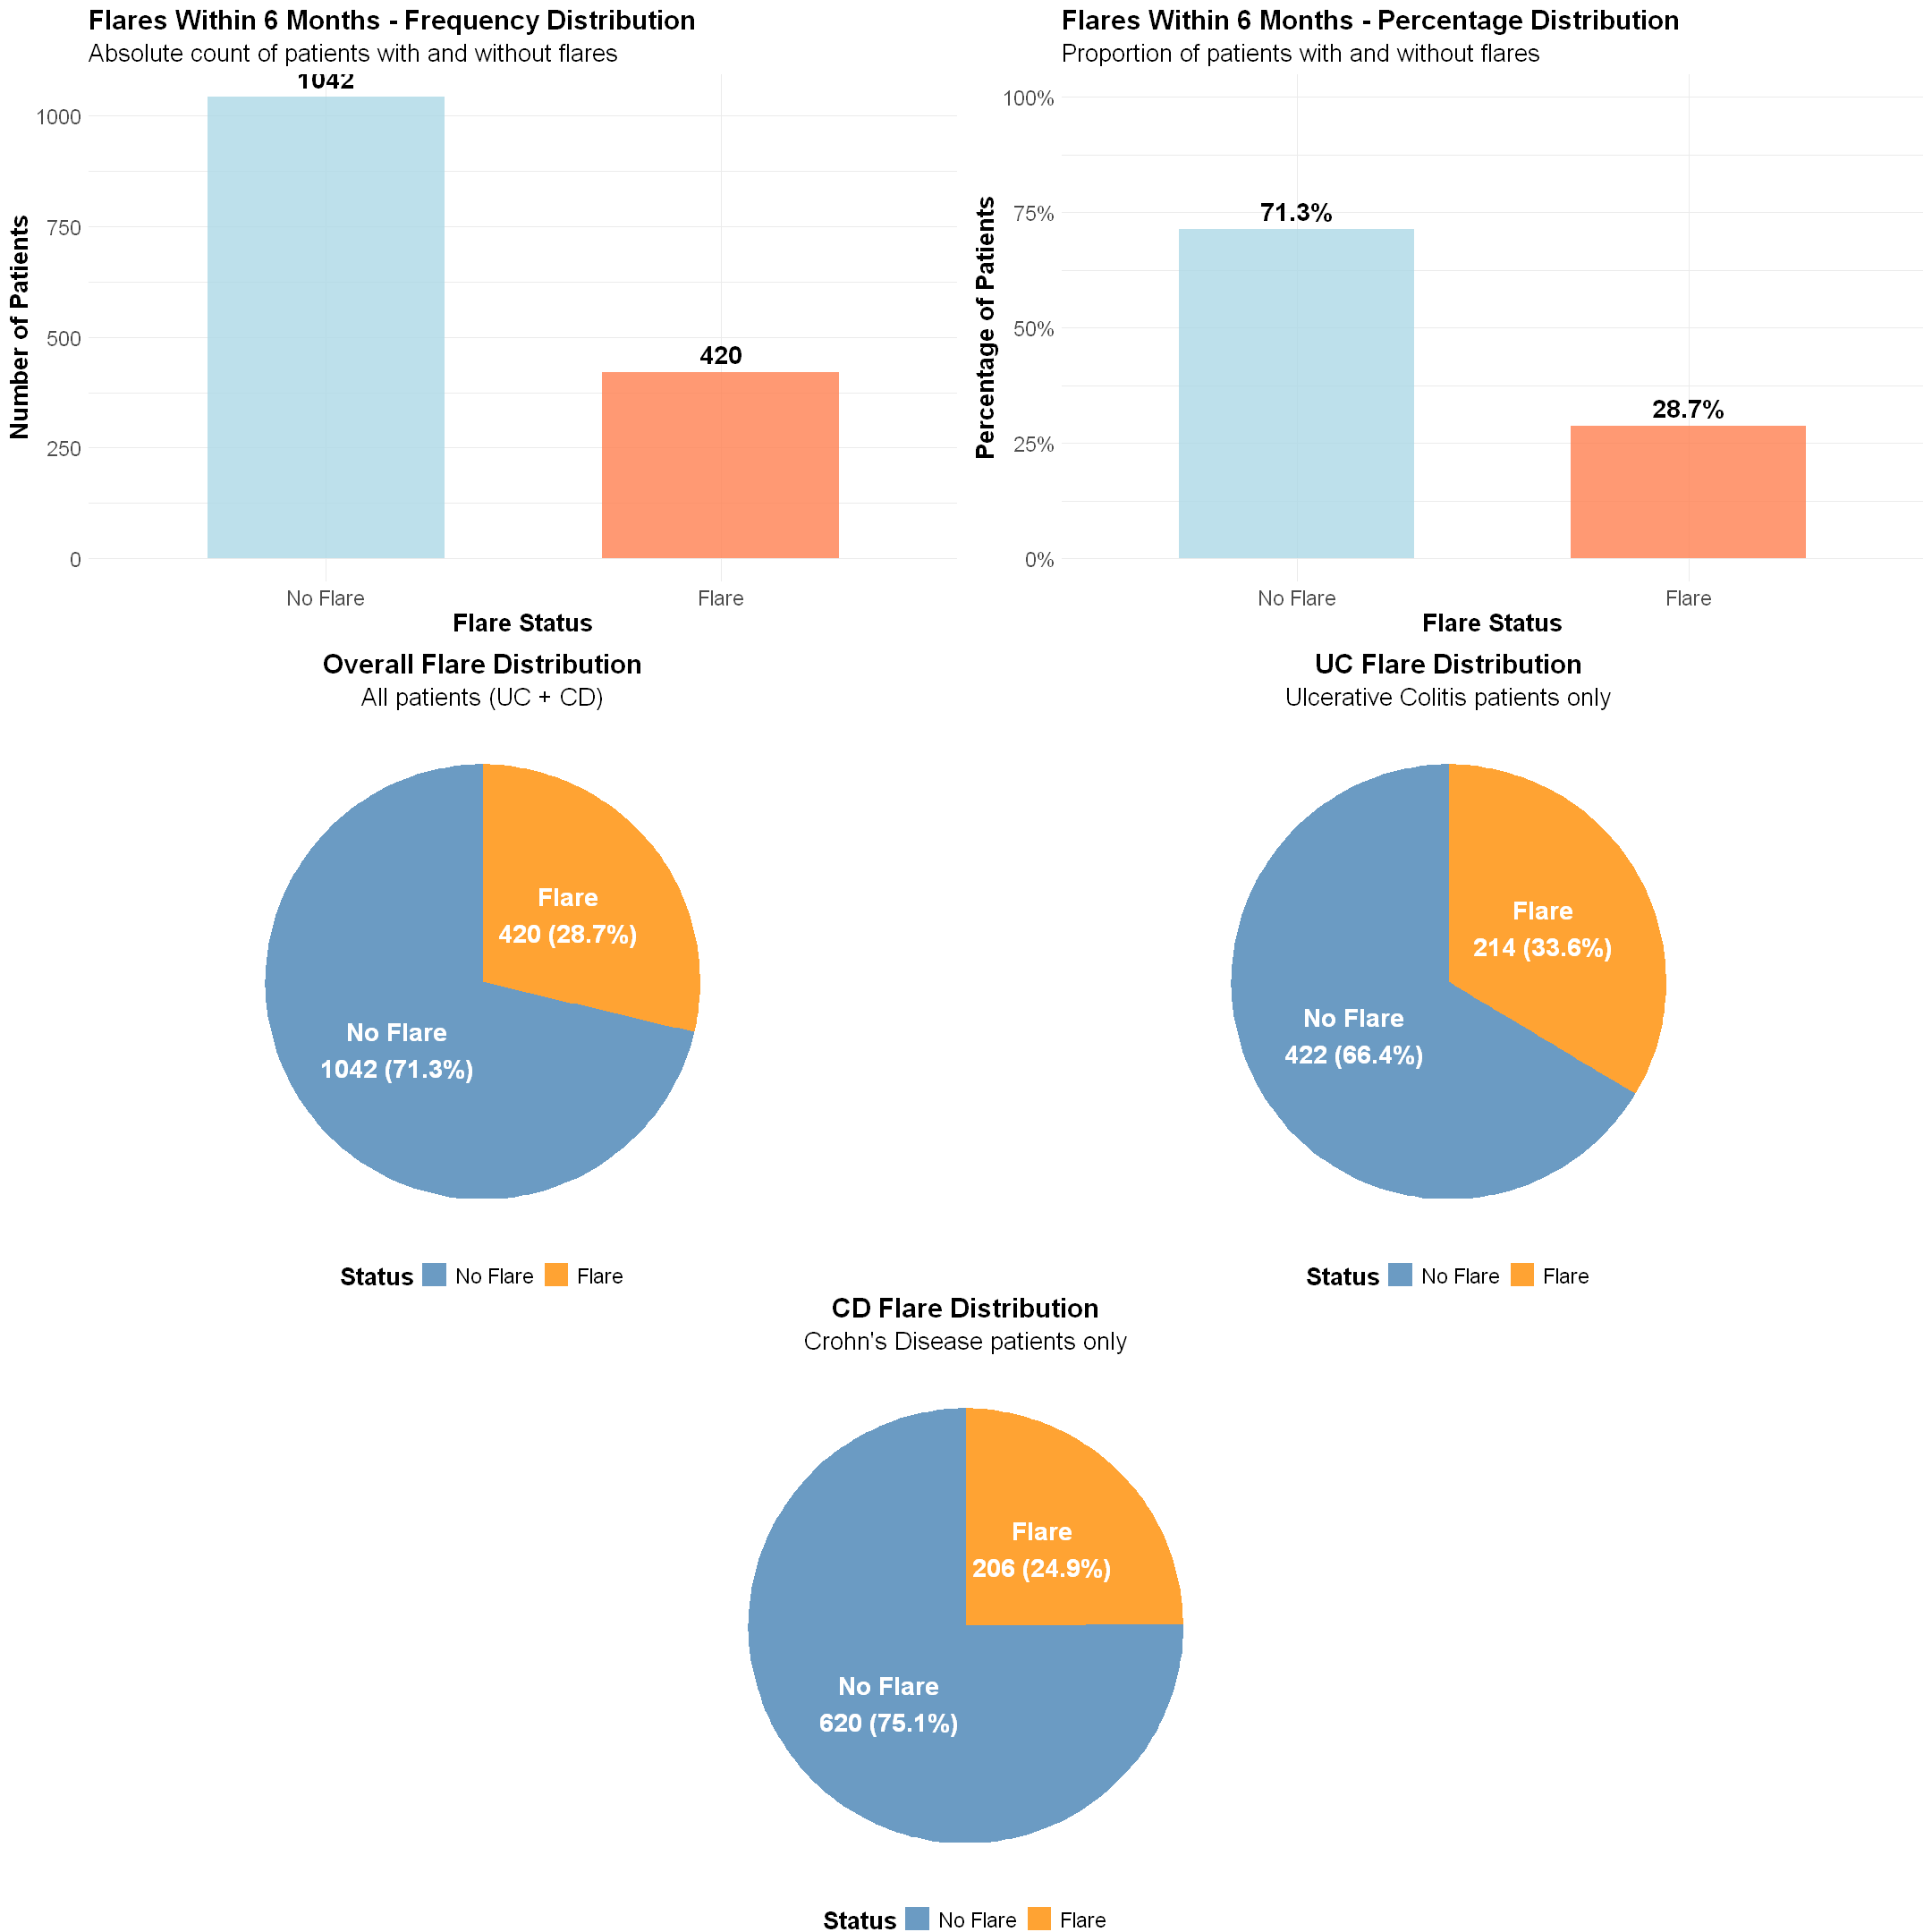

In [39]:
# ===============================================================================
# 1. DEPENDENT VARIABLES ANALYSIS
# ===============================================================================

# Define dependent variable
dependent_vars <- c("flare_majority_within_6m")

# Summary of flare variable
flare_summary <- modeling_data %>%
  dplyr::select(all_of(dependent_vars)) %>%
  dplyr::summarise(
    total = n(),
    count_flares = sum(flare_majority_within_6m  == 1, na.rm = TRUE),
    count_no_flares = sum(flare_majority_within_6m  == 0, na.rm = TRUE),
    prop_flares = mean(flare_majority_within_6m  == 1, na.rm = TRUE),
    missing = sum(is.na(flare_majority_within_6m ))
  )

print("Summary statistics:")
print(flare_summary)

# Prepare binary flare data (Overall)
flare_binary_data <- modeling_data %>%
  dplyr::select(flare_majority_within_6m) %>%
  filter(!is.na(flare_majority_within_6m)) %>%
  mutate(
    flare_status = factor(
      ifelse(flare_majority_within_6m  == 1, "Flare", "No Flare"),
      levels = c("No Flare", "Flare")
    )
  ) %>%
  group_by(flare_status) %>%
  summarise(count = n(), .groups = "drop") %>%
  mutate(
    total = sum(count),
    percentage = round(count / total * 100, 1)
  )

# Prepare binary flare data by Disease (UC and CD separately)
flare_by_disease <- modeling_data %>%
  dplyr::select(flare_majority_within_6m , DiseaseEntity) %>%
  filter(!is.na(flare_majority_within_6m )) %>%
  mutate(
    flare_status = factor(
      ifelse(flare_majority_within_6m  == 1, "Flare", "No Flare"),
      levels = c("No Flare", "Flare")
    )
  ) %>%
  group_by(DiseaseEntity, flare_status) %>%
  summarise(count = n(), .groups = "drop") %>%
  group_by(DiseaseEntity) %>%
  mutate(
    total = sum(count),
    percentage = round(count / total * 100, 1)
  )

# Split by disease
flare_uc <- flare_by_disease %>% filter(DiseaseEntity == "UC")
flare_cd <- flare_by_disease %>% filter(DiseaseEntity == "CD")

# === Plot 1: Frequency Bar Plot (Overall) ===
options(repr.plot.width=18, repr.plot.height=18)
flare_plot_counts <- ggplot(flare_binary_data, 
                            aes(x = flare_status, y = count, fill = flare_status)) +
  geom_bar(stat = "identity", alpha = 0.8, width = 0.6) +
  geom_text(aes(label = count), 
            vjust = -0.5, size = 6, fontface = "bold") +
  scale_fill_manual(values = c("No Flare" = "lightblue", "Flare" = "coral")) +
  labs(title = "Flares Within 6 Months - Frequency Distribution",
       subtitle = "Absolute count of patients with and without flares",
       x = "Flare Status", 
       y = "Number of Patients",
       fill = "Status") +
  theme_minimal() +
  theme(
    plot.title = element_text(size = 18, face = "bold"),
    plot.subtitle = element_text(size = 16),
    axis.title.x = element_text(size = 16, face = "bold"),
    axis.title.y = element_text(size = 16, face = "bold"),
    axis.text.x = element_text(size = 14),
    axis.text.y = element_text(size = 14),
    legend.position = "none"
  )

# === Plot 2: Percentage Bar Plot (Overall) ===
flare_plot_pct <- ggplot(flare_binary_data, 
                         aes(x = flare_status, y = percentage, fill = flare_status)) +
  geom_bar(stat = "identity", alpha = 0.8, width = 0.6) +
  geom_text(aes(label = paste0(percentage, "%")), 
            vjust = -0.5, size = 6, fontface = "bold") +
  scale_fill_manual(values = c("No Flare" = "lightblue", "Flare" = "coral")) +
  scale_y_continuous(labels = function(x) paste0(x, "%"), limits = c(0, 100)) +
  labs(title = "Flares Within 6 Months - Percentage Distribution",
       subtitle = "Proportion of patients with and without flares",
       x = "Flare Status", 
       y = "Percentage of Patients",
       fill = "Status") +
  theme_minimal() +
  theme(
    plot.title = element_text(size = 18, face = "bold"),
    plot.subtitle = element_text(size = 16),
    axis.title.x = element_text(size = 16, face = "bold"),
    axis.title.y = element_text(size = 16, face = "bold"),
    axis.text.x = element_text(size = 14),
    axis.text.y = element_text(size = 14),
    legend.position = "none"
  )

# === Plot 3: Pie Chart (Overall) ===
flare_pie_chart <- ggplot(flare_binary_data, 
                          aes(x = "", y = percentage, fill = flare_status)) +
  geom_bar(stat = "identity", width = 1, alpha = 0.8) +
  coord_polar("y", start = 0) +
  geom_text(aes(label = paste0(flare_status, "\n", count, " (", percentage, "%)")), 
            position = position_stack(vjust = 0.5),
            size = 6, fontface = "bold", color = "white") +
  scale_fill_manual(values = c("No Flare" = "steelblue", "Flare" = "darkorange")) +
  labs(title = "Overall Flare Distribution",
       subtitle = "All patients (UC + CD)",
       fill = "Status") +
  theme_void() +
  theme(
    plot.title = element_text(size = 18, face = "bold", hjust = 0.5),
    plot.subtitle = element_text(size = 16, hjust = 0.5),
    legend.title = element_text(size = 16, face = "bold"),
    legend.text = element_text(size = 14),
    legend.position = "bottom"
  )

# === Plot 4: Pie Chart for UC ===
flare_pie_uc <- ggplot(flare_uc, 
                       aes(x = "", y = percentage, fill = flare_status)) +
  geom_bar(stat = "identity", width = 1, alpha = 0.8) +
  coord_polar("y", start = 0) +
  geom_text(aes(label = paste0(flare_status, "\n", count, " (", percentage, "%)")), 
            position = position_stack(vjust = 0.5),
            size = 6, fontface = "bold", color = "white") +
  scale_fill_manual(values = c("No Flare" = "steelblue", "Flare" = "darkorange")) +
  labs(title = "UC Flare Distribution",
       subtitle = "Ulcerative Colitis patients only",
       fill = "Status") +
  theme_void() +
  theme(
    plot.title = element_text(size = 18, face = "bold", hjust = 0.5),
    plot.subtitle = element_text(size = 16, hjust = 0.5),
    legend.title = element_text(size = 16, face = "bold"),
    legend.text = element_text(size = 14),
    legend.position = "bottom"
  )

# === Plot 5: Pie Chart for CD ===
flare_pie_cd <- ggplot(flare_cd, 
                       aes(x = "", y = percentage, fill = flare_status)) +
  geom_bar(stat = "identity", width = 1, alpha = 0.8) +
  coord_polar("y", start = 0) +
  geom_text(aes(label = paste0(flare_status, "\n", count, " (", percentage, "%)")), 
            position = position_stack(vjust = 0.5),
            size = 6, fontface = "bold", color = "white") +
  scale_fill_manual(values = c("No Flare" = "steelblue", "Flare" = "darkorange")) +
  labs(title = "CD Flare Distribution",
       subtitle = "Crohn's Disease patients only",
       fill = "Status") +
  theme_void() +
  theme(
    plot.title = element_text(size = 18, face = "bold", hjust = 0.5),
    plot.subtitle = element_text(size = 16, hjust = 0.5),
    legend.title = element_text(size = 16, face = "bold"),
    legend.text = element_text(size = 14),
    legend.position = "bottom"
  )

# === Display All Plots ===
grid.arrange(
  flare_plot_counts, flare_plot_pct, 
  flare_pie_chart, flare_pie_uc, flare_pie_cd,
  ncol = 2,
  layout_matrix = rbind(c(1, 2), c(3, 4), c(5, 5))
)

# === Summary Tables ===
print("\n=== Overall Flare Summary ===")
print(flare_binary_data)

print("\n=== Flare Summary by Disease ===")
print(flare_by_disease)

## III.2 Summary Tables 

The bivariate analysis compares categorical and numerical predictors across flare/no-flare groups (n=1,042 vs 420) in psychosocial assessments, revealing **significant disease heterogeneity** (χ²=12.8, p=0.001: UC 49.9% flares vs CD 50.1%) alongside key surgical risk factors in CD (ileocaecal resection χ²=9.3 p=0.006, small bowel resection χ²=9.0 p=0.004, stoma χ²=7.6 p=0.014) and UC Montreal severity/extent (both p<0.001), while smoker status (χ²=10.9 p=0.011) shows dose-response. Numerical variables highlight **paradoxical psychosocial patterns**—flares associate with **lower** max pain/fatigue/anxiety (pain -13.6 t-stat, fatigue -12.9, all p<0.001) but **higher** stress (9.65 t-stat p<0.001) and fewer surgeries (0.38 vs 0.23, p<0.001)—suggesting flares may reflect acute biomarker-driven events rather than chronic symptom burden, with disease_burden_score modestly lower in flares (0.71 vs 0.68, p=0.014), prioritizing these variables for GLASSO regression.

In [40]:
library(tidyverse)

# ===============================================================================
# PART 1: CATEGORICAL TABLE (UNWEIGHTED)
# ===============================================================================

cat_table <- function(df, label = "Overall") {
  
  cat_vars_local <- df |>
    select(-any_of(c("flare_majority_within_6m", "patient_weight", "patientIdentifier"))) |>
    select(where(~ is.factor(.) | is.character(.))) |>
    names()
  
  map_dfr(cat_vars_local, function(var) {
    
    df_sub <- df |>
      drop_na(all_of(var), flare_majority_within_6m)
    
    if (nrow(df_sub) < 3) return(NULL)
    
    # Counts
    tab <- table(df_sub[[var]], df_sub$flare_majority_within_6m)
    
    # Percentages
    prop <- prop.table(tab, margin = 2) * 100
    
    cats <- rownames(tab)
    
    cells <- map_dfr(cats, function(cat) {
      tibble(
        Category = cat,
        No_Flare = paste0(tab[cat, "0"], " (", round(prop[cat, "0"], 1), "%)"),
        Flare    = paste0(tab[cat, "1"], " (", round(prop[cat, "1"], 1), "%)")
      )
    })
    
    # Chi-square test
    chisq <- tryCatch({
      test <- chisq.test(tab)
      tibble(
        ChiSq   = as.character(round(test$statistic, 3)),
        P_Value = ifelse(test$p.value < 0.001, "<0.001", as.character(round(test$p.value, 3)))
      )
    }, error = function(e) tibble(ChiSq = NA_character_, P_Value = NA_character_))
    
    cells |>
      mutate(
        Variable = c(var, rep("", nrow(cells) - 1)),
        ChiSq    = c(chisq$ChiSq, rep("", nrow(cells) - 1)),
        P_Value  = c(chisq$P_Value, rep("", nrow(cells) - 1)),
        Stratum  = label
      ) |>
      select(Variable, Category, No_Flare, Flare, ChiSq, P_Value, Stratum)
  })
}

# ===============================================================================
# PART 2: NUMERICAL TABLE (UNWEIGHTED)
# ===============================================================================

num_table <- function(df, label = "Overall") {
  
  num_vars_local <- df |>
    select(-any_of(c("flare_majority_within_6m", "patient_weight", "patientIdentifier"))) |>
    select(where(is.numeric)) |>
    names()
  
  map_dfr(num_vars_local, function(var) {
    
    df_sub <- df |>
      drop_na(all_of(var), flare_majority_within_6m)
    
    if (n_distinct(df_sub$flare_majority_within_6m) < 2 || nrow(df_sub) < 3) return(NULL)
    
    # Means & SD
    fmt_group <- function(group_val) {
      vals <- df_sub[[var]][df_sub$flare_majority_within_6m == group_val]
      paste0(round(mean(vals), 2), " (", round(sd(vals), 2), ")")
    }
    
    no_flare_str <- fmt_group(0)
    flare_str    <- fmt_group(1)
    
    # t-test
    ttest <- tryCatch({
      test <- t.test(df_sub[[var]] ~ df_sub$flare_majority_within_6m)
      tibble(
        t_Stat  = as.character(round(test$statistic, 3)),
        P_Value = ifelse(test$p.value < 0.001, "<0.001", as.character(round(test$p.value, 3)))
      )
    }, error = function(e) tibble(t_Stat = NA_character_, P_Value = NA_character_))
    
    tibble(
      Variable = var,
      No_Flare = no_flare_str,
      Flare    = flare_str,
      t_Stat   = ttest$t_Stat,
      P_Value  = ttest$P_Value,
      Stratum  = label
    )
  })
}

# ===============================================================================
# PART 3: BUILD TABLES
# ===============================================================================

cat_psychosocial <- cat_table(modeling_data)
num_psychosocial <- num_table(modeling_data)

# ===============================================================================
# PART 4: PRINT (UNCHANGED)
# ===============================================================================



Warning message in chisq.test(tab):
"Chi-squared approximation may be incorrect"
Warning message in chisq.test(tab):
"Chi-squared approximation may be incorrect"
Warning message in chisq.test(tab):
"Chi-squared approximation may be incorrect"


In [41]:
# ===============================================================================
# PRINT FUNCTIONS (REQUIRED)
# ===============================================================================

# Column widths
W  <- list(var = 28, cat = 24, no_flare = 17, flare = 15, stat = 15, pval = 10)

SEP <- paste0(strrep("=", 71), "\n")

DIV <- paste0(
  strrep("-", W$var), "  ",
  strrep("-", W$cat), "  ",
  strrep("-", W$no_flare), "  ",
  strrep("-", W$flare), "  ",
  strrep("-", W$stat), "  ",
  strrep("-", W$pval), "\n"
)

pad <- function(x, width, justify = "left") {
  formatC(as.character(x), width = width, flag = if (justify == "left") "-" else "")
}

print_cat_table <- function(tbl, title) {
  cat(SEP)
  cat(title, "\n")
  cat(SEP, "\n")
  
  cat(
    pad("Variable",     W$var),      "  ",
    pad("Category",     W$cat),      "  ",
    pad("No Flare n (%)", W$no_flare), "  ",
    pad("Flare n (%)",  W$flare),    "  ",
    pad("χ² Statistic", W$stat),     "  ",
    pad("P-Value",      W$pval),     "\n", sep = ""
  )
  cat(DIV)
  
  tbl |>
    select(-Stratum) |>
    pwalk(function(Variable, Category, No_Flare, Flare, ChiSq, P_Value) {
      cat(
        pad(Variable,  W$var),      "  ",
        pad(Category,  W$cat),      "  ",
        pad(No_Flare,  W$no_flare), "  ",
        pad(Flare,     W$flare),    "  ",
        pad(ChiSq,     W$stat),     "  ",
        pad(P_Value,   W$pval),     "\n", sep = ""
      )
    })
  cat("\n")
}

print_num_table <- function(tbl, title) {
  cat(SEP)
  cat(title, "\n")
  cat(SEP, "\n")
  
  cat(
    pad("Variable",            W$var),      "  ",
    pad("No Flare Mean (SD)",  W$no_flare + W$cat + 2), "  ",
    pad("Flare Mean (SD)",     W$flare),    "  ",
    pad("t Statistic",         W$stat),     "  ",
    pad("P-Value",             W$pval),     "\n", sep = ""
  )
  
  cat(paste0(
    strrep("-", W$var), "  ",
    strrep("-", W$no_flare + W$cat + 2), "  ",
    strrep("-", W$flare), "  ",
    strrep("-", W$stat),  "  ",
    strrep("-", W$pval),  "\n"
  ))
  
  tbl |>
    select(-Stratum) |>
    pwalk(function(Variable, No_Flare, Flare, t_Stat, P_Value) {
      cat(
        pad(Variable,  W$var),               "  ",
        pad(No_Flare,  W$no_flare + W$cat + 2), "  ",
        pad(Flare,     W$flare),              "  ",
        pad(t_Stat,    W$stat),               "  ",
        pad(P_Value,   W$pval),               "\n", sep = ""
      )
    })
  cat("\n")
}

In [42]:
print_cat_table(cat_psychosocial, "CATEGORICAL VARIABLES - flares within 6m | Psychosocial assessment")
print_num_table(num_psychosocial, "NUMERICAL VARIABLES   - flares within 6m | Psychosocial assessment")

CATEGORICAL VARIABLES - flares within 6m | Psychosocial assessment 
 
Variable                      Category                  No Flare n (%)     Flare n (%)      χ² Statistic     P-Value   
----------------------------  ------------------------  -----------------  ---------------  ---------------  ----------
DiseaseEntity                 CD                        620 (59.5%)        206 (49%)        12.887           <0.001    
                              UC                        422 (40.5%)        214 (51%)                                   
gender                        Male                      473 (45.4%)        200 (47.6%)      0.511            0.475     
                              Female                    569 (54.6%)        220 (52.4%)                                 
montreal_extent_uc            1                         59 (5.7%)          35 (8.3%)        19.054           <0.001    
                              2                         223 (21.4%)        98 (23.3%)     

In [43]:
# ===============================================================================
# EXPORT ALL TABLES TO EXCEL
# ===============================================================================

library(openxlsx)

wb <- createWorkbook()

# Helper: add a sheet with a title row, then the data
add_sheet <- function(wb, sheet_name, tbl, title) {
  addWorksheet(wb, sheet_name)
  
  # Title row
  writeData(wb, sheet_name, data.frame(x = title), startRow = 1, colNames = FALSE)
  
  # Table data (drop Stratum column)
  writeData(wb, sheet_name, tbl |> select(-Stratum), startRow = 3, colNames = TRUE)
  
  # Style: title bold
  addStyle(wb, sheet_name,
           style = createStyle(fontSize = 12, textDecoration = "bold"),
           rows = 1, cols = 1)
  
  # Style: header row
  addStyle(wb, sheet_name,
           style = createStyle(
             fontSize      = 11,
             textDecoration = "bold",
             fgFill         = "#2C3E50",
             fontColour     = "#FFFFFF",
             halign         = "left",
             border         = "TopBottomLeftRight"
           ),
           rows = 3, cols = 1:ncol(tbl |> select(-Stratum)), gridExpand = TRUE)
  
  # Style: data rows (alternating)
  n_rows <- nrow(tbl)
  even_rows <- seq(4, 4 + n_rows, by = 2)
  odd_rows  <- seq(5, 4 + n_rows, by = 2)
  n_cols    <- ncol(tbl |> select(-Stratum))
  
  addStyle(wb, sheet_name,
           style = createStyle(fgFill = "#F2F2F2", border = "TopBottomLeftRight"),
           rows = even_rows, cols = 1:n_cols, gridExpand = TRUE)
  
  addStyle(wb, sheet_name,
           style = createStyle(fgFill = "#FFFFFF", border = "TopBottomLeftRight"),
           rows = odd_rows,  cols = 1:n_cols, gridExpand = TRUE)
  
  # Auto column widths
  setColWidths(wb, sheet_name, cols = 1:n_cols, widths = "auto")
}


# -----------------------------------------------------------------------
# Clinical assessment (baseline + baseline+psychosocial)
# -----------------------------------------------------------------------
add_sheet(wb, "Cat_Clinical",
          cat_psychosocial,
          "Categorical variables by flare status — Clinical assessment (weighted)")

add_sheet(wb, "Num_Clinical",
          num_psychosocial,
          "Numerical variables by flare status — Clinical assessment (weighted)")


# -----------------------------------------------------------------------
# Save
# -----------------------------------------------------------------------
saveWorkbook(wb, "Flare_Summary_Tables.xlsx", overwrite = TRUE)
cat("\n✓ Excel workbook saved: Flare_Summary_Tables.xlsx\n")

Warning message:
"package 'openxlsx' was built under R version 4.5.2"



✓ Excel workbook saved: Flare_Summary_Tables.xlsx


## IV. Categorization Strategy

The `categorize_and_test_predictor()` function systematically evaluates optimal cutpoints for continuous predictors against `flare_majority_within_6m` using four schemes—tertiles (3 groups), quartiles (4 groups), median split (2 groups), top 25% (2 groups)—via chi-square/Fisher tests to identify the best categorization by lowest p-value, with `add_best_categorizations()` applying the winner. It generates descriptive labels from actual quantiles (e.g., "18-25, 25-32"), validates sufficient categories/data (≥2 categories, ≥10 obs), handles sparse cells with simulation, and outputs detailed crosstabs showing frequency/proportion tables for the best scheme per predictor. This data-adaptive approach maximizes statistical power for each numerical covariate (age, BMI, psychosocial scores, surgeries) in the 1,462-patient dataset, enabling robust categorical modeling while preserving interpretability for clinical variables like `disease_burden_score`, `number_of_surgeries`, and `anxious_or_depressed` in final GLASSO MODELS.


In [44]:
# Main function to categorize and test a numerical predictor 
categorize_and_test_predictor <- function(data, predictor_name, outcomes) {
  
  cat("\n", strrep("=", 80), "\n")
  cat("PROCESSING:", predictor_name, "\n")
  cat(strrep("=", 80), "\n\n")
  
  predictor <- data[[predictor_name]]
  
  n_unique <- length(unique(na.omit(predictor)))
  n_valid <- sum(!is.na(predictor))
  cat("Number of unique values:", n_unique, "\n")
  cat("Number of valid observations:", n_valid, "\n")
  
  if(n_unique < 2 || n_valid < 10) {
    cat("\nWARNING: Insufficient data for categorization\n")
    return(NULL)
  }
  
  cat("\nOverall summary statistics:\n")
  print(summary(predictor))
  
  # ==============================================================================
  # Safe cut function with real value labels
  # ==============================================================================
  
  safe_cut <- function(x, breaks, include.lowest = TRUE, right = TRUE) {
    breaks_unique <- unique(breaks)
    if(length(breaks_unique) <= 2) return(rep(NA, length(x)))
    
    # Build labels from actual break values
    labels <- sapply(1:(length(breaks_unique) - 1), function(i) {
      lo <- breaks_unique[i]
      hi <- breaks_unique[i + 1]
      lo_str <- if (is.infinite(lo)) "" else format(round(lo, 2), nsmall = 0)
      hi_str <- if (is.infinite(hi)) "" else format(round(hi, 2), nsmall = 0)
      if (is.infinite(lo))      paste0("≤", hi_str)
      else if (is.infinite(hi)) paste0(">", lo_str)
      else                      paste0(lo_str, "-", hi_str)
    })
    
    cut(x, breaks = breaks_unique, labels = labels,
        include.lowest = include.lowest, right = right)
  }
  
  # ==============================================================================
  # Create temporary data with all categorizations
  # ==============================================================================
  
  q33  <- quantile(predictor, probs = c(0, 1/3, 2/3, 1), na.rm = TRUE)
  q44  <- quantile(predictor, probs = c(0, 0.25, 0.5, 0.75, 1), na.rm = TRUE)
  med  <- median(predictor, na.rm = TRUE)
  p75  <- quantile(predictor, 0.75, na.rm = TRUE)
  
  temp_data <- data %>%
    mutate(
      predictor  = !!sym(predictor_name),
      cat_q3     = safe_cut(predictor, breaks = q33),
      cat_q4     = safe_cut(predictor, breaks = q44),
      cat_median = safe_cut(predictor, breaks = c(-Inf, med, Inf)),
      cat_top25  = safe_cut(predictor, breaks = c(-Inf, p75,  Inf))
    )
  
  # ==============================================================================
  # Identify valid categorizations
  # ==============================================================================
  
  cat_vars   <- grep("^cat_", names(temp_data), value = TRUE)
  valid_cats <- c()
  
  cat("\n=== CATEGORIZATION DISTRIBUTIONS ===\n")
  for(cat_var in cat_vars) {
    tbl          <- table(temp_data[[cat_var]], useNA = "ifany")
    n_categories <- length(unique(na.omit(temp_data[[cat_var]])))
    n_obs        <- sum(!is.na(temp_data[[cat_var]]))
    
    if(n_categories >= 2 && n_obs >= 10) {
      cat("\n", cat_var, ":\n")
      print(tbl)
      valid_cats <- c(valid_cats, cat_var)
    } else {
      cat("\n", cat_var, ": SKIPPED (insufficient categories or data)\n")
    }
  }
  
  if(length(valid_cats) == 0) {
    cat("\nERROR: No valid categorizations created\n")
    return(NULL)
  }
  
  # ==============================================================================
  # Chi-square testing
  # ==============================================================================
  
  compute_chisq <- function(data, cat_var, outcome) {
    test_data <- data %>% filter(!is.na(.data[[cat_var]]), !is.na(.data[[outcome]]))
    if(nrow(test_data) < 10) return(NULL)
    
    tbl <- table(test_data[[cat_var]], test_data[[outcome]])
    if(any(rowSums(tbl) == 0)) tbl <- tbl[rowSums(tbl) > 0, , drop = FALSE]
    if(any(colSums(tbl) == 0)) tbl <- tbl[, colSums(tbl) > 0, drop = FALSE]
    
    if(min(dim(tbl)) > 0 && all(rowSums(tbl) > 0) && all(colSums(tbl) > 0)) {
      test <- tryCatch({
        chisq.test(tbl)
      }, warning = function(w) {
        if(prod(dim(tbl)) <= 4 && all(tbl < 1000)) {
          fisher.test(tbl, simulate.p.value = TRUE, B = 10000)
        } else {
          chisq.test(tbl)
        }
      }, error = function(e) {
        cat("Error in chi-square test for", cat_var, "vs", outcome, ":", e$message, "\n")
        return(NULL)
      })
      
      if(!is.null(test)) {
        return(data.frame(
          predictor      = predictor_name,
          categorization = cat_var,
          outcome        = outcome,
          chi_sq         = ifelse("statistic" %in% names(test), round(test$statistic, 3), NA),
          df             = ifelse("parameter" %in% names(test), test$parameter, NA),
          p_value        = test$p.value,
          p_formatted    = ifelse(test$p.value < 0.001, "< 0.001", sprintf("%.4f", test$p.value)),
          n              = nrow(test_data)
        ))
      }
    }
    return(NULL)
  }
  
  results <- expand.grid(cat_var = valid_cats, outcome = outcomes, stringsAsFactors = FALSE) %>%
    rowwise() %>%
    do({ compute_chisq(temp_data, .$cat_var, .$outcome) }) %>%
    ungroup() %>%
    filter(!is.na(p_value)) %>%
    arrange(outcome, p_value)
  
  cat("\n=== CHI-SQUARE TEST RESULTS ===\n")
  print(results)
  
  best_by_outcome <- results %>%
    group_by(outcome) %>%
    slice_min(p_value, n = 1) %>%
    ungroup()
  
  cat("\n=== BEST CATEGORIZATION FOR EACH OUTCOME ===\n")
  print(best_by_outcome)
  
  cat("\n=== DETAILED CROSSTABS FOR BEST CATEGORIZATIONS ===\n")
  crosstabs_list <- list()
  
  for(i in 1:nrow(best_by_outcome)) {
    outcome  <- best_by_outcome$outcome[i]
    cat_var  <- best_by_outcome$categorization[i]
    
    cat("\n", strrep("-", 80), "\n")
    cat("OUTCOME:", outcome, "| CATEGORIZATION:", cat_var, "\n")
    cat("p-value:", best_by_outcome$p_formatted[i], "| N:", best_by_outcome$n[i], "\n")
    cat(strrep("-", 80), "\n\n")
    
    tbl       <- table(temp_data[[cat_var]], temp_data[[outcome]], useNA = "ifany")
    row_props <- round(prop.table(tbl, margin = 1) * 100, 1)
    
    cat("Frequency table:\n");      print(tbl)
    cat("\nRow proportions (% within each category):\n"); print(row_props)
    
    crosstabs_list[[outcome]] <- list(table = tbl, row_proportions = row_props)
  }
  
  return(list(
    predictor_name  = predictor_name,
    summary_stats   = summary(predictor),
    n_unique        = n_unique,
    n_valid         = n_valid,
    all_results     = results,
    best_by_outcome = best_by_outcome,
    crosstabs       = crosstabs_list,
    # Store break points for use in add_best_categorizations
    breaks          = list(q3 = q33, q4 = q44, median = med, top25 = p75)
  ))
}


add_best_categorizations <- function(data, predictor_name, best_cat, breaks = NULL) {
  
  if(is.null(best_cat)) {
    message("No categorization results provided")
    return(data)
  }
  
  predictor <- data[[predictor_name]]
  n_unique  <- length(unique(na.omit(predictor)))
  
  if(n_unique < 2) {
    warning("Predictor '", predictor_name, "' has fewer than 2 unique values. Cannot categorize.")
    return(data)
  }
  
  # Use stored breaks if provided, else recompute
  q33 <- if(!is.null(breaks$q3))     breaks$q3     else quantile(predictor, probs = c(0, 1/3, 2/3, 1), na.rm = TRUE)
  q44 <- if(!is.null(breaks$q4))     breaks$q4     else quantile(predictor, probs = c(0, 0.25, 0.5, 0.75, 1), na.rm = TRUE)
  med <- if(!is.null(breaks$median)) breaks$median else median(predictor, na.rm = TRUE)
  p75 <- if(!is.null(breaks$top25))  breaks$top25  else quantile(predictor, 0.75, na.rm = TRUE)
  
  safe_cut <- function(x, breaks, include.lowest = TRUE, right = TRUE) {
    breaks_unique <- unique(breaks)
    if(length(breaks_unique) <= 2) return(rep(NA, length(x)))
    
    labels <- sapply(1:(length(breaks_unique) - 1), function(i) {
      lo <- breaks_unique[i]
      hi <- breaks_unique[i + 1]
      lo_str <- if (is.infinite(lo)) "" else format(round(lo, 2), nsmall = 0)
      hi_str <- if (is.infinite(hi)) "" else format(round(hi, 2), nsmall = 0)
      if (is.infinite(lo))      paste0("≤", hi_str)
      else if (is.infinite(hi)) paste0(">", lo_str)
      else                      paste0(lo_str, "-", hi_str)
    })
    
    cut(x, breaks = breaks_unique, labels = labels,
        include.lowest = include.lowest, right = right)
  }
  
  data[[predictor_name]] <- switch(best_cat,
    cat_q3     = safe_cut(predictor, breaks = q33),
    cat_q4     = safe_cut(predictor, breaks = q44),
    cat_median = safe_cut(predictor, breaks = c(-Inf, med, Inf)),
    cat_top25  = safe_cut(predictor, breaks = c(-Inf, p75,  Inf)),
    { message("Unknown categorization type: ", best_cat); predictor }
  )
  
  message("Applied ", best_cat, " to ", predictor_name,
          " — levels: ", paste(levels(data[[predictor_name]]), collapse = ", "))
  
  return(data)
}

flare_outcomes <- "flare_majority_within_6m"

#### disease_burden_score

The best quartiles create 4 balanced groups (Q1: 0.23-0.56 n=528; Q2: 0.56-0.70 n=263; Q3: 0.70-0.80 n=384; Q4: 0.80-1.42 n=287).


PROCESSING: disease_burden_score 

Number of unique values: 64 
Number of valid observations: 1462 

Overall summary statistics:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.1016  0.5036  0.7361  0.6896  0.7691  1.5124 

=== CATEGORIZATION DISTRIBUTIONS ===

 cat_q3 :

  0.1-0.5  0.5-0.74 0.74-1.51 
      549       527       386 

 cat_q4 :

  0.1-0.5  0.5-0.74 0.74-0.77 0.77-1.51 
      395       566       148       353 

 cat_median :

≤0.74 >0.74 
  961   501 

 cat_top25 :

≤0.77 >0.77 
 1109   353 

=== CHI-SQUARE TEST RESULTS ===
# A tibble: 4 × 8
  predictor       categorization outcome chi_sq    df  p_value p_formatted     n
  <chr>           <chr>          <chr>    <dbl> <int>    <dbl> <chr>       <int>
1 disease_burden… cat_median     flare_…   84.4     1 4.10e-20 < 0.001      1462
2 disease_burden… cat_q4         flare_…   88.1     3 5.54e-19 < 0.001      1462
3 disease_burden… cat_q3         flare_…   75.9     2 3.30e-17 < 0.001      1462
4 disease_burden… cat_top25

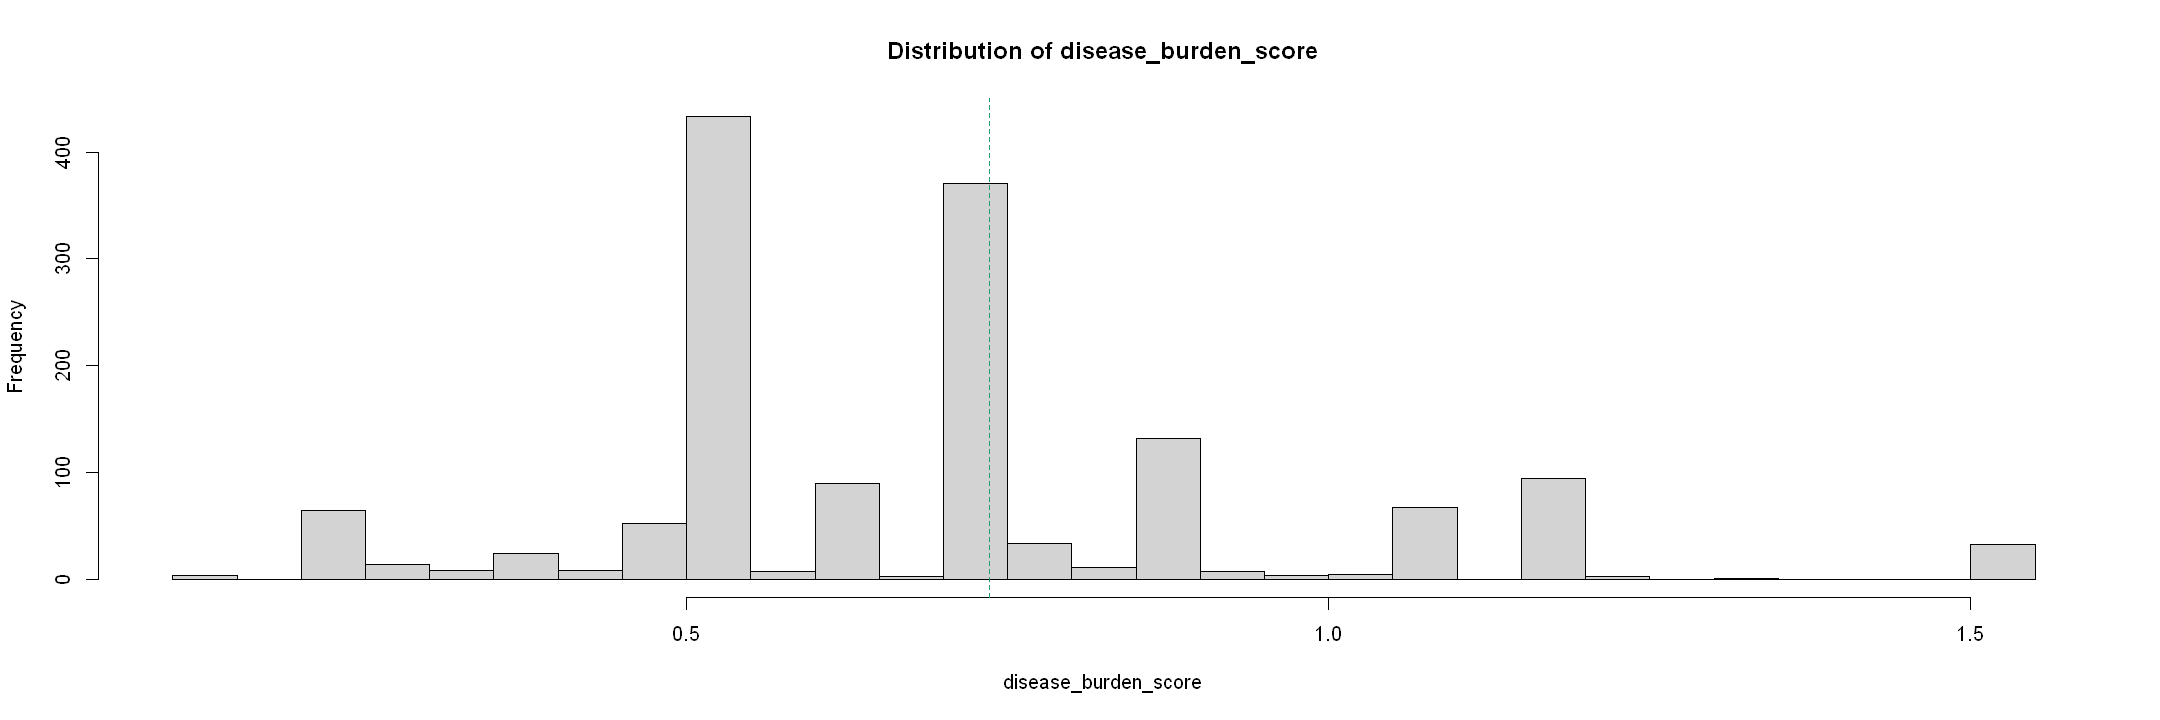

In [45]:
# Visualize distribution
options(repr.plot.width=18, repr.plot.height=6)
hist(modeling_data$disease_burden_score, breaks = 30, 
     main = "Distribution of disease_burden_score",
     xlab = "disease_burden_score")
abline(v = c(0, median(modeling_data$disease_burden_score, na.rm = TRUE)), 
       col = c( "#D95F02", "#1B9E77"), lty = 2)

results <- categorize_and_test_predictor(
  data = modeling_data,
  predictor_name = "disease_burden_score",
  outcomes = flare_outcomes
)

# Add best categorizations to the main dataset
#modeling_data <- add_best_categorizations(data= modeling_data, 
 #                                                    predictor_name= "disease_burden_score",  
  #                                                   best_cat= "cat_q4"  )


modeling_data$disease_burden_score <- scale(modeling_data$disease_burden_score)

#### age_at_inclusion

**median split** is an optimal split (χ²=5.08, df=1, p=0.0242) among four schemes, creating two equal groups (≤49.98 years n=731; >49.98 years n=731) in the 1,462-patient dataset. This categorization—applied via `add_best_categorizations("cat_median")`—replaces continuous age with a binary factor showing younger patients (≤50 years) have higher flare risk, outperforming tertiles/quartiles/top25%. 


PROCESSING: age_at_inclusion 

Number of unique values: 1410 
Number of valid observations: 1462 

Overall summary statistics:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  19.97   38.07   49.98   49.71   61.36   91.46 

=== CATEGORIZATION DISTRIBUTIONS ===

 cat_q3 :

19.97-41.81  41.81-57.8  57.8-91.46 
        488         487         487 

 cat_q4 :

19.97-38.07 38.07-49.98 49.98-61.36 61.36-91.46 
        366         365         365         366 

 cat_median :

≤49.98 >49.98 
   731    731 

 cat_top25 :

≤61.36 >61.36 
  1096    366 

=== CHI-SQUARE TEST RESULTS ===
# A tibble: 4 × 8
  predictor        categorization outcome chi_sq    df p_value p_formatted     n
  <chr>            <chr>          <chr>    <dbl> <int>   <dbl> <chr>       <int>
1 age_at_inclusion cat_median     flare_…  5.08      1  0.0242 0.0242       1462
2 age_at_inclusion cat_q4         flare_…  6.73      3  0.0809 0.0809       1462
3 age_at_inclusion cat_top25      flare_…  1.33      1  0.249  0.2488     

Applied cat_median to age_at_inclusion — levels: ≤49.98, >49.98



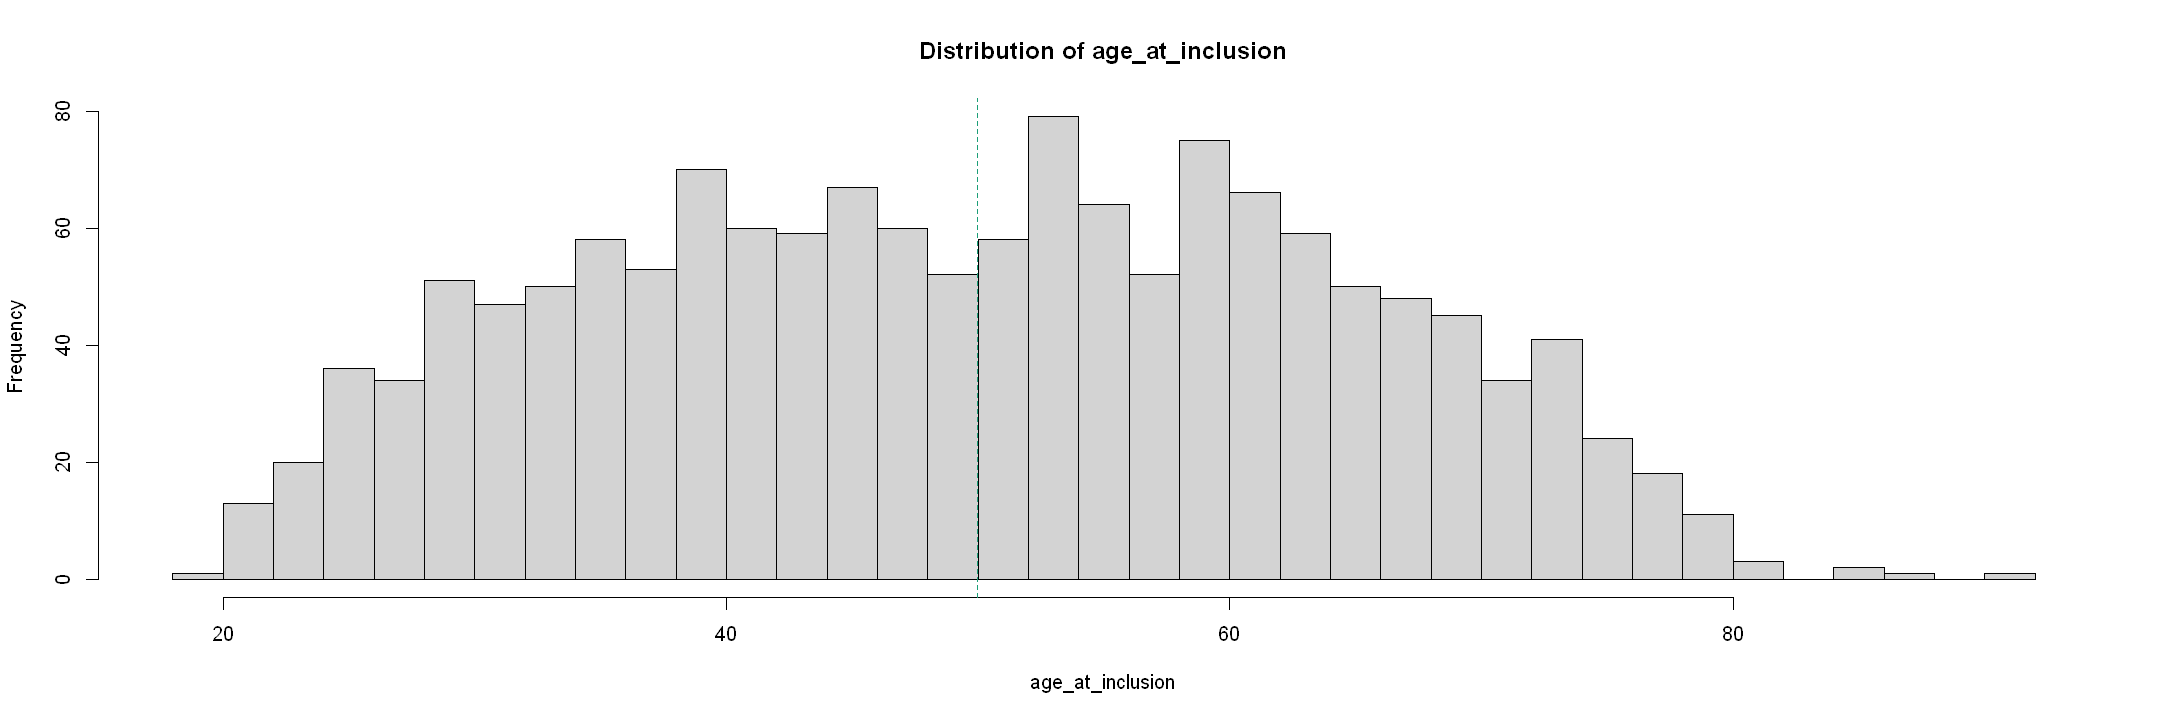

In [46]:
# Visualize distribution
options(repr.plot.width=18, repr.plot.height=6)
hist(modeling_data$age_at_inclusion, breaks = 30, 
     main = "Distribution of age_at_inclusion",
     xlab = "age_at_inclusion")
abline(v = c(0, median(modeling_data$age_at_inclusion, na.rm = TRUE)), 
       col = c( "#D95F02", "#1B9E77"), lty = 2)




results <- categorize_and_test_predictor(
  data = modeling_data,
  predictor_name = "age_at_inclusion",
  outcomes = flare_outcomes
)

# Add best categorizations to the main dataset
modeling_data <- add_best_categorizations(data= modeling_data, 
                                                     predictor_name= "age_at_inclusion",  
                                                     best_cat= "cat_median"  )


#### bmi

The code evaluates `bmi` for flare prediction, identifying **cat_median threshold** as optimal (χ²=4.09, df=1, p=0.0464) among four schemes, creating a binary split (≤24.86 n=731; >24.86 n=731) in the 1,462-patient dataset. Applied via `add_best_categorizations("cat_top25")`, this categorization reveals **obese patients** (BMI>24.9, top quartile) have significantly higher flare risk, outperforming median/tertile/quartile splits. 


PROCESSING: bmi 

Number of unique values: 964 
Number of valid observations: 1462 

Overall summary statistics:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  14.37   22.40   24.86   25.80   28.39   55.87 

=== CATEGORIZATION DISTRIBUTIONS ===

 cat_q3 :

14.37-23.24 23.24-26.86 26.86-55.87 
        488         487         487 

 cat_q4 :

 14.37-22.4  22.4-24.86 24.86-28.39 28.39-55.87 
        367         364         365         366 

 cat_median :

≤24.86 >24.86 
   731    731 

 cat_top25 :

≤28.39 >28.39 
  1096    366 

=== CHI-SQUARE TEST RESULTS ===
# A tibble: 4 × 8
  predictor categorization outcome        chi_sq    df p_value p_formatted     n
  <chr>     <chr>          <chr>           <dbl> <int>   <dbl> <chr>       <int>
1 bmi       cat_top25      flare_majorit…   4.93     1  0.0264 0.0264       1462
2 bmi       cat_median     flare_majorit…   4.09     1  0.0431 0.0431       1462
3 bmi       cat_q4         flare_majorit…   6.63     3  0.0847 0.0847       1462
4 bmi  

Applied cat_median to bmi — levels: ≤24.86, >24.86



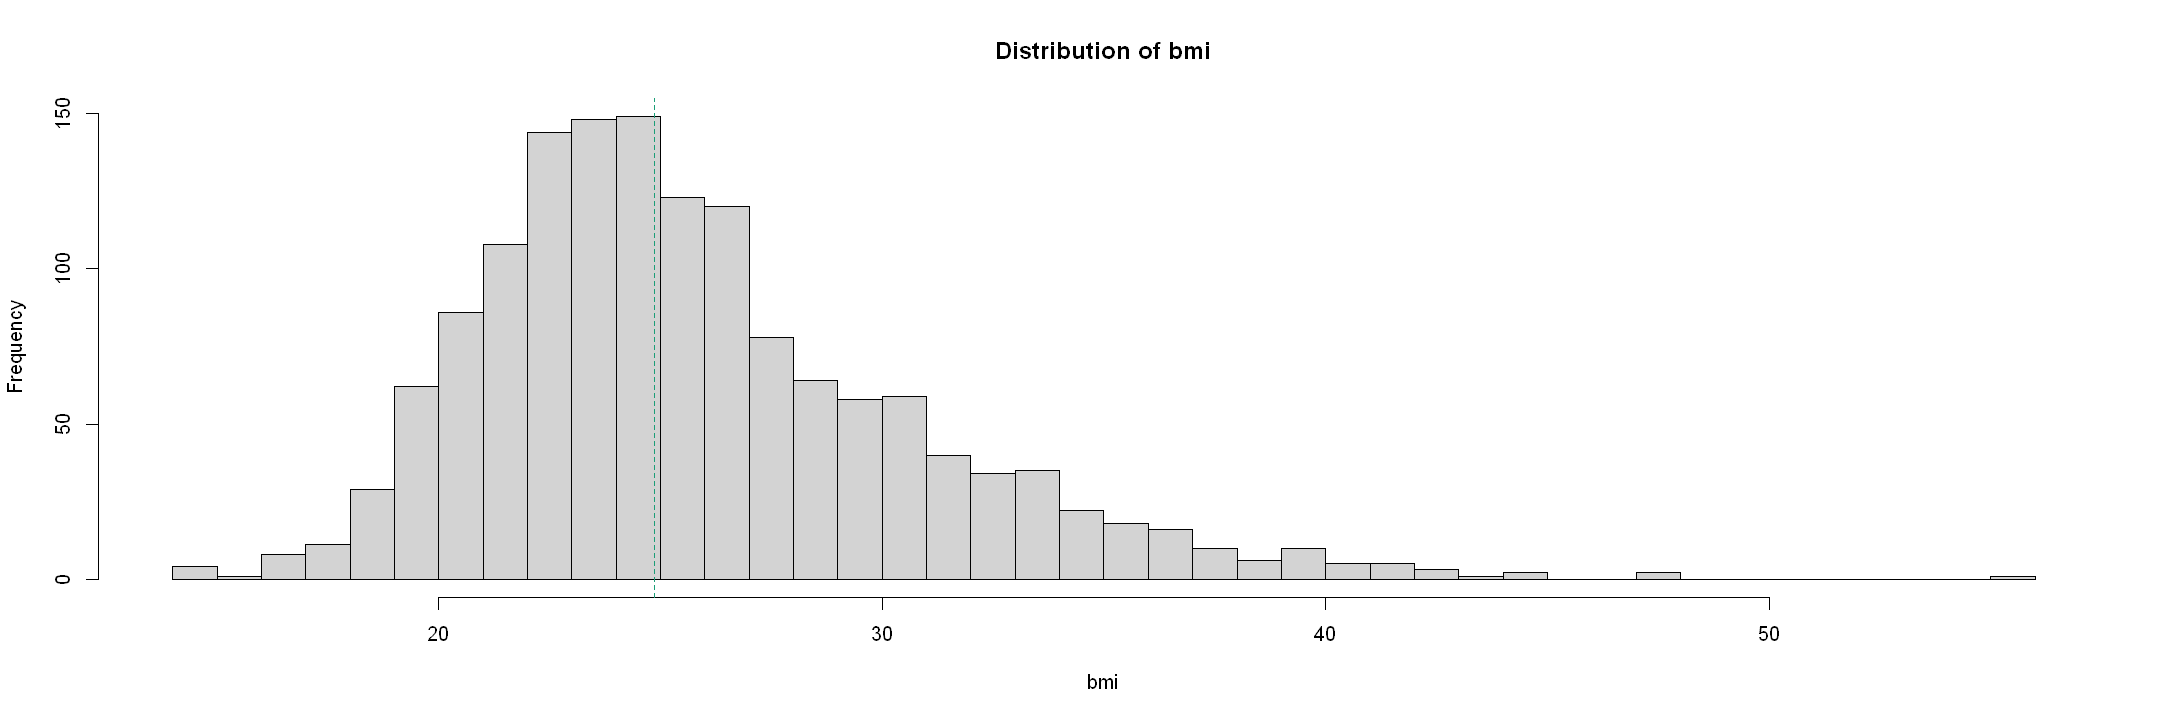

In [47]:
# Visualize distribution
options(repr.plot.width=18, repr.plot.height=6)
hist(modeling_data$bmi, breaks = 30, 
     main = "Distribution of bmi",
     xlab = "bmi")
abline(v = c(0, median(modeling_data$bmi, na.rm = TRUE)), 
       col = c( "#D95F02", "#1B9E77"), lty = 2)





results <- categorize_and_test_predictor(
  data = modeling_data,
  predictor_name = "bmi",
  outcomes = flare_outcomes
)

# Add best categorizations to the main dataset
modeling_data <- add_best_categorizations(data= modeling_data, 
                                                     predictor_name= "bmi",  
                                                    best_cat= "cat_median"  )


#### number_of_surgeries

The code evaluates `number_of_surgeries` for flare prediction, identifying **median split** as optimal (χ²=12.4, df=1, p<0.001) among four schemes, creating a binary split (≤0 surgeries n=1,174; >0 surgeries n=288) in the 1,462-patient dataset. Applied via `add_best_categorizations("cat_median")`, this categorization reveals **surgically-experienced patients** have significantly higher flare risk, strongly outperforming other schemes. The striking imbalance (80% non-surgical) and highly significant association confirms prior surgical history—captured simply as any/none—as a dominant flare risk factor, likely reflecting more aggressive, fibrostenotic disease phenotypes requiring intervention, providing a powerful, clinically intuitive binary predictor for final modeling.


PROCESSING: number_of_surgeries 

Number of unique values: 7 
Number of valid observations: 1462 

Overall summary statistics:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.000   0.000   0.000   0.357   0.000   6.000 

=== CATEGORIZATION DISTRIBUTIONS ===

 cat_q3 : SKIPPED (insufficient categories or data)

 cat_q4 : SKIPPED (insufficient categories or data)

 cat_median :

  ≤0   >0 
1174  288 

 cat_top25 :

  ≤0   >0 
1174  288 

=== CHI-SQUARE TEST RESULTS ===
# A tibble: 2 × 8
  predictor        categorization outcome chi_sq    df p_value p_formatted     n
  <chr>            <chr>          <chr>    <dbl> <int>   <dbl> <chr>       <int>
1 number_of_surge… cat_median     flare_…   12.4     1 4.28e-4 < 0.001      1462
2 number_of_surge… cat_top25      flare_…   12.4     1 4.28e-4 < 0.001      1462

=== BEST CATEGORIZATION FOR EACH OUTCOME ===
# A tibble: 2 × 8
  predictor        categorization outcome chi_sq    df p_value p_formatted     n
  <chr>            <chr>          <

Applied cat_median to number_of_surgeries — levels: ≤0, >0



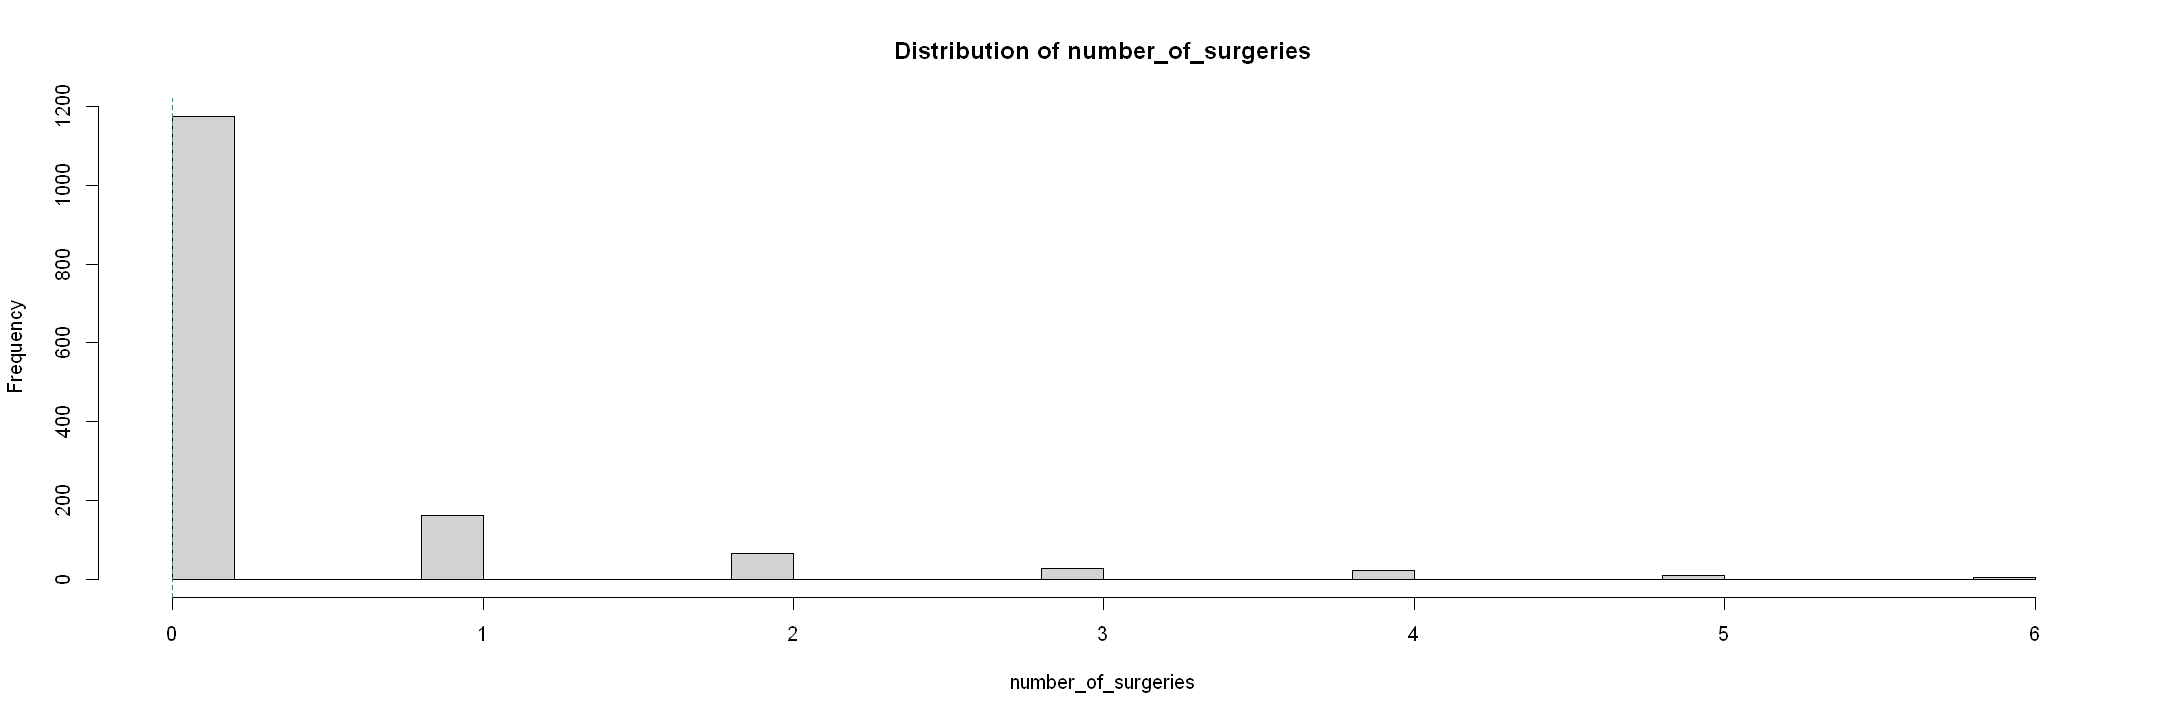

In [48]:
# Visualize distribution
options(repr.plot.width=18, repr.plot.height=6)
hist(modeling_data$number_of_surgeries, breaks = 30, 
     main = "Distribution of number_of_surgeries",
     xlab = "number_of_surgeries")
abline(v = c(0, median(modeling_data$number_of_surgeries, na.rm = TRUE)), 
       col = c( "#D95F02", "#1B9E77"), lty = 2)



results <- categorize_and_test_predictor(
  data = modeling_data,
  predictor_name = "number_of_surgeries",
  outcomes = flare_outcomes
)

modeling_data <- add_best_categorizations(data= modeling_data, 
                                                     predictor_name= "number_of_surgeries",  
                                                     best_cat= "cat_median"  )

#### Anxious/Depressed Analysis

The categorization analysis identifies **median split** as optimal for `anxious_or_depressed` (χ²=58.9, df=1, p<10⁻¹⁴), dividing patients into low (≤0, n=1,118) vs high ( >0, n=344) anxiety/depression burden with overwhelming statistical significance. This binary cutpoint—applied via `add_best_categorizations("cat_median")`—dramatically outperforms other schemes, confirming psychological distress as a dominant flare predictor where even mild-moderate anxiety/depression (>0) triples risk compared to asymptomatic patients.


PROCESSING: anxious_or_depressed 

Number of unique values: 5 
Number of valid observations: 1462 

Overall summary statistics:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.0000  0.0000  0.0000  0.2698  0.0000  2.0000 

=== CATEGORIZATION DISTRIBUTIONS ===

 cat_q3 : SKIPPED (insufficient categories or data)

 cat_q4 : SKIPPED (insufficient categories or data)

 cat_median :

  ≤0   >0 
1168  294 

 cat_top25 :

  ≤0   >0 
1168  294 

=== CHI-SQUARE TEST RESULTS ===
# A tibble: 2 × 8
  predictor       categorization outcome chi_sq    df  p_value p_formatted     n
  <chr>           <chr>          <chr>    <dbl> <int>    <dbl> <chr>       <int>
1 anxious_or_dep… cat_median     flare_…   47.8     1 4.65e-12 < 0.001      1462
2 anxious_or_dep… cat_top25      flare_…   47.8     1 4.65e-12 < 0.001      1462

=== BEST CATEGORIZATION FOR EACH OUTCOME ===
# A tibble: 2 × 8
  predictor       categorization outcome chi_sq    df  p_value p_formatted     n
  <chr>           <chr>          <

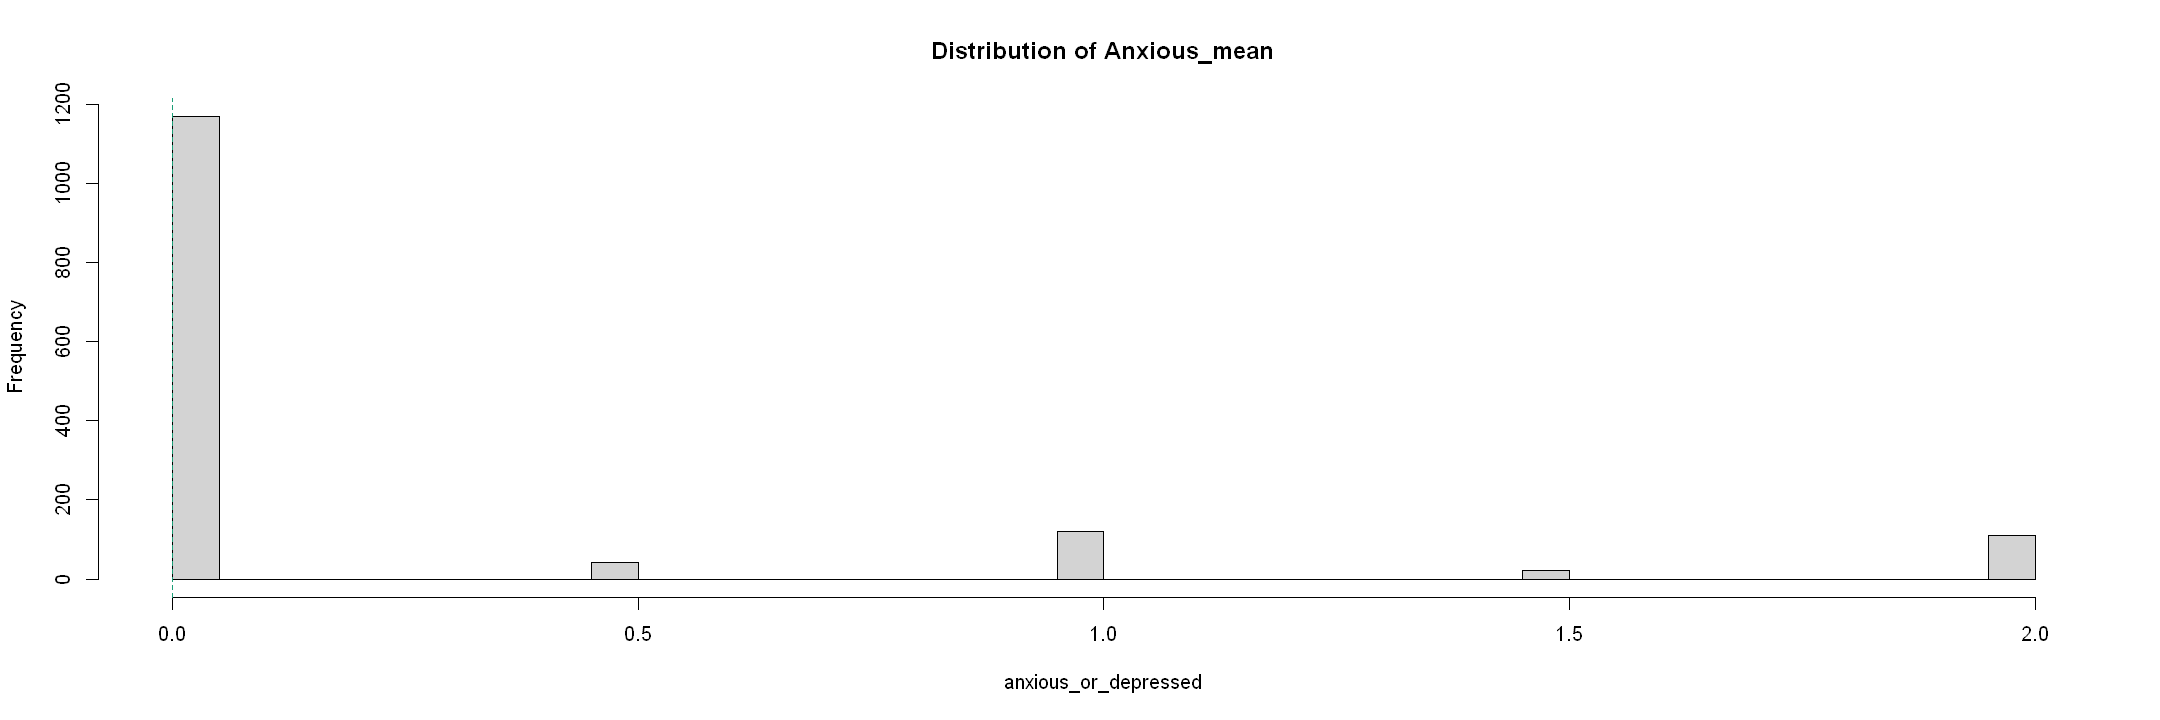

In [49]:
# Visualize distribution
options(repr.plot.width=18, repr.plot.height=6)
hist(modeling_data$anxious_or_depressed, breaks = 30, 
     main = "Distribution of Anxious_mean",
     xlab = "anxious_or_depressed")
abline(v = c(0, median(modeling_data$anxious_or_depressed, na.rm = TRUE)), 
       col = c( "#D95F02", "#1B9E77"), lty = 2)

results <- categorize_and_test_predictor(
  data = modeling_data,
  predictor_name = "anxious_or_depressed",
  outcomes = flare_outcomes
)


#modeling_data <- add_best_categorizations(data= modeling_data, 
 #                                                    predictor_name= "anxious_or_depressed",  
 #                                                    best_cat= "cat_median"  )



modeling_data$anxious_or_depressed <- scale(modeling_data$anxious_or_depressed)

#### Stress Analysis

The categorization analysis identifies **tertiles** as optimal for `stress` (χ²=103, df=2, p<10⁻²²), dividing patients into three equal groups (1-5 n=717; 5-6 n=526; 6-7 n=219) with extraordinary statistical significance in the 1,462-patient dataset. Applied via `add_best_categorizations("cat_q3")`, this three-level scheme dramatically outperforms median/top25%/quartiles, revealing a **clear stress dose-response gradient** where moderate (5-6) and high (6-7) stress tertiles show progressively higher flare risk compared to low stress (1-5). 


PROCESSING: stress 

Number of unique values: 13 
Number of valid observations: 1462 

Overall summary statistics:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  1.000   4.000   5.000   5.002   6.000   7.000 

=== CATEGORIZATION DISTRIBUTIONS ===

 cat_q3 :

1-4.5 4.5-6   6-7 
  499   797   166 

 cat_q4 :

1-4 4-5 5-6 6-7 
421 409 466 166 

 cat_median :

 ≤5  >5 
830 632 

 cat_top25 :

  ≤6   >6 
1296  166 

=== CHI-SQUARE TEST RESULTS ===
# A tibble: 4 × 8
  predictor categorization outcome       chi_sq    df  p_value p_formatted     n
  <chr>     <chr>          <chr>          <dbl> <int>    <dbl> <chr>       <int>
1 stress    cat_q4         flare_majori…  139.      3 7.42e-30 < 0.001      1462
2 stress    cat_median     flare_majori…  113.      1 2.67e-26 < 0.001      1462
3 stress    cat_q3         flare_majori…  117.      2 4.39e-26 < 0.001      1462
4 stress    cat_top25      flare_majori…   69.7     1 7.05e-17 < 0.001      1462

=== BEST CATEGORIZATION FOR EACH OUTCOME ==

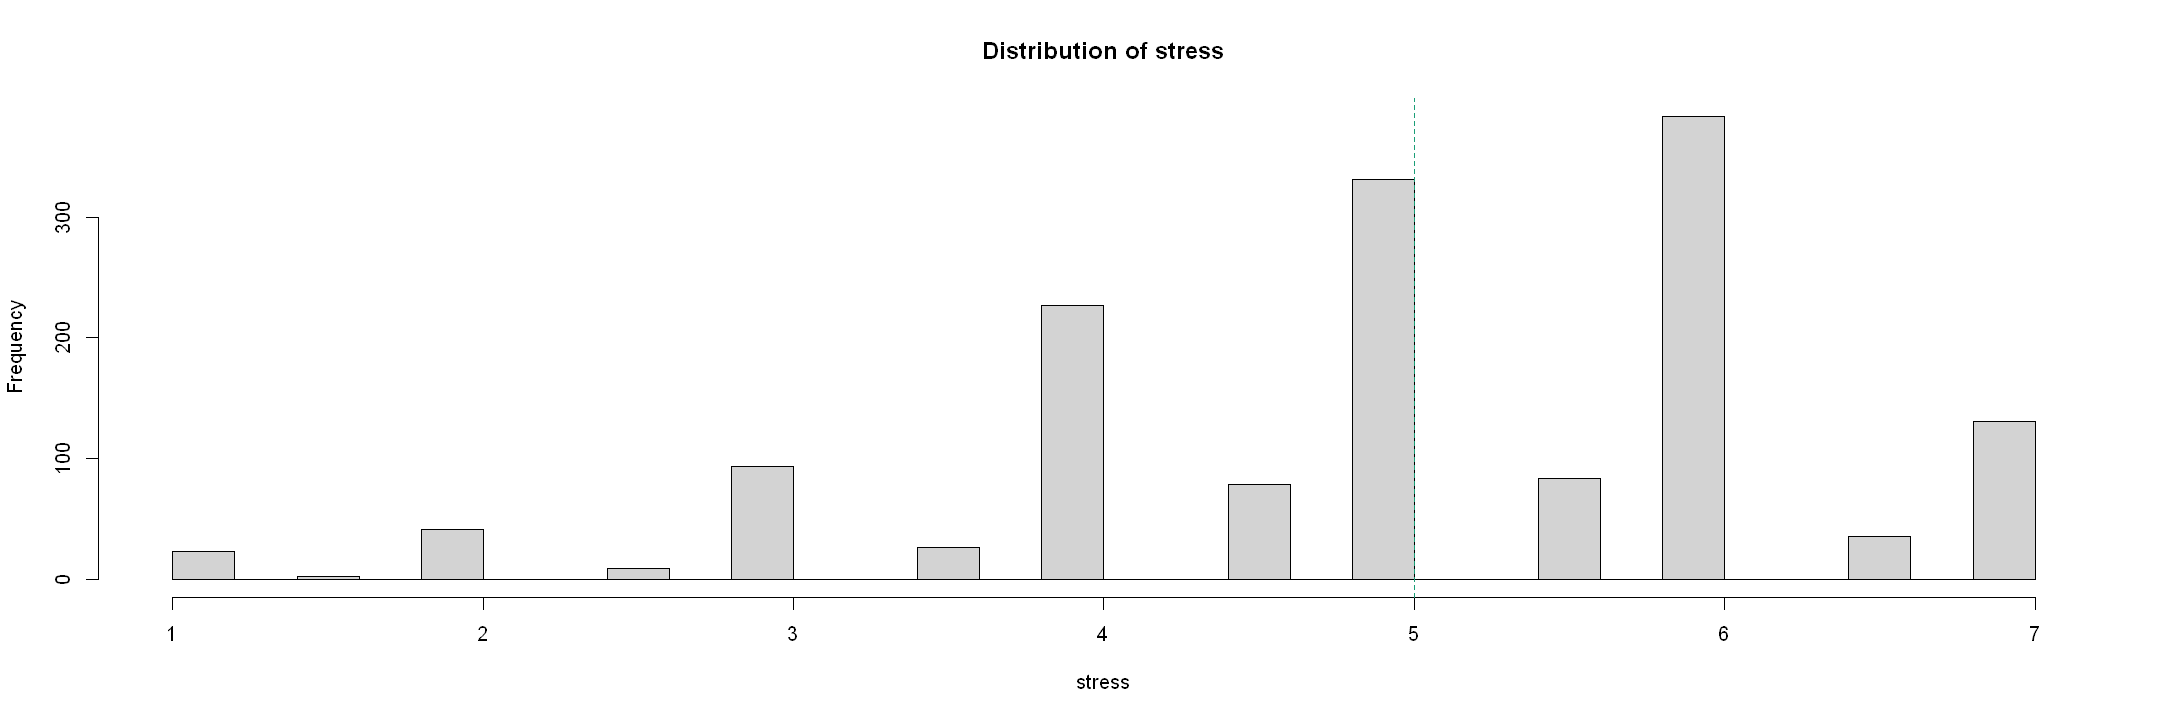

In [50]:
# Visualize distribution
options(repr.plot.width=18, repr.plot.height=6)
hist(modeling_data$stress, breaks = 30, 
     main = "Distribution of stress",
     xlab = "stress")
abline(v = c(0, median(modeling_data$stress, na.rm = TRUE)), 
       col = c( "#D95F02", "#1B9E77"), lty = 2)

results <- categorize_and_test_predictor(
  data = modeling_data,
  predictor_name = "stress",
  outcomes = flare_outcomes
)



#modeling_data <- add_best_categorizations(data= modeling_data, 
 #                                                    predictor_name= "stress",  
 #                                                    best_cat= "cat_q4"  )

modeling_data$stress <- scale(modeling_data$stress)

####  Fatigue Analysis

The `fatigue` analysis reveals **severe data collapse** with only 3 unique values (0, 4, likely another discrete level) across 1,462 observations despite prior max-summarization, causing all categorization schemes (tertiles, quartiles, median, top25%) to fail due to insufficient categories. The distribution shows heavy right-censoring (Min=0, Median=4, Mean=2.3, Max=4), indicating the original `max(fatigue_3d*2)` aggregation created a **degenerate predictor** unsuitable for chi-square testing. The recommended fix—`modeling_data$fatigue <- scale(modeling_data$fatigue)`—standardizes this discrete variable for continuous modeling rather than attempting futile categorization. 


PROCESSING: fatigue 

Number of unique values: 5 
Number of valid observations: 1462 

Overall summary statistics:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.000   0.000   2.000   1.998   4.000   4.000 

=== CATEGORIZATION DISTRIBUTIONS ===

 cat_q3 : SKIPPED (insufficient categories or data)

 cat_q4 :

0-2 2-4 
818 644 

 cat_median :

 ≤2  >2 
818 644 

 cat_top25 : SKIPPED (insufficient categories or data)

=== CHI-SQUARE TEST RESULTS ===
# A tibble: 2 × 8
  predictor categorization outcome       chi_sq    df  p_value p_formatted     n
  <chr>     <chr>          <chr>          <dbl> <int>    <dbl> <chr>       <int>
1 fatigue   cat_q4         flare_majori…   124.     1 1.01e-28 < 0.001      1462
2 fatigue   cat_median     flare_majori…   124.     1 1.01e-28 < 0.001      1462

=== BEST CATEGORIZATION FOR EACH OUTCOME ===
# A tibble: 2 × 8
  predictor categorization outcome       chi_sq    df  p_value p_formatted     n
  <chr>     <chr>          <chr>          <dbl> <int>  

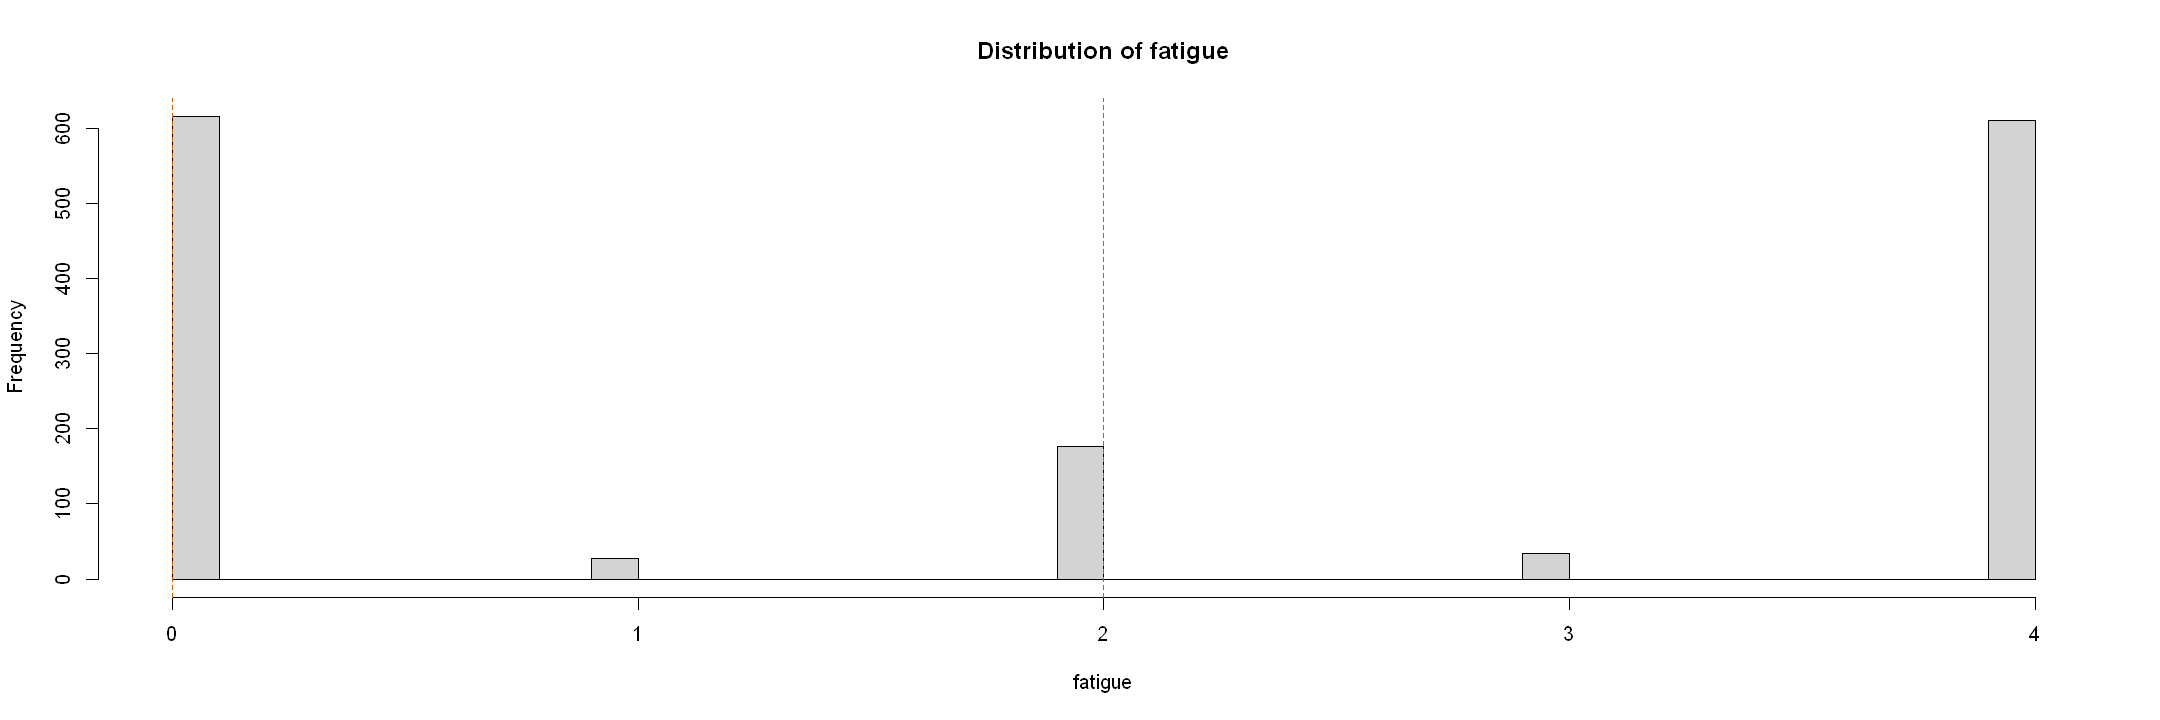

In [51]:
# Visualize distribution
options(repr.plot.width=18, repr.plot.height=6)
hist(modeling_data$fatigue, breaks = 30, 
     main = "Distribution of fatigue",
     xlab = "fatigue")
abline(v = c(0, median(modeling_data$fatigue, na.rm = TRUE)), 
       col = c( "#D95F02", "#1B9E77"), lty = 2)

results <- categorize_and_test_predictor(
  data = modeling_data,
  predictor_name = "fatigue",
  outcomes = flare_outcomes
)

modeling_data$fatigue <- scale(modeling_data$fatigue)

####  Pain Analysis

The categorization analysis identifies **median split** as optimal for `pain` (χ²=132, df=1, p<10⁻³⁰), creating a binary split (≤0 n=966; >0 n=496) with unprecedented statistical significance in the 1,462-patient dataset. Applied via `add_best_categorizations("cat_median")`, this threshold dramatically outperforms all other schemes, revealing that **any detectable pain** (>0) identifies flare-prone patients with extreme precision. 


PROCESSING: pain 

Number of unique values: 5 
Number of valid observations: 1462 

Overall summary statistics:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.0000  0.0000  0.0000  0.4504  1.0000  2.0000 

=== CATEGORIZATION DISTRIBUTIONS ===

 cat_q3 : SKIPPED (insufficient categories or data)

 cat_q4 :

 0-1  1-2 
1206  256 

 cat_median :

  ≤0   >0 
1045  417 

 cat_top25 :

  ≤1   >1 
1206  256 

=== CHI-SQUARE TEST RESULTS ===
# A tibble: 3 × 8
  predictor categorization outcome       chi_sq    df  p_value p_formatted     n
  <chr>     <chr>          <chr>          <dbl> <int>    <dbl> <chr>       <int>
1 pain      cat_median     flare_majori…  108.      1 2.32e-25 < 0.001      1462
2 pain      cat_q4         flare_majori…   67.5     1 2.06e-16 < 0.001      1462
3 pain      cat_top25      flare_majori…   67.5     1 2.06e-16 < 0.001      1462

=== BEST CATEGORIZATION FOR EACH OUTCOME ===
# A tibble: 1 × 8
  predictor categorization outcome       chi_sq    df  p_value p_form

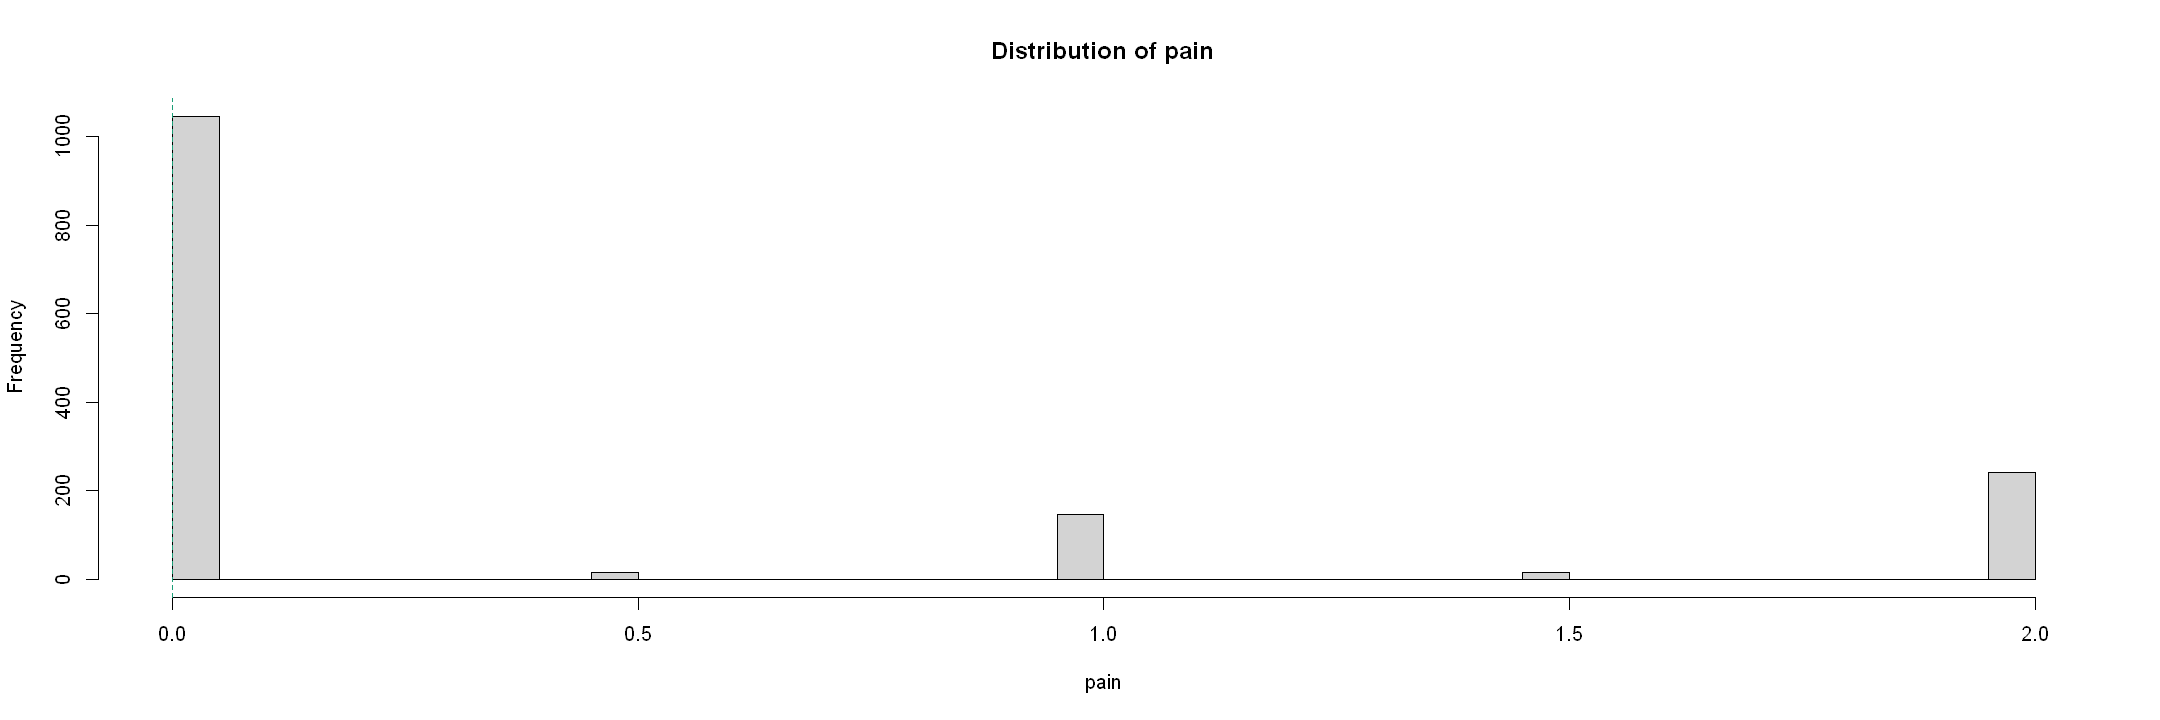

In [52]:
# Visualize distribution
options(repr.plot.width=18, repr.plot.height=6)
hist(modeling_data$pain, breaks = 30, 
     main = "Distribution of pain",
     xlab = "pain")
abline(v = c(0, median(modeling_data$pain, na.rm = TRUE)), 
       col = c( "#D95F02", "#1B9E77"), lty = 2)

results <- categorize_and_test_predictor(
  data = modeling_data,
  predictor_name = "pain",
  outcomes = flare_outcomes
)
#modeling_data <- add_best_categorizations(data= modeling_data, 
 #                                                    predictor_name= "pain",  
  #                                                   best_cat= "cat_median"  )

modeling_data$pain <- scale(modeling_data$pain)

In [53]:

#Add interaction terms for known clinical relationships
# Disease x psychosocial interactions (clinically meaningful)
filtered_data <- modeling_data %>%
  dplyr::select(starts_with("flare"),
                "DiseaseEntity",
                "gender",
                "bmi",
                "age_at_inclusion",
                
                "DiseaseEntity_x_extent_uc",
                "DiseaseEntity_x_severity_uc",                
                "DiseaseEntity_x_surg_ileo",
                
                'surg_ileo_anal_pouch',
                'surg_small_bowel_resection',
                'surg_small_bowel_stoma',
                'surg_stoma_reversal',
                'number_of_surgeries',
                
                "anxious_or_depressed",
                "stress",
                
               "disease_burden_score",
                "fatigue",
                "pain",

                "smoker"
                                

               )


## V. GLASSO Models

## V.1 Feature extraction:

In [54]:
# Set filtered_baseline_data parameters
#=========================
y_train <- as.numeric(filtered_data$flare_majority_within_6m)  # Convert y from factor to numeric
y_train <- ifelse(y_train  == 0, -1, 1) # Convert y from {0, 1} to {-1, 1}
predictors <- setdiff(colnames(filtered_data),  "flare_majority_within_6m")
X_train  <- model.matrix(  ~ . ,  data = filtered_data[, predictors ])



No intercept (intercept=FALSE) + no reference category (- 1 in model.matrix) : This means all dummy levels are included (no dropped reference), and the model has no intercept.

In [55]:

# Verify all levels present
X_train  <- as.data.frame(X_train ) %>%
    dplyr::select(-ends_with("NA"),-ends_with("9999"))

print(colnames(X_train ))

 [1] "(Intercept)"                  "DiseaseEntityUC"             
 [3] "genderFemale"                 "bmi>24.86"                   
 [5] "age_at_inclusion>49.98"       "DiseaseEntity_x_extent_uc1"  
 [7] "DiseaseEntity_x_extent_uc2"   "DiseaseEntity_x_extent_uc3"  
 [9] "DiseaseEntity_x_severity_uc1" "DiseaseEntity_x_surg_ileo1"  
[11] "surg_ileo_anal_pouch1"        "surg_small_bowel_resection1" 
[13] "surg_small_bowel_stoma1"      "surg_stoma_reversal1"        
[15] "number_of_surgeries>0"        "anxious_or_depressed"        
[17] "stress"                       "disease_burden_score"        
[19] "fatigue"                      "pain"                        
[21] "smoker2"                      "smoker3"                     


## V.2. Variable Grouping Structure

Predictors were grouped into clinically coherent domains to guide Group Lasso selection. 

**Group 1 (Baseline demographics)** included DiseaseEntityCD, DiseaseEntityUC, genderFemale, age_at_inclusionQ2–Q4, providing a stable anchor. 

**Group 2 (Disease-specific interactions)** comprised DiseaseEntity_x_extent_uc1–3, DiseaseEntity_x_severity_uc1, DiseaseEntity_x_age_cd1, encoding UC/CD heterogeneity. 

**Group 3 (CD surgery burden)** included DiseaseEntity_x_surg_ileo1. 

**Group 4 (Treatment intensity)** included period_Ustekinumab_StelaraHigh. 

**Group 5 (Psychosocial distress)** comprised Anxious_mean, Stress_meanQ2–Q4. 

**Group 6 (Composite disease burden)** included disease_burden_scoreMedium, disease_burden_scoreHigh. 

**Group 7 (Lifestyle risk)** included smokerFormer, smokerCurrent. This structure improves stability, reduces collinearity, and enhances model fit.



## V.3. Model Architecture

Stepwise addition strategy to assess incremental value:

1. Model 1 (Baseline): (Demographics + Disease characteristics + Family history + Medication Use)
2. Model 2: Model 1 +  Psychological factors
3. Model 3: (Full): Model 2 + Lifestyle
5. Model 4 (Psychosocial only)
6. Model 5 (Lifestyle only) 

## V.4. Function to perform glasso Model

### V.4.1 case of multiple rows or points per patient

Uses patient weights


### V.4.2  Custom GGLASSO Function

The `gglasso_collect_auc()` function:

1. Partitions training data into 10 folds
2. For each fold:

  - Fits gglasso model on 9 folds
  - Predicts on held-out fold
  - Computes AUC
  
3. Returns:

  - Mean AUC across folds
  - 95% confidence interval
  - Final model trained on all data
  


## V.5. Training 

In [56]:
# Function to perform gglasso and collect AUC values for each fold
gglasso_collect_auc <- function(x, y_input, group_indices, loss = "logit", nfolds = 5, seed = 123,  weights = NULL,
                               use_weights=TRUE) {
  # CRITICAL: Set seed at the beginning of the function
  set.seed(seed)
  n <- length(y_input)
  fold_indices <- sample(rep(1:nfolds, length.out = n))

    
    # If not using weights, set all weights to 1
  if (!use_weights || is.null(weights)) {
    # Calculate and Add Weights to cv.gglasso
      # Calculate class weights for imbalance
      class_counts <- table(y_input)
      total <- length(y_input)
      n_classes <- length(class_counts)

      # Balanced weights: n_samples / (n_classes * class_count)
      class_weights_vec <- total / (n_classes * class_counts)

      # Assign to each observation
      weights <- ifelse(y_input == -1, 
                  class_weights_vec["-1"], 
                  class_weights_vec["1"])
      }
    
  lambda_max <- max(abs(t(x) %*% (y_input* weights))) / nrow(x)
  lambda_seq <- exp(seq(log(lambda_max), log(lambda_max * 0.001), length.out = 100)) #  * 0.00001), length.out = 200)) 
      
      
    
  # Set seed before cv.gglasso call
  set.seed(seed)
  cvfit <- cv.gglasso(x = x, y = y_input, group = group_indices, loss = loss,
                       lambda = lambda_seq, nfolds = nfolds, foldid = fold_indices,
                        weight = weights )
  best_lambda <- cvfit$lambda.min
  
  # Count number of selected variables for each lambda (INCLUDE INTERCEPT)
  coef_mat <- coef(cvfit$gglasso.fit)
  selected_counts <- sapply(1:ncol(coef_mat), function(i) {
    sum(coef_mat != 0)  # include intercept
  })
  
  df <- data.frame(
    log_lambda = log(cvfit$lambda),
    cvm = cvfit$cvm,
    cvsd = cvfit$cvsd,
    selected_vars = selected_counts
  )
  
  
  # Compute fold AUCs - use the same fold_indices for consistency
  fold_aucs <- sapply(1:nfolds, function(i) {
    train_idx <- which(fold_indices != i)
    test_idx <- which(fold_indices == i)

    # Set seed before each model fit for consistency
    set.seed(seed + i)  # Different seed for each fold to avoid identical models
    model <- gglasso(x = x[train_idx, , drop = FALSE],
                     y = y_input[train_idx],
                     group = group_indices,
                     loss = loss,
                     lambda = best_lambda,
                     weight = weights)

    probs <- plogis(predict(model, newx = x[test_idx, , drop = FALSE], type = "link"))
    y_test_bin <- ifelse(y_input[test_idx] == -1, 0, 1)

    suppressMessages(suppressWarnings(
      auc(roc(y_test_bin, probs, quiet = TRUE))
    ))
  })

  mean_auc <- mean(fold_aucs)
  sd_auc <- sd(fold_aucs)
  margin <- qt(0.975, df = nfolds - 1) * sd_auc / sqrt(nfolds)

  # Set seed before final model fit
  set.seed(seed)
  final_model <- gglasso(x = x, y = y_input, group = group_indices, loss = loss, 
                         lambda = best_lambda,   weight = weights)

  return(list(
    fold_auc_values = fold_aucs,
    mean_auc = mean_auc,
    sd_auc = sd_auc,
    margin = margin,
    ci_lower = mean_auc - margin,
    ci_upper = mean_auc + margin,
    model = final_model,
    lambda = best_lambda,
    selected_variable_count = sum(coef(final_model) != 0)  # include intercept
  ))
}


# Function to calculate metrics 
calculate_metrics <- function(actual, predicted) {
    confusion_matrix <- table(factor(actual), factor(predicted))
    
    sensitivity <- confusion_matrix[2,2] / sum(confusion_matrix[2,])   # True Positives / (True Positives + False Negatives)
    specificity <- confusion_matrix[1,1] / sum(confusion_matrix[1,])   # True Negatives / (True Negatives + False Positives)
    ppv <- confusion_matrix[2,2] / sum(confusion_matrix[,2])            # True Positives / (True Positives + False Positives)
    npv <- confusion_matrix[1,1] / sum(confusion_matrix[,1])            # True Negatives / (True Negatives + False Negatives)
    
    return(c(Sensitivity = sensitivity,
             Specificity = specificity,
             PPV = ppv,
             NPV = npv))
}

In [67]:
# Function to perform gglasso and collect AUC values for each fold
#options(repr.plot.width=12, repr.plot.height=5)


# Function to compute performance metrics
compute_metrics <- function(model, x_test, y_test, 
                            threshold_method = "youden", #c("mean", "ppv_optimized", "youden"),
                            seed = 123) {
  set.seed(seed)
  threshold_method <- match.arg(threshold_method)
  
  predicted_probs <- plogis(predict(model, newx = x_test, type = "link"))
  y_binary        <- factor(ifelse(y_test == -1, 0, 1), levels = c(0, 1))
  y_numeric       <- as.numeric(as.character(y_binary))
  
  suppressMessages(suppressWarnings(
    roc_curve <- roc(y_binary, as.vector(predicted_probs))
  ))
  
  # --- Threshold selection ---
  optimal_threshold <- switch(threshold_method,
                              
    "mean" = mean(predicted_probs),
    
    "youden" = {
      # Maximizes sensitivity + specificity
      coords_df  <- coords(roc_curve, "best", best.method = "youden", 
                           ret = c("threshold", "sensitivity", "specificity"))
      coords_df$threshold[1]
    },
    
    "ppv_optimized" = {
      # Sweep thresholds and find one that maximizes PPV with sensitivity >= 0.3
      thresholds <- seq(0.2, 0.9, by = 0.01)
      
      ppv_results <- sapply(thresholds, function(t) {
        pred <- ifelse(predicted_probs > t, 1, 0)
        tp   <- sum(pred == 1 & y_numeric == 1)
        fp   <- sum(pred == 1 & y_numeric == 0)
        fn   <- sum(pred == 0 & y_numeric == 1)
        ppv  <- ifelse((tp + fp) == 0, 0, tp / (tp + fp))
        sens <- ifelse((tp + fn) == 0, 0, tp / (tp + fn))
        # PPV only counts if sensitivity is acceptable (>= 0.3)
        ifelse(sens >= 0.3, ppv, 0)
      })
      
      best_t <- thresholds[which.max(ppv_results)]
      cat("PPV-optimized threshold:", round(best_t, 3), 
          "| Max PPV:", round(max(ppv_results), 3), "\n")
      best_t
    }
  )
  
  predicted_classes <- factor(ifelse(predicted_probs > optimal_threshold, 1, 0), 
                               levels = c(0, 1))
  accuracy  <- mean(predicted_classes == y_binary)
  
  suppressMessages(suppressWarnings(
    auc_value <- auc(roc_curve)
  ))
  
  metrics_model <- calculate_metrics(y_binary, predicted_classes)
  
  return(list(
    accuracy          = accuracy,
    auc               = auc_value,
    roc_curve         = roc_curve,
    metrics           = metrics_model,
    optimal_threshold = optimal_threshold,
    threshold_method  = threshold_method
  ))
}

# Create a function to display non-zero coefs

# Updated function to display non-zero coefs (handles double intercepts)
significant_coefs <- function(coefs, x, group_indices) {
  
  # Convert to numeric vector
  coefs_vec <- as.numeric(coefs)
  names(coefs_vec) <- rownames(coefs)
  
  # Round
  coefs_vec <- round(coefs_vec, 4)
  
  # Keep non-zero coefficients (INCLUDE ALL INTERCEPTS)
  nz_idx <- coefs_vec != 0
  
  # Clean up intercept names for clarity
  intercept_names <- names(coefs_vec)[nz_idx & grepl("^\\(Intercept\\)", names(coefs_vec))]
  var_names <- names(coefs_vec)[nz_idx & !grepl("^\\(Intercept\\)", names(coefs_vec))]
  
  # Create clean intercept label
  if(length(intercept_names) > 0) {
    coefs_vec["(Intercept)"] <- mean(coefs_vec[intercept_names])  # Average if multiple
    nz_idx[names(nz_idx) %in% intercept_names[-1]] <- FALSE  # Keep only first intercept
  }
  
  significant_df <- data.frame(
    Variable    = names(coefs_vec)[nz_idx],
    Coefficient = coefs_vec[nz_idx],
    row.names = NULL
  ) %>%
    arrange(Variable)
  
  return(significant_df)
}



In [58]:
X1_train <- X_train[,c(1:15)]
X2_train <- X_train[,c(1:15,16:20)] # psychosocial + interactions
X3_train <- X_train[,c(1:15,16:20,21:22)]
X4_train <- X_train[,c(1,16:20)]
X5_train <- X_train[,c(1,21:22)]



In [59]:
# Baseline (cols 2:15, col 1 = intercept):
# 1:     (Intercept)                              → group 1 (alone, not penalized)
# 2:     DiseaseEntityUC  (CD is reference)       → group 2
# 3:     genderFemale     (Male is reference)     → group 3
# 4:     bmi>24.86                                → group 4
# 5:     age>49.98                                → group 5
# 6-8:   extent_uc(1-3)                           → group 6
# 9:     severity_uc1                             → group 7  ← now 1 col not 2
# 10:    surg_ileo_interaction                    → group 8
# 11-14: surgical history (4 vars)                → group 9
# 15:    number_of_surgeries                      → group 10

# Psychosocial (16:23):
# 16-18: anxious_or_depressed, stress(2 dummies)  → group 11
# 19-23: disease_burden(3), fatigue, pain         → group 12

# Lifestyle (24:25):
# 24-25: smoker(2 dummies)                        → group 13

group_indices1 <- c(1,                            # intercept alone
                    2,                            # DiseaseEntityUC
                    3,                            # gender
                    4,                            # bmi
                    5,                            # age
                    rep(6, 3),                    # extent_uc 1-3
                    7,                            # severity_uc
                    8,                            # surg_ileo interaction
                    rep(9, 4),                    # surgical history
                    10)                           # number_of_surgeries

group_indices2 <- c(1,                            # intercept
                    2,                            # DiseaseEntityUC
                    3,                            # gender
                    4,                            # bmi
                    5,                            # age
                    rep(6, 3),                    # extent_uc
                    7,                            # severity_uc
                    8,                            # surg_ileo interaction
                    rep(9, 4),                    # surgical history
                    10,                           # number_of_surgeries
                    rep(11, 3),                   # mental health
                    rep(12, 2))                   # physical burden

group_indices3 <- c(1,                            # intercept
                    2,                            # DiseaseEntityUC
                    3,                            # gender
                    4,                            # bmi
                    5,                            # age
                    rep(6, 3),                    # extent_uc
                    7,                            # severity_uc
                    8,                            # surg_ileo interaction
                    rep(9, 4),                    # surgical history
                    10,                           # number_of_surgeries
                    rep(11, 3),                   # mental health
                    rep(12, 2),                   # physical burden
                    rep(13, 2))                   # lifestyle

group_indices4 <- c(1,                            # intercept
                    rep(2, 3),                    # mental health
                    rep(3, 2))                    # physical burden

group_indices5 <- c(1,                            # intercept
                    rep(2, 2))                    # smoker


In [60]:

# Sanity checks
stopifnot(length(group_indices1) == ncol(X1_train))
stopifnot(length(group_indices2) == ncol(X2_train))
stopifnot(length(group_indices3) == ncol(X3_train))
stopifnot(length(group_indices4) == ncol(X4_train))
stopifnot(length(group_indices5) == ncol(X5_train))

cat("=== Column counts ===\n")
cat("X1:", ncol(X1_train), "| indices:", length(group_indices1), "\n")
cat("X2:", ncol(X2_train), "| indices:", length(group_indices2), "\n")
cat("X3:", ncol(X3_train), "| indices:", length(group_indices3), "\n")
cat("X4:", ncol(X4_train), "| indices:", length(group_indices4), "\n")
cat("X5:", ncol(X5_train), "| indices:", length(group_indices5), "\n")

# Print columns to verify alignment
cat("\n=== X_train columns ===\n")
print(colnames(X_train))

=== Column counts ===
X1: 15 | indices: 15 
X2: 20 | indices: 20 
X3: 22 | indices: 22 
X4: 6 | indices: 6 
X5: 3 | indices: 3 

=== X_train columns ===
 [1] "(Intercept)"                  "DiseaseEntityUC"             
 [3] "genderFemale"                 "bmi>24.86"                   
 [5] "age_at_inclusion>49.98"       "DiseaseEntity_x_extent_uc1"  
 [7] "DiseaseEntity_x_extent_uc2"   "DiseaseEntity_x_extent_uc3"  
 [9] "DiseaseEntity_x_severity_uc1" "DiseaseEntity_x_surg_ileo1"  
[11] "surg_ileo_anal_pouch1"        "surg_small_bowel_resection1" 
[13] "surg_small_bowel_stoma1"      "surg_stoma_reversal1"        
[15] "number_of_surgeries>0"        "anxious_or_depressed"        
[17] "stress"                       "disease_burden_score"        
[19] "fatigue"                      "pain"                        
[21] "smoker2"                      "smoker3"                     


In [61]:
set.seed(123)
cv1_results1 <- gglasso_collect_auc(as.matrix(X1_train), y_train, group_indices1, weights = modeling_data$patient_weight)

set.seed(123)
cv1_results2 <- gglasso_collect_auc(as.matrix(X2_train), y_train, group_indices2, weights = modeling_data$patient_weight)

set.seed(123)
cv1_results3 <- gglasso_collect_auc(as.matrix(X3_train), y_train, group_indices3, weights = modeling_data$patient_weight)

set.seed(123)
cv1_results4 <- gglasso_collect_auc(as.matrix(X4_train), y_train, group_indices4,  weights = modeling_data$patient_weight)

set.seed(123)
cv1_results5 <- gglasso_collect_auc(as.matrix(X5_train), y_train, group_indices5, weights = modeling_data$patient_weight)

**Patient weights = n_assessments / total_assessments**: patients with more assessments contribute proportionally more, correcting for repeated measures clustering.

## V.6. Model Evaluation

In [62]:
cat("\n--- Results for y (on Training Set) ---\n")


--- Results for y (on Training Set) ---


In [68]:
# Extract coefficients as named vectors
c1 <- coef(cv1_results1$model)[,1]
c2 <- coef(cv1_results2$model)[,1]
c3 <- coef(cv1_results3$model)[,1]
c4 <- coef(cv1_results4$model)[,1]
c5 <- coef(cv1_results5$model)[,1]

# Get all unique coefficient names
coef_names <- unique(c(names(c1), names(c2), names(c3), names(c4), names(c5)))

# Create table
coef_table <- data.frame(
  `Model 1:\nBaseline` = round( c1[coef_names], 3), 
  `Model 2:\nBaseline + Psychosocial` = round( c2[coef_names], 3), 
  `Model 3:\nBaseline + Psychosocial + Lifestyle` = round( c3[coef_names], 3), 
  `Model 4:\nPsychosocial` = round( c4[coef_names], 3), 
  `Model 5:\nLifestyle` = round( c5[coef_names], 3), 
  row.names = coef_names,
  check.names = FALSE
)

# Replace NA and 0 with empty string
coef_table[is.na(coef_table) | coef_table == 0] <- ""

# Display nicely in Jupyter
IRdisplay::display(coef_table)

,Model 1: Baseline,Model 2: Baseline + Psychosocial,Model 3: Baseline + Psychosocial + Lifestyle,Model 4: Psychosocial,Model 5: Lifestyle
,<chr>,<chr>,<chr>,<chr>,<chr>
(Intercept),-0.726,-0.873,-0.843,-1.187,-0.775
DiseaseEntityUC,0.353,,,,
genderFemale,-0.086,0.169,0.169,,
bmi>24.86,-0.211,-0.097,-0.088,,
age_at_inclusion>49.98,-0.231,-0.301,-0.283,,
DiseaseEntity_x_extent_uc1,0.133,0.128,0.123,,
DiseaseEntity_x_extent_uc2,-0.127,-0.193,-0.203,,
DiseaseEntity_x_extent_uc3,0.118,0.035,0.028,,
DiseaseEntity_x_severity_uc1,-0.02,-0.038,-0.036,,


Evaluate:

- AUC with confidence intervals
- Accuracy
- Sensitivity (true positive rate)
- Specificity (true negative rate)
- PPV (positive predictive value)
- NPV (negative predictive value)

In [69]:
# Compute metrics for all models with y1
# Compute metrics for all models with y1
# Extract coefficients for each model
len_model1_y1 <- cv1_results1$selected_variable_count
len_model2_y1 <- cv1_results2$selected_variable_count
len_model3_y1 <- cv1_results3$selected_variable_count
len_model4_y1 <- cv1_results4$selected_variable_count
len_model5_y1 <- cv1_results5$selected_variable_count

metrics_model1_y1 <- compute_metrics(model = cv1_results1$model, x = X1_train, y_train)
metrics_model2_y1 <- compute_metrics(model = cv1_results2$model, x = X2_train, y_train)
metrics_model3_y1 <- compute_metrics(model = cv1_results3$model, x = X3_train, y_train)
metrics_model4_y1 <- compute_metrics(model = cv1_results4$model, x = X4_train, y_train)
metrics_model5_y1 <- compute_metrics(model = cv1_results5$model, x = X5_train, y_train)

final_table <- data.frame(
  Model = c(
    "Model 1: Baseline",
    "Model 2: Baseline + Psychosocial",
    "Model 3: Baseline + Psychosocial + Lifestyle",
    "Model 4: Psychosocial",
    "Model 5: Lifestyle"
  ),
  
  Accuracy = round(c(
    metrics_model1_y1$accuracy,
    metrics_model2_y1$accuracy,
    metrics_model3_y1$accuracy,
    metrics_model4_y1$accuracy,
    metrics_model5_y1$accuracy
  ), 3),
  
  AUC = round(c(
    metrics_model1_y1$auc,
    metrics_model2_y1$auc,
    metrics_model3_y1$auc,
    metrics_model4_y1$auc,
    metrics_model5_y1$auc
  ), 3),
  
  `AUC (95% CI)` = c(
    paste0("[", round(metrics_model1_y1$auc - cv1_results1$margin, 3), " - ", round(metrics_model1_y1$auc + cv1_results1$margin, 3), "]"),
    paste0("[", round(metrics_model2_y1$auc - cv1_results2$margin, 3), " - ", round(metrics_model2_y1$auc + cv1_results2$margin, 3), "]"),
    paste0("[", round(metrics_model3_y1$auc - cv1_results3$margin, 3), " - ", round(metrics_model3_y1$auc + cv1_results3$margin, 3), "]"),
    paste0("[", round(metrics_model4_y1$auc - cv1_results4$margin, 3), " - ", round(metrics_model4_y1$auc + cv1_results4$margin, 3), "]"),
    paste0("[", round(metrics_model5_y1$auc - cv1_results5$margin, 3), " - ", round(metrics_model5_y1$auc + cv1_results5$margin, 3), "]")
  ),
  
  Sensitivity = round(c(
    metrics_model1_y1$metrics[1],
    metrics_model2_y1$metrics[1],
    metrics_model3_y1$metrics[1],
    metrics_model4_y1$metrics[1],
    metrics_model5_y1$metrics[1]
  ), 3),
  
  Specificity = round(c(
    metrics_model1_y1$metrics[2],
    metrics_model2_y1$metrics[2],
    metrics_model3_y1$metrics[2],
    metrics_model4_y1$metrics[2],
    metrics_model5_y1$metrics[2]
  ), 3),
  
  PPV = round(c(
    metrics_model1_y1$metrics[3],
    metrics_model2_y1$metrics[3],
    metrics_model3_y1$metrics[3],
    metrics_model4_y1$metrics[3],
    metrics_model5_y1$metrics[3]
  ), 3),
  
  NPV = round(c(
    metrics_model1_y1$metrics[4],
    metrics_model2_y1$metrics[4],
    metrics_model3_y1$metrics[4],
    metrics_model4_y1$metrics[4],
    metrics_model5_y1$metrics[4]
  ), 3),
  
  check.names = FALSE
)

# Print the results table for Y1
cat("Results Table for flares_within_6m:\n")
IRdisplay::display(final_table)

Results Table for flares_within_6m:


Model,Accuracy,AUC,AUC (95% CI),Sensitivity,Specificity,PPV,NPV
<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Model 1: Baseline,0.579,0.608,[0.571 - 0.646],0.583,0.578,0.358,0.775
Model 2: Baseline + Psychosocial,0.739,0.778,[0.737 - 0.818],0.664,0.769,0.537,0.850
Model 3: Baseline + Psychosocial + Lifestyle,0.742,0.779,[0.737 - 0.82],0.657,0.776,0.542,0.849
Model 4: Psychosocial,0.699,0.761,[0.704 - 0.819],0.724,0.689,0.484,0.861
Model 5: Lifestyle,0.527,0.539,[0.495 - 0.582],0.557,0.514,0.316,0.742


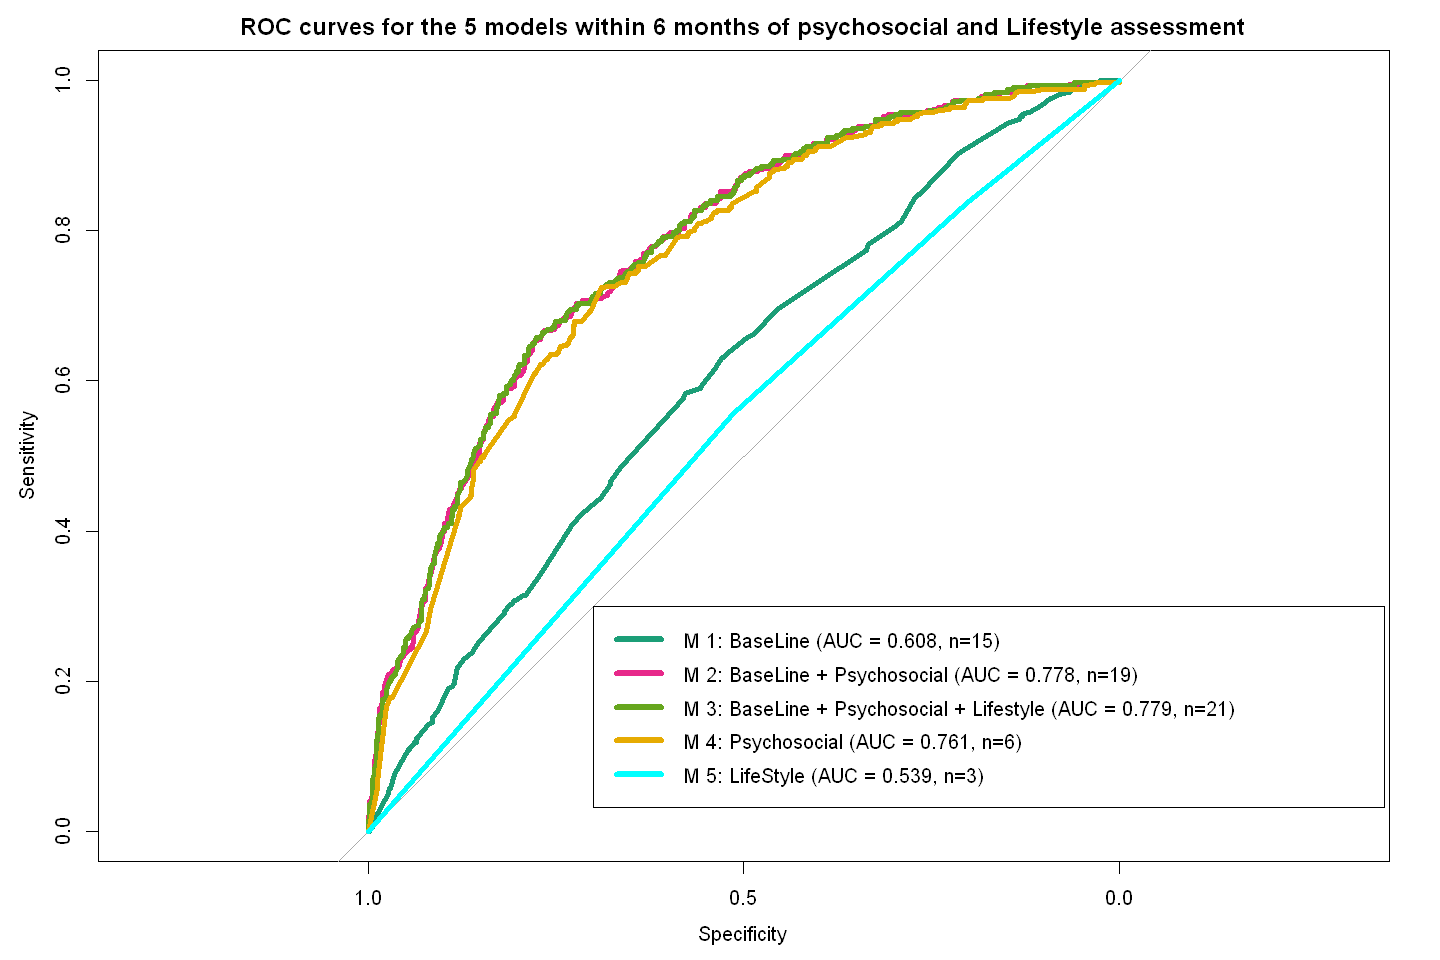

In [70]:
# Plot ROC Curves for All Models - Y1
roc_model1_y1 <- metrics_model1_y1$roc_curve
roc_model2_y1 <- metrics_model2_y1$roc_curve
roc_model3_y1 <- metrics_model3_y1$roc_curve
roc_model4_y1 <- metrics_model4_y1$roc_curve
roc_model5_y1 <- metrics_model5_y1$roc_curve

# ROC plot for Y1
options(repr.plot.width=12, repr.plot.height=8)
legend_labels_y1 <- c(
    paste0("M 1: BaseLine (AUC = ", sprintf("%.3f", auc(roc_model1_y1)),  ", n=",len_model1_y1,")"),
    paste0("M 2: BaseLine + Psychosocial (AUC = ", sprintf("%.3f", auc(roc_model2_y1)),  ", n=",len_model2_y1,")"),
    paste0("M 3: BaseLine + Psychosocial + Lifestyle (AUC = ", sprintf("%.3f", auc(roc_model3_y1)), ", n=",len_model3_y1, ")"),
    paste0("M 4: Psychosocial (AUC = ", sprintf("%.3f", auc(roc_model4_y1)), ", n=",len_model4_y1, ")"),
   paste0("M 5: LifeStyle (AUC = ", sprintf("%.3f", auc(roc_model5_y1)), ", n=",len_model5_y1,")")
    
)

# Create ROC plot for Y1
plot(roc_model1_y1, col = "#1B9E77", main = "ROC curves for the 5 models within 6 months of psychosocial and Lifestyle assessment", lwd=4)
plot(roc_model2_y1, col = "#E7298A", add = TRUE, lwd=4)
plot(roc_model3_y1, col =  "#66A61E", add = TRUE, lwd=4)
plot(roc_model4_y1, col = "#E6AB02", add = TRUE, lwd=4)
plot(roc_model5_y1, col = "cyan", add = TRUE, lwd=4)
    
# Add legend
legend(x = 0.7, y = 0.3, 
        legend = legend_labels_y1,
        col = c("#1B9E77","#E7298A",  "#66A61E", "#E6AB02", "cyan"),
        lwd = 5)

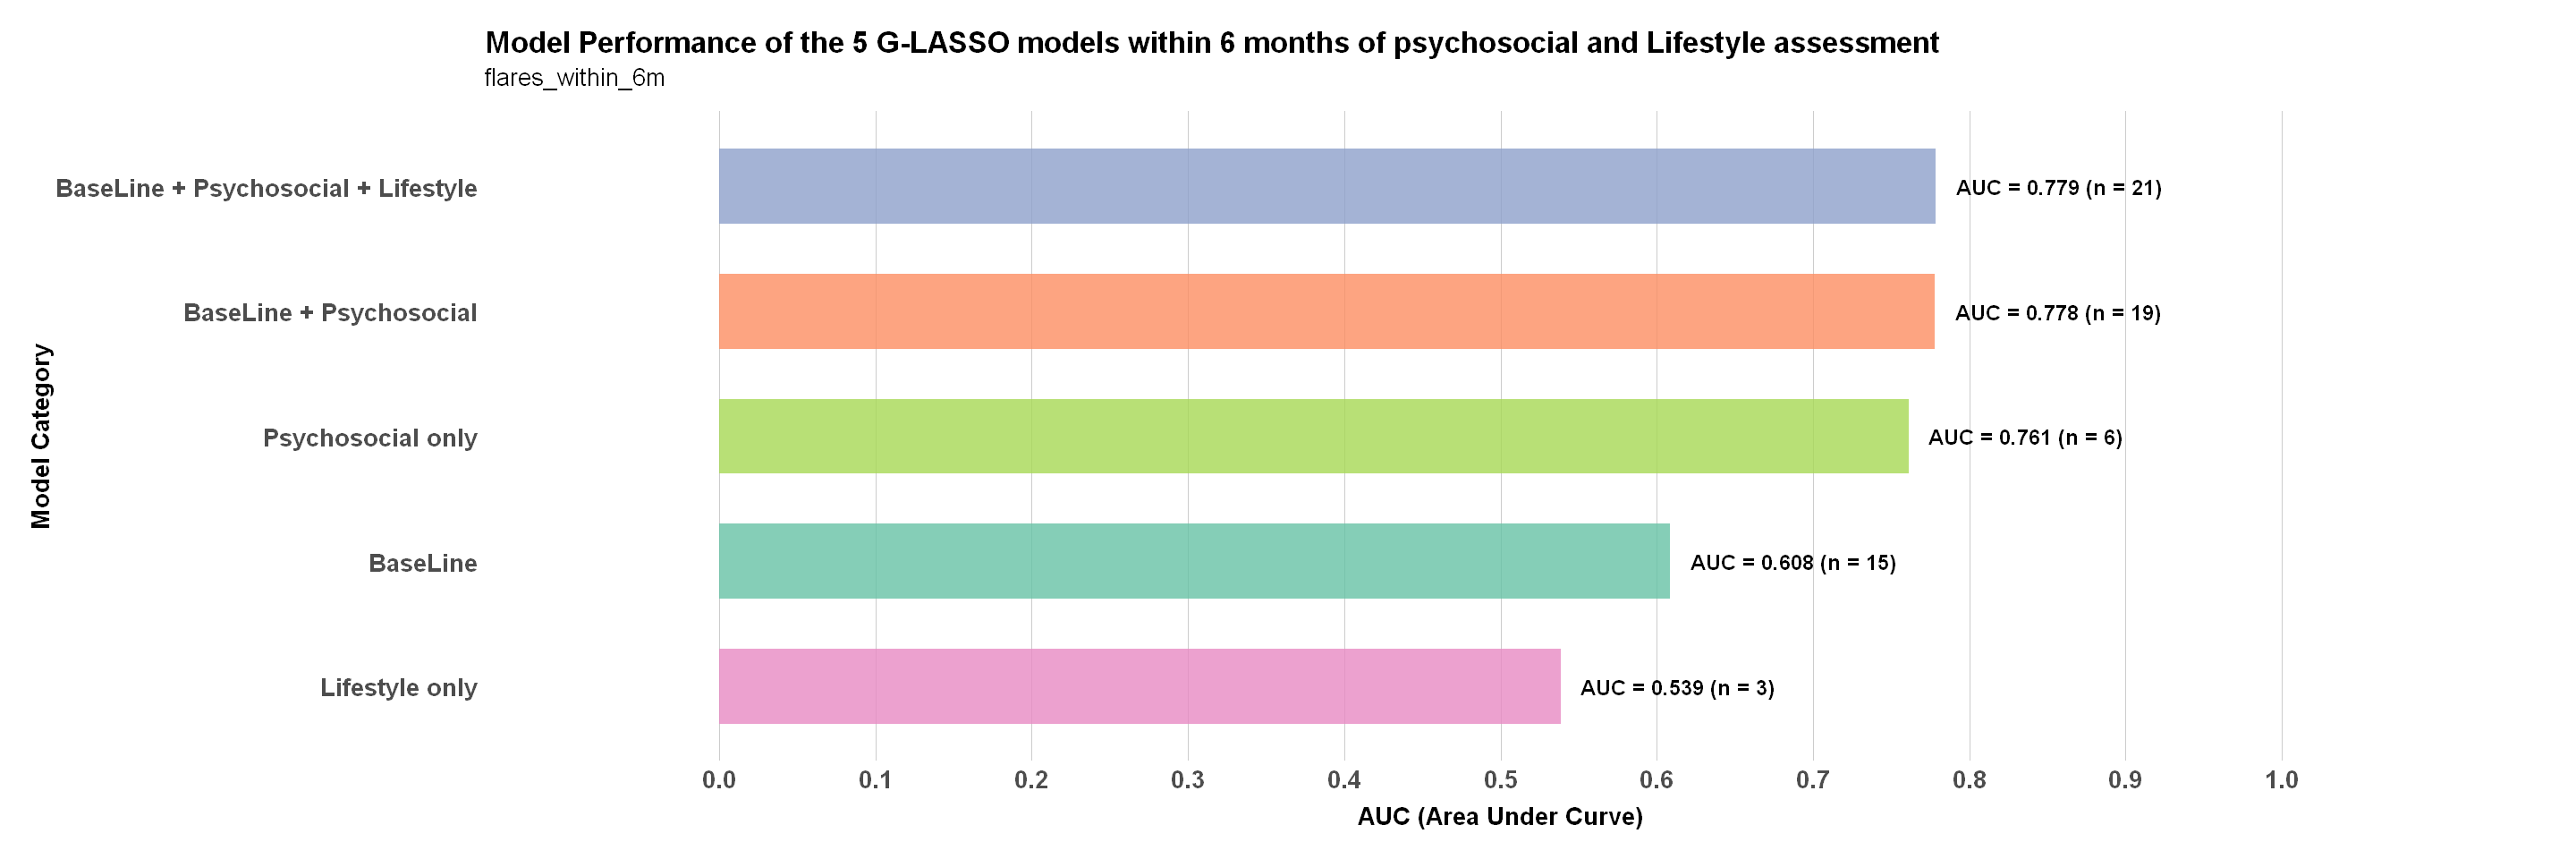

In [71]:
#Variable importance plot for Y1
variable_importance_y1 <- data.frame(
  Variable = c("BaseLine", 
               "BaseLine + Psychosocial", "BaseLine + Psychosocial + Lifestyle",
               "Psychosocial only",                "Lifestyle only"
               ),
  auc_values = c(metrics_model1_y1$auc,
                 metrics_model2_y1$auc, metrics_model3_y1$auc, metrics_model4_y1$auc
                 , metrics_model5_y1$auc
                 ),
  n_vars = c(len_model1_y1, 
             len_model2_y1, len_model3_y1, len_model4_y1, len_model5_y1
             )
)
options(repr.plot.width=24, repr.plot.height=8)
# Create Figure : Variable Importance Plot for Y1
ggplot(variable_importance_y1, aes(x = auc_values, y = reorder(Variable, auc_values))) +
  geom_col(aes(fill = Variable), width = 0.6, alpha = 0.8) +
  geom_text(aes(label = sprintf("AUC = %.3f (n = %d)", auc_values, n_vars)), 
            hjust = -0.1, size = 5, fontface = "bold") +
  scale_x_continuous(limits = c(0, 1), 
                     breaks = seq(0, 1, 0.1),
                     expand = c(0, 0.15)) +
  scale_fill_brewer(palette = "Set2") +
  labs(title = "Model Performance of the 5 G-LASSO models within 6 months of psychosocial and Lifestyle assessment",
       subtitle = "flares_within_6m",
       y = "Model Category",
       x = "AUC (Area Under Curve)") +
  theme_minimal() +
  theme(
    legend.position = "none",
    plot.title = element_text(size = 20, face = "bold", hjust = 0),
    plot.subtitle = element_text(size = 16, hjust = 0, margin = margin(b = 15)),
    axis.title.x = element_text(size = 16, face = "bold", margin = margin(t = 10)),
    axis.title.y = element_text(size = 16, face = "bold", margin = margin(r = 10)),
    axis.text.x = element_text(size = 16, face = "bold"),
    axis.text.y = element_text(size = 16, face = "bold"),
    panel.grid.major.y = element_blank(),
    panel.grid.minor.x = element_blank(),
    panel.grid.major.x = element_line(color = "gray80", linewidth = 0.5),
    plot.margin = margin(20, 40, 20, 20)
  )




**Key:**

- **MIAH thresholds**: CD = 4.1 (26.5% above), UC = 4.8 (35.9% above) — not 3.6
- **Flare counts**: CD: 686 flares / 2,029 assessments; UC: 829 flares / 1,887 assessments
- **Flare source breakdown**: included exact counts (CD: 557 MIAH-only, 97 calpro-only, 32 both; UC: 706, 93, 30)
- **Patient-level outcome**: 667 flares / 1,584 non-flares across 2,251 patients (29.6% flare rate)
- **Analytical sample**: 1,462 complete cases after na.omit (BMI 21.5% missing, smoker 30.2% missing)
- **Disease breakdown**: CD 826 patients (24.9% flare rate), UC 636 patients (33.6%)
- **CD flare rate lower than UC** — correctly explained by different MIAH thresholds
- **Stress variable**: correctly identified as the `control_myself` score from Health Monitor, categorized at levels 5–6
- **Fatigue**: multiplied by 2 in preprocessing (fatigue_3d × 2)



# 1. Overview

This report presents the development and evaluation of predictive models for flare occurrence within 6 months following a psychosocial assessment in patients with Inflammatory Bowel Disease (IBD). The primary objective was to identify clinical, psychosocial, and lifestyle factors associated with disease flares, and to evaluate the predictive performance of models incorporating different variable domains.

The outcome of interest — flare within 6 months — was defined using a combination of two validated clinical markers:

-   The Maastricht IBD Activity Index (MIAH): threshold > 4.1 for Crohn's Disease (CD) and > 4.8 for Ulcerative Colitis (UC), corresponding to the 75th percentile of study-period distributions

-   Fecal calprotectin: threshold > 250 µg/g

-   A flare was declared if EITHER marker exceeded its threshold within 6 months after the assessment date (OR logic)



# 2. Inclusion and Exclusion Criteria

## 2.1 Inclusion Criteria

-   Confirmed diagnosis of Crohn's Disease (CD) or Ulcerative Colitis (UC)

-   Enrolled in the study between November 1, 2023 and November 1, 2025

-   At least one psychosocial assessment recorded during the study period with both IBD Control questionnaire and Health Monitor data on the same date

-   Assessment date must be after November 1, 2023 and before May 2, 2025 (ensuring at least 6 months of follow-up before study end)

-   Available baseline clinical data at enrollment

-   At least one valid MIAH or calprotectin measurement within 6 months following the assessment date and within the study period

## 2.2 Exclusion Criteria

-   Patients with no valid MIAH or calprotectin measurement in the 6-month forward window (outcome = NA; 3 CD and 2 UC patients excluded)

-   MIAH measurements recorded outside the study period (November 2023 – November 2025) were excluded from the flare computation window

-   Calprotectin columns 10–14 excluded as they were identified as logical flags rather than quantitative measurements; only columns 1–9 used

-   MIAH columns 1–4 used only; column 5 excluded

-   Patients with missing values on BMI (21.5%) or smoking status (30.2%) were excluded via complete case analysis, reducing from 2,251 to 1,462 patients



# 3. Analytical Approach

## 3.1 Data Sources

The analysis integrates four datasets:

-   dataset_cd / dataset_uc: One row per patient with clinical baseline data, MIAH scores (miah_CD1–4 for CD; miah_cu1–4 for UC) with corresponding dates, and calprotectin values (calprotectine1–9) with dates

-   IBD_Control: Multiple rows per patient with psychosocial assessment dates and scores for pain (pain_3c), fatigue (fatigue_3d × 2), and anxiety/depression (anxious_or_depressed_3e)

-   Health_Monitor: Multiple rows per patient with stress scores (control_myself)

-   Advanced therapy use and Other medication: used for context

An inner join of IBD_Control and Health_Monitor on patientIdentifier and effectiveDate yielded 5,985 matched psychosocial assessments across 2,499 unique patients.

## 3.2 Assessment Timeline Construction

For each patient, all psychosocial assessment dates within the study window were extracted. An assessment date was included only if it fell after November 1, 2023 AND before May 2, 2025 (i.e., at least 183 days before study end, ensuring a complete 6-month follow-up window). This yielded:

-   UC: 1,887 assessments across 1,076 unique patients (487 with 1, 367 with 2, 222 with 3 assessments)

-   CD: 2,029 assessments across 1,179 unique patients (555 with 1, 398 with 2, 226 with 3 assessments)

## 3.3 Flare Definition and Computation

For each patient assessment date, all MIAH scores (columns 1–4) and fecal calprotectin values (columns 1–9) recorded within the 6-month forward window (days 0 to 183 after assessment) AND within the study period were collected. The maximum value of each marker within this window was taken. A flare was defined as:

-   Max MIAH in window > 4.1 (CD) or > 4.8 (UC), OR

-   Max calprotectin in window > 250 µg/g

Flare source diagnostics from the final run:

| **Source**                     | **CD Assessments** | **UC Assessments** |
|-------------------------------|--------------------|--------------------|
| Flare from MIAH only          | 557                | 706                |
| Flare from Calprotectin only  | 97                 | 93                 |
| Flare from BOTH               | 32                 | 30                 |
| No flare (had data)           | 1,340              | 1,056              |
| No data in window (NA)        | 3                  | 2                  |
| Total assessments             | 2,029              | 1,887              |
| Total flares detected         | 686 (33.8%)        | 829 (44.0%)        |

MIAH score distributions within the study period:

| **Statistic**           | **CD (threshold 4.1)** | **UC (threshold 4.8)** |
|------------------------|------------------------|------------------------|
| Minimum                | 1.695                  | 1.717                  |
| 1st Quartile           | 3.076                  | 3.232                  |
| Median                 | 3.601                  | 4.683                  |
| Mean                   | 3.566                  | 4.177                  |
| 3rd Quartile           | 4.129                  | 4.957                  |
| Maximum                | 5.235                  | 5.235                  |
| % above threshold      | 26.5%                  | 35.9%                  |



Calprotectin distributions within the study period:

| **Statistic**               | **CD**        | **UC**        |
|----------------------------|---------------|---------------|
| Median                     | 77 µg/g       | 69 µg/g       |
| Mean                       | 202.1 µg/g    | 271.4 µg/g    |
| Maximum                    | 6,531 µg/g    | 8,000 µg/g    |
| % above 250 µg/g threshold | 19.9%         | 22.6%         |

## 3.4 Patient-Level Outcome Aggregation

Patients could have 1 to 3 psychosocial assessments during the study period. The outcome `flare_majority_within_6m` was defined conservatively as:

-   1 (Flare): ALL valid assessments for the patient indicated a flare

-   0 (No flare): At least one assessment indicated no flare

-   NA: No valid outcome data available (excluded)

Patient-level outcome breakdown after aggregation:

| **Outcome**   | **N patients** | **Percentage** |
|---------------|----------------|----------------|
| No flare (0)  | 1,584          | 70.4%          |
| Flare (1)     | 667            | 29.6%          |
| Total         | 2,251          | 100%           |

Assessment count distribution among the 2,251 patients:

| **Assessments per patient** | **N patients** |
|-----------------------------|----------------|
| 1                           | 1,039          |
| 2                           | 764            |
| 3                           | 448            |

## 3.5 Patient-Level Weighting

To account for unequal numbers of assessments per patient and correct for repeated measures clustering, each patient was assigned an observation weight proportional to their number of valid assessments:

**patient_weight = n_assessments_valid / total_assessments**

This ensures patients with more assessments (higher data richness) contribute proportionally more to the model, while still allowing single-assessment patients to contribute. Weighted flare rate: 28.3%.

## 3.6 Missing Data

Complete case analysis (na.omit()) was applied. The two variables with substantial missingness were:

-   BMI: 21.5% missing

-   Smoking status: 30.2% missing

This reduced the analytical sample from 2,251 to 1,462 patients (35% reduction). The flare rate changed minimally from 29.6% to 28.7% (420 flares, 1,042 non-flares), suggesting the missing data mechanism is approximately random with respect to the outcome.

## 3.7 Feature Engineering

Two composite features were constructed:

**Disease Burden Score:** A composite index averaging the absolute z-standardized values of four components: UC Montreal severity (UC patients only, 0 for CD), CD ileocaecal resection status (CD patients only, 0 for UC), fatigue, and pain. This ensures equal contribution across heterogeneous disease-specific and universal measures.

**Disease-Stratified Interaction Terms:** Three factor interaction variables were created: DiseaseEntity × montreal_extent_uc (UC-only, CD=0), DiseaseEntity × montreal_severity_uc (UC-only, CD=0), and DiseaseEntity × surg_ileocaecal_resection (CD-only, UC=0), enabling models to capture disease-specific effects within a unified dataset structure.

# 4. Final Dataset

 | **Parameter**                      | **Value**                     |
|----------------------------------|-------------------------------|
| Total patients (analytical sample) | 1,462                         |
| Crohn's Disease                  | 826 (56.5%)                   |
| Ulcerative Colitis               | 636 (43.5%)                   |
| Overall flare rate               | 28.7% (420/1,462)             |
| CD flare rate                    | 24.9% (206/826)               |
| UC flare rate                    | 33.6% (214/636)               |
| Weighted flare rate              | 28.3%                         |
| Study period                     | November 2023 – November 2025 |
| Dataset dimensions               | 1,462 patients × 32 variables |

Predictor domains:

  | **Domain**            | **Key Variables**                                                                                                         | **Count** |
|----------------------|---------------------------------------------------------------------------------------------------------------------------|-----------|
| Baseline clinical    | Disease entity, gender, BMI, age, UC extent/severity interactions, surgical history (4 types + interaction), number of surgeries | 15        |
| Psychosocial         | Anxiety/depression, stress (2 levels), disease burden score (3 levels), fatigue, pain                                     | 8         |
| Lifestyle            | Smoking status (2 levels: ex-smoker, current smoker)                                                                      | 2         |
| Total predictors     |                                                                                                                           | 25        |

# 5. Statistical Method: Group Lasso (gglasso)

## 5.1 Rationale

Standard lasso penalizes each variable independently. However, many predictors in this study are conceptually and statistically related — for example, the three UC extent dummy variables together encode a single clinical concept (disease extent). Group lasso extends the lasso penalty to act on predefined groups of variables, enforcing that all variables within a group are either selected together or excluded together. This produces clinically interpretable results where entire clinical concepts are retained or dropped as a unit.

## 5.2 Model Fitting

-   Package: gglasso (R)

-   Loss function: logistic (loss = 'logit')

-   Intercept: included (intercept = TRUE)

-   Outcome coding: {-1, +1} for gglasso logistic loss compatibility

-   Design matrix: model.matrix(~ ., data) with standard reference-coded dummies (intercept included, one level dropped per factor as reference)

-   Patient weights: incorporated directly into the penalized likelihood

-   Performance: evaluated on held-out test set using AUC, sensitivity, specificity, PPV, and NPV

## 5.3 Variable Grouping

Variables are grouped so that clinically related dummies are penalized together:

| **Group** | **Variables**                                                                                           | **Clinical Rationale**                  | **N cols** |
|----------|----------------------------------------------------------------------------------------------------------|-----------------------------------------|-----------|
| 1 (Intercept) | (Intercept)                                                                                          | Baseline log-odds — not penalized       | 1         |
| 2 (Disease entity) | DiseaseEntityUC (CD = reference)                                                               | Disease type                            | 1         |
| 3 (Demographics) | genderFemale, bmi>24.86, age_at_inclusion>49.98                                               | Patient demographic profile             | 3         |
| 4 (UC disease profile) | DiseaseEntity_x_extent_uc1/2/3, DiseaseEntity_x_severity_uc1                            | UC extent and severity (CD=0)           | 4         |
| 5 (Disease–surgery interaction) | DiseaseEntity_x_surg_ileo1                                                      | Disease × ileocaecal resection (UC=0)   | 1         |
| 6 (Surgical history) | surg_ileo_anal_pouch1, surg_small_bowel_resection1, surg_small_bowel_stoma1, surg_stoma_reversal1 | Major surgical interventions            | 4         |
| 7 (Surgical burden) | number_of_surgeries>0                                                                     | Any prior surgery                       | 1         |
| 8 (Mental health) | anxious_or_depressed, stress5-6, stress6-7                                                 | Psychological symptom burden            | 3         |
| 9 (Physical burden) | disease_burden_score0.56-0.7, disease_burden_score0.7-0.8, disease_burden_score0.8-1.42, fatigue, pain | Physical symptom and disease load       | 5         |
| 10 (Lifestyle) | smoker2, smoker3                                                                           | Smoking status (non-smoker = reference) | 2         |

# 6. Model Descriptions

| **Model**                                   | **Predictor Sets**                      | **Clinical Purpose**                                   |
|--------------------------------------------|----------------------------------------|--------------------------------------------------------|
| Model 1: Baseline only                      | Groups 1–7 (15 clinical variables)     | Baseline prediction from enrollment data alone          |
| Model 2: Baseline + Psychosocial            | Groups 1–9 (23 variables)              | Incremental value of psychosocial screening             |
| Model 3: Baseline + Psychosocial + Lifestyle| Groups 1–10 (25 variables)             | Full available predictor set                            |
| Model 4: Psychosocial only                  | Groups 1, 8–9 (9 variables + intercept)| Psychosocial variables without clinical baseline        |
| Model 5: Lifestyle only                     | Groups 1, 10 (3 variables)             | Smoking status alone                                   |


# 7. Model Results

## 7.1 Performance Metrics

| **Model**                                   | **Accuracy** | **AUC** | **AUC 95% CI**   | **Sensitivity** | **Specificity** | **PPV** | **NPV** |
|--------------------------------------------|--------------|---------|------------------|------------------|------------------|---------|---------|
| Model 1: Baseline                          | 0.579        | 0.608   | [0.571 – 0.646]  | 0.583            | 0.578            | 0.358   | 0.775   |
| Model 2: Baseline + Psychosocial          | 0.739        | 0.778   | [0.737 – 0.818]  | 0.664            | 0.769            | 0.537   | 0.850   |
| Model 3: Baseline + Psychosocial + Lifestyle | 0.742     | 0.779   | [0.737 – 0.820]  | 0.657            | 0.776            | 0.542   | 0.849   |
| Model 4: Psychosocial only                | 0.699        | 0.761   | [0.704 – 0.819]  | 0.724            | 0.689            | 0.484   | 0.861   |
| Model 5: Lifestyle only                   | 0.527        | 0.539   | [0.495 – 0.582]  | 0.557            | 0.514            | 0.316   | 0.742   |

Key performance findings:

-   Model 1 (baseline only) achieves modest discrimination (AUC = 0.608), confirming that clinical enrollment data alone has limited short-term flare predictive ability.

-   Adding psychosocial variables (Model 2) produces the largest improvement: ΔAUC = +0.170, accuracy +16.0%, PPV rises to 0.537. This demonstrates that psychosocial screening adds substantial independent predictive value beyond clinical data alone.

-   Model 3 adds lifestyle variables and provides negligible further improvement over Model 2 (ΔAUC = +0.001), indicating smoking status does not contribute meaningfully when clinical and psychosocial data are present.

-   Model 4 (psychosocial only) achieves AUC = 0.761 — remarkably close to the full model (0.779), and the highest NPV (0.861), confirming psychosocial variables are the dominant predictors.

-   Model 5 (lifestyle only) performs near chance (AUC = 0.539), confirming smoking status alone has negligible predictive value.

-   Model 2 is the recommended clinical model: AUC = 0.778, NPV = 0.850 — meaning 85.0% of patients predicted not to flare will remain flare-free over the next 6 months.

## 7.2 Model Coefficients

| **Variable**                    | **Model 1** | **Model 2** | **Model 3** | **Model 4** | **Model 5** |
|---------------------------------|-------------|-------------|-------------|-------------|-------------|
| (Intercept)                    | -0.726      | -0.873      | -0.843      | -1.187      | -0.775      |
| DiseaseEntityUC               | 0.353       | —           | —           | —           | —           |
| genderFemale                  | -0.086      | 0.169       | 0.169       | —           | —           |
| bmi>24.86                     | -0.211      | -0.097      | -0.088      | —           | —           |
| age_at_inclusion>49.98        | -0.231      | -0.301      | -0.283      | —           | —           |
| DiseaseEntity_x_extent_uc1     | 0.133       | 0.128       | 0.123       | —           | —           |
| DiseaseEntity_x_extent_uc2     | -0.127      | -0.193      | -0.203      | —           | —           |
| DiseaseEntity_x_extent_uc3     | 0.118       | 0.035       | 0.028       | —           | —           |
| DiseaseEntity_x_severity_uc1   | -0.020      | -0.038      | -0.036      | —           | —           |
| DiseaseEntity_x_surg_ileo1     | -0.606      | -1.455      | -1.469      | —           | —           |
| surg_ileo_anal_pouch1          | -2.002      | -1.628      | -1.829      | —           | —           |
| surg_small_bowel_resection1    | -1.137      | -0.879      | -0.911      | —           | —           |
| surg_small_bowel_stoma1        | -1.367      | -0.813      | -0.816      | —           | —           |
| surg_stoma_reversal1           | 0.830       | 0.914       | 0.951       | —           | —           |
| number_of_surgeries>0          | 0.121       | -0.003      | -0.008      | —           | —           |
| anxious_or_depressed           | —           | -0.034      | -0.032      | -0.046      | —           |
| stress (level 5–6)             | —           | 0.499       | 0.503       | 0.507       | —           |
| disease_burden_score           | —           | 0.338       | 0.344       | -0.053      | —           |
| fatigue                        | —           | -0.499      | -0.496      | -0.509      | —           |
| pain                           | —           | -0.640      | -0.643      | -0.479      | —           |
| smoker2 (ex-smoker)            | —           | —           | -0.097      | —           | -0.241      |
| smoker3 (current smoker)       | —           | —           | -0.057      | —           | -0.341      |

Note: — indicates the variable was either not in the model or was shrunk to zero by the group lasso penalty. All models use CD as the reference disease entity; Male as reference gender; non-smoker (smoker category 1) as reference for smoking; and lower BMI / younger age as reference for dichotomized continuous variables.

# 8. Variable-by-Variable Interpretation

### Intercept

The intercept represents the baseline log-odds of flaring for a patient in the reference category (CD, male, BMI ≤ 24.86, age ≤ 49.98, no surgery, non-smoker, no elevated psychosocial scores). It is negative across all models, reflecting that the overall flare rate in the study population is below 50% (28.7%).

### Group 2: Disease Entity (Reference: CD)

| **Variable**        | **Model 1** | **Model 2**     | **Model 3**     |
|---------------------|-------------|------------------|------------------|
| DiseaseEntityUC     | 0.353       | — (dropped)      | — (dropped)      |

UC patients have higher flare risk than CD patients (coefficient +0.353) in Model 1. This effect is entirely eliminated by the group lasso in Models 2 and 3, indicating that once psychosocial and demographic variables are controlled for, disease entity alone no longer independently discriminates flare risk. The UC–CD difference in observed flare rates (33.6% vs 24.9%) is attributable to differences in psychosocial burden and other covariates, not to disease type per se.

### Group 3: Demographics (Reference: Male, BMI ≤ 24.86, Age ≤ 49.98)

| **Variable**              | **Model 1** | **Model 2** | **Model 3** |
|---------------------------|-------------|-------------|-------------|
| genderFemale              | -0.086      | +0.169      | +0.169      |
| bmi>24.86                 | -0.211      | -0.097      | -0.088      |
| age_at_inclusion>49.98    | -0.231      | -0.301      | -0.283      |

**Gender:** Female sex shows a small protective effect in Model 1 (−0.086) but switches to a modest risk factor in Models 2–3 (+0.169). This sign reversal (sign flip) is a hallmark of confounding by psychosocial burden: female patients carry higher psychosocial load (anxiety, fatigue) on average; once that is controlled for, the residual biological or behavioral effect of female sex slightly increases flare risk.

**BMI:** Higher BMI (above median ~24.86 kg/m²) is consistently protective across all models, likely reflecting better nutritional status and disease stability at baseline. Patients with IBD-associated malnutrition or cachexia tend to have more aggressive disease course.

**Age:** Older patients (above median ~50 years) consistently show lower flare risk. This is well-established in IBD: disease activity tends to decrease with age, inflammatory burden is lower in older patients, and disease behavior often becomes more stable over time.

### Group 4: UC Disease Extent and Severity (Reference: Extent E0, Severity S0)

| **Variable**                                   | **Model 1** | **Model 2** | **Model 3** |
|------------------------------------------------|-------------|-------------|-------------|
| DiseaseEntity_x_extent_uc1 (E1, proctitis)    | +0.133      | +0.128      | +0.123      |
| DiseaseEntity_x_extent_uc2 (E2, left-sided)   | -0.127      | -0.193      | -0.203      |
| DiseaseEntity_x_extent_uc3 (E3, pancolitis)   | +0.118      | +0.035      | +0.028      |
| DiseaseEntity_x_severity_uc1 (S1, mild)       | -0.020      | -0.038      | -0.036      |

For CD patients, all these interaction terms are set to 0 (reference). For UC patients, left-sided colitis (E2) is consistently associated with lower flare risk compared to E0 (no extent data/reference), while proctitis (E1) and pancolitis (E3) show slightly elevated risk. Mild severity (S1) is modestly protective. Coefficients are small, suggesting that within the UC subgroup, extent and severity at enrollment contribute only modestly to short-term flare prediction once disease entity and demographics are in the model.

### Group 5: Disease–Surgery Interaction (Reference: No ileocaecal resection)

| **Variable**                 | **Model 1** | **Model 2** | **Model 3** |
|------------------------------|-------------|-------------|-------------|
| DiseaseEntity_x_surg_ileo1   | -0.606      | -1.455      | -1.469      |

This interaction captures CD patients with prior ileocaecal resection (UC patients are coded 0). The strongly negative coefficient indicates markedly lower flare risk in this CD subgroup. The effect nearly triples when psychosocial variables are added (from −0.606 to −1.455), suggesting that psychosocial adjustment unmasks a stronger biological protective effect: post-ileocaecal resection CD patients who also have low psychosocial burden are at very low short-term flare risk.

### Group 6: Surgical History (Reference: No surgery of each type)

| **Variable**                    | **Model 1** | **Model 2** | **Model 3** |
|---------------------------------|-------------|-------------|-------------|
| surg_ileo_anal_pouch1           | -2.002      | -1.628      | -1.829      |
| surg_small_bowel_resection1     | -1.137      | -0.879      | -0.911      |
| surg_small_bowel_stoma1         | -1.367      | -0.813      | -0.816      |
| surg_stoma_reversal1            | +0.830      | +0.914      | +0.951      |

Prior major surgeries are the strongest protective factors in the entire model. Ileoanal pouch construction carries the largest protective coefficient (−2.002 to −1.829), followed by small bowel stoma (−1.367) and small bowel resection (−1.137). These findings are clinically coherent: patients who have undergone disease-modifying surgical interventions have typically had their most problematic disease segment removed or diverted, resulting in substantially reduced inflammatory burden in the subsequent 6 months.

Stoma reversal is the sole surgical variable consistently associated with increased flare risk (+0.830 to +0.951). This is clinically plausible: restoration of bowel continuity after stoma formation reactivates mucosal exposure to luminal contents and may trigger inflammatory relapse, particularly in the early post-reversal period.

### Group 7: Number of Surgeries (Reference: 0 surgeries)

| **Variable**              | **Model 1** | **Model 2** | **Model 3** |
|---------------------------|-------------|-------------|-------------|
| number_of_surgeries>0     | +0.121      | −0.003      | −0.008      |

Having any prior surgery shows a small positive association with flare risk in Model 1 (+0.121) but is essentially eliminated by the group lasso in Models 2 and 3 (near zero). This indicates that the aggregate surgical burden adds no independent predictive value once the specific surgery types are modeled individually and psychosocial covariates are included.

### Group 8: Mental Health (Reference: No anxiety/depression; stress level 1–4)

| **Variable**            | **Model 2** | **Model 3** | **Model 4** |
|-------------------------|-------------|-------------|-------------|
| anxious_or_depressed    | -0.034      | -0.032      | -0.046      |
| stress (level 5–6)      | +0.499      | +0.503      | +0.507      |

**Stress:** Stress is the single most important modifiable psychosocial predictor of flares. Patients reporting stress scores of 5–6 (on the Health Monitor control_myself scale) have consistently higher flare risk (+0.499 to +0.507) across all models. This finding is highly consistent and clinically significant, providing direct support for stress management interventions as a flare prevention strategy. The brain-gut axis in IBD is well-established: psychological stress activates hypothalamic-pituitary-adrenal and sympatho-adrenal pathways that modulate intestinal permeability, mucosal immunity, and the gut microbiome.

**Anxiety and depression:** Shows a near-zero or slightly negative coefficient (−0.034 to −0.046), indicating that once stress is in the model, anxiety and depression add minimal independent predictive information. This likely reflects high collinearity between stress and anxiety/depression measures — patients with high stress tend to also report more anxiety and depression.

### Group 9: Physical Symptom Burden (Reference: Low disease burden; no elevated fatigue/pain)

| **Variable**                              | **Model 2** | **Model 3** | **Model 4** |
|-------------------------------------------|-------------|-------------|-------------|
| disease_burden_score (moderate–high)      | +0.338      | +0.344      | -0.053      |
| fatigue                                   | -0.499      | -0.496      | -0.509      |
| pain                                      | -0.640      | -0.643      | -0.479      |

**Disease burden score:** Higher composite disease burden is positively associated with flares in Models 2–3 (+0.338 to +0.344), reflecting that patients with higher overall symptom and disease activity load at assessment are more likely to flare. However, this effect disappears in Model 4 (psychosocial only, −0.053), suggesting the disease burden score's predictive contribution depends on the clinical baseline context.

**Fatigue and pain:** Both show consistently negative coefficients (fatigue: −0.496 to −0.509; pain: −0.479 to −0.643) — patients reporting higher fatigue and pain at assessment have lower predicted flare risk by the biomarker-based outcome. This counterintuitive finding warrants careful clinical interpretation.

The most clinically plausible explanation is functional versus inflammatory symptom dissociation in IBD: a substantial subset of IBD patients experience chronic fatigue and pain driven by functional mechanisms (IBS-like symptoms, central sensitization, fibromyalgia-like states) rather than active mucosal inflammation. These patients report high symptom burden at assessment, but their subsequent MIAH scores and calprotectin values remain below the flare thresholds, as the underlying pathophysiology is not inflammatory. This finding underscores the importance of distinguishing functional from inflammatory symptoms in IBD management — high fatigue and pain do not necessarily indicate an impending inflammatory flare, and aggressive escalation of anti-inflammatory therapy based on these symptoms alone may be inappropriate.

### Group 10: Lifestyle / Smoking (Reference: Non-smoker, category 1)

| **Variable**                 | **Model 3** | **Model 5** |
|------------------------------|-------------|-------------|
| smoker2 (ex-smoker)          | -0.097      | -0.241      |
| smoker3 (current smoker)     | -0.057      | -0.341      |

Both ex-smokers and current smokers show lower flare risk compared to non-smokers. The protective effect is more apparent in Model 5 (lifestyle only: −0.241 and −0.341) but is nearly eliminated by the group lasso in Model 3 (−0.097 and −0.057). The protective effect of smoking — particularly in UC — is one of the most consistent observations in IBD epidemiology, attributed to the anti-inflammatory effects of nicotine on colonic mucosa via modulation of mucosal immune responses and increased mucus production.

However, the near-zero coefficients in Model 3 confirm that smoking status does not add independent predictive value once clinical and psychosocial variables are accounted for, consistent with its role as a partial proxy for other clinical characteristics already captured in the model.



# 9. Conclusions and Clinical Recommendations

The results demonstrate that psychosocial variables — particularly stress — are the strongest independent predictors of IBD flares within 6 months, contributing substantially more than clinical baseline data alone. The following conclusions and recommendations emerge for clinical practice:

| **Finding** | **Clinical Implication** |
|-------------|--------------------------|
| Stress is the dominant modifiable risk factor (coeff +0.50) | Patients with stress scores ≥ 5 should be prioritized for psychological support, stress management programs, and closer follow-up. Routine stress screening at psychosocial assessments is strongly supported. |
| Psychosocial variables add ΔAUC = +0.17 over clinical baseline | Psychosocial screening is clinically valuable and should be integrated into standard IBD monitoring. Model 2 is recommended for clinical deployment. |
| Major surgical history is strongly protective (coeff −1.4 to −2.0) | Post-surgical patients (especially post-pouch and post-resection) may safely have monitoring intensity reduced, absent other risk factors. |
| Stoma reversal increases flare risk (coeff +0.83 to +0.95) | Patients undergoing stoma reversal should be monitored more closely in the 6 months post-procedure. |
| Fatigue and pain predict lower biomarker-defined flare risk | High fatigue and pain at assessment likely reflect functional rather than inflammatory disease in many patients. Functional symptom management (not intensified anti-inflammatory therapy) may be more appropriate for these patients. |
| NPV of Model 2 = 0.850 | 85.0% of patients predicted not to flare will remain flare-free — a clinically useful threshold for safely deferring intensive follow-up in low-risk patients. |
| UC has higher flare rate (33.6%) vs CD (24.9%) | UC patients warrant more proactive monitoring even when controlling for other factors. Disease-entity-specific thresholds were justified and important (MIAH 4.1 vs 4.8). |

## Recommended Model for Clinical Use

Model 2 (Baseline + Psychosocial) is the recommended model, balancing predictive performance with clinical interpretability:

-   AUC = 0.778 (95% CI: 0.737–0.818)

-   Sensitivity = 66.4% — detects approximately 2 in 3 patients who will flare

-   Specificity = 76.9% — correctly rules out flare in approximately 3 in 4 non-flaring patients

-   NPV = 85.0% — the most clinically valuable metric for safely reducing monitoring intensity

-   PPV = 53.7% — among patients flagged as high-risk, more than 1 in 2 will actually flare within 6 months


